In [1]:
# Install dependencies
%pip install -q -U ultralytics roboflow

# Basic utilities
import os
import glob

# Image display inside Colab
from IPython.display import Image, display

# YOLO
from ultralytics import YOLO

# Roboflow
from roboflow import Roboflow

# Set Colab working directory
HOME = os.getcwd()

print("HOME:", HOME)
print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
HOME: /content
Setup complete.


In [8]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="never gonna give you up")
project = rf.workspace("xiuqizhang2008-gmail-com").project("software-hw-2-ml-training")
version = project.version(2)
dataset = version.download("yolov8")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Software-HW-2,-ML-training-2 in yolov8:: 100%|██████████| 72/72 [00:00<00:00, 5687.19it/s]


In [9]:
print("HOME:", HOME)
print("Dataset:", dataset.location)
print("YAML:", f"{dataset.location}/data.yaml")

!nvidia-smi

HOME: /content
Dataset: /content/Software-HW-2,-ML-training-2
YAML: /content/Software-HW-2,-ML-training-2/data.yaml
Fri Sep 25 21:19:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                       

In [10]:
print("dataset.location =", dataset.location)

print("\n--- data.yaml ---")
with open(f"{dataset.location}/data.yaml", "r") as f:
    print(f.read())

print("\n--- folders ---")
!find "{dataset.location}" -maxdepth 2 -type d

dataset.location = /content/Software-HW-2,-ML-training-2

--- data.yaml ---
names:
- creeper
nc: 1
roboflow:
  license: Private
  project: software-hw-2-ml-training
  url: https://app.roboflow.com/xiuqizhang2008-gmail-com/software-hw-2-ml-training/2
  version: 2
  workspace: xiuqizhang2008-gmail-com
test: ../test/images
train: ../train/images
val: ../valid/images


--- folders ---
/content/Software-HW-2,-ML-training-2
/content/Software-HW-2,-ML-training-2/test
/content/Software-HW-2,-ML-training-2/test/labels
/content/Software-HW-2,-ML-training-2/test/images
/content/Software-HW-2,-ML-training-2/valid
/content/Software-HW-2,-ML-training-2/valid/labels
/content/Software-HW-2,-ML-training-2/valid/images
/content/Software-HW-2,-ML-training-2/train
/content/Software-HW-2,-ML-training-2/train/labels
/content/Software-HW-2,-ML-training-2/train/images


In [11]:
%cd {HOME}

!yolo task=detect mode=train \
    model=yolov8s.pt \
    data={dataset.location}/data.yaml \
    epochs=25 \
    imgsz=800 \
    plots=True

/content
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Software-HW-2,-ML-training-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms

In [13]:
from pathlib import Path

detect_dir = Path(HOME) / "runs" / "detect"

train_dir = max(
    detect_dir.glob("train*"),
    key=lambda p: p.stat().st_mtime
)

best_model = train_dir / "weights" / "best.pt"

print("Training folder:", train_dir)
print("Best model:", best_model)

Training folder: /content/runs/detect/train-4
Best model: /content/runs/detect/train-4/weights/best.pt


results.png


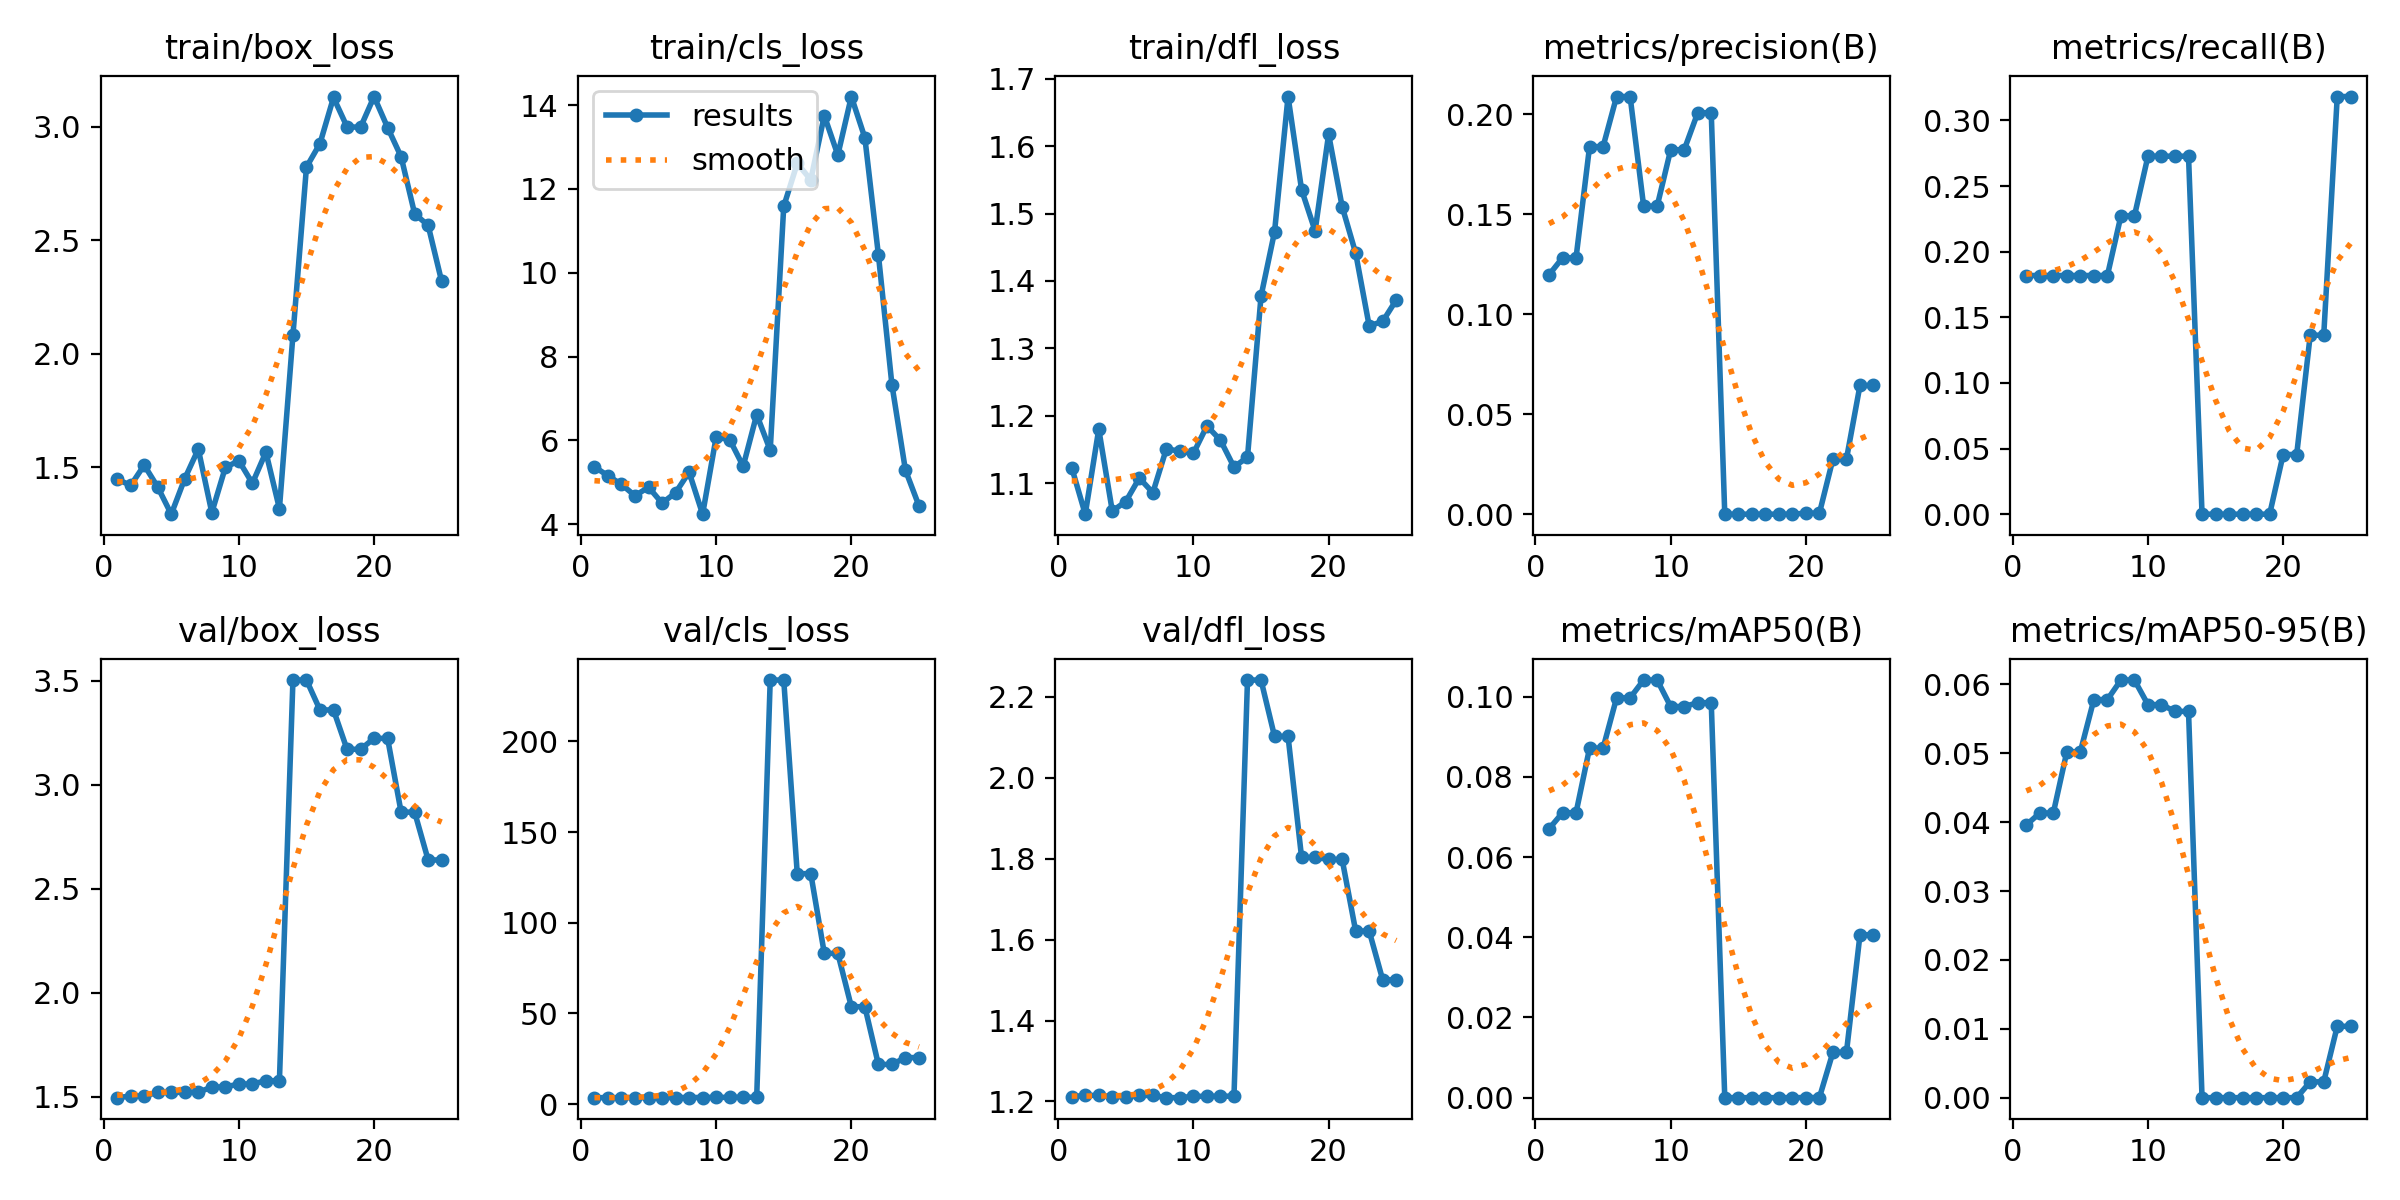

confusion_matrix.png


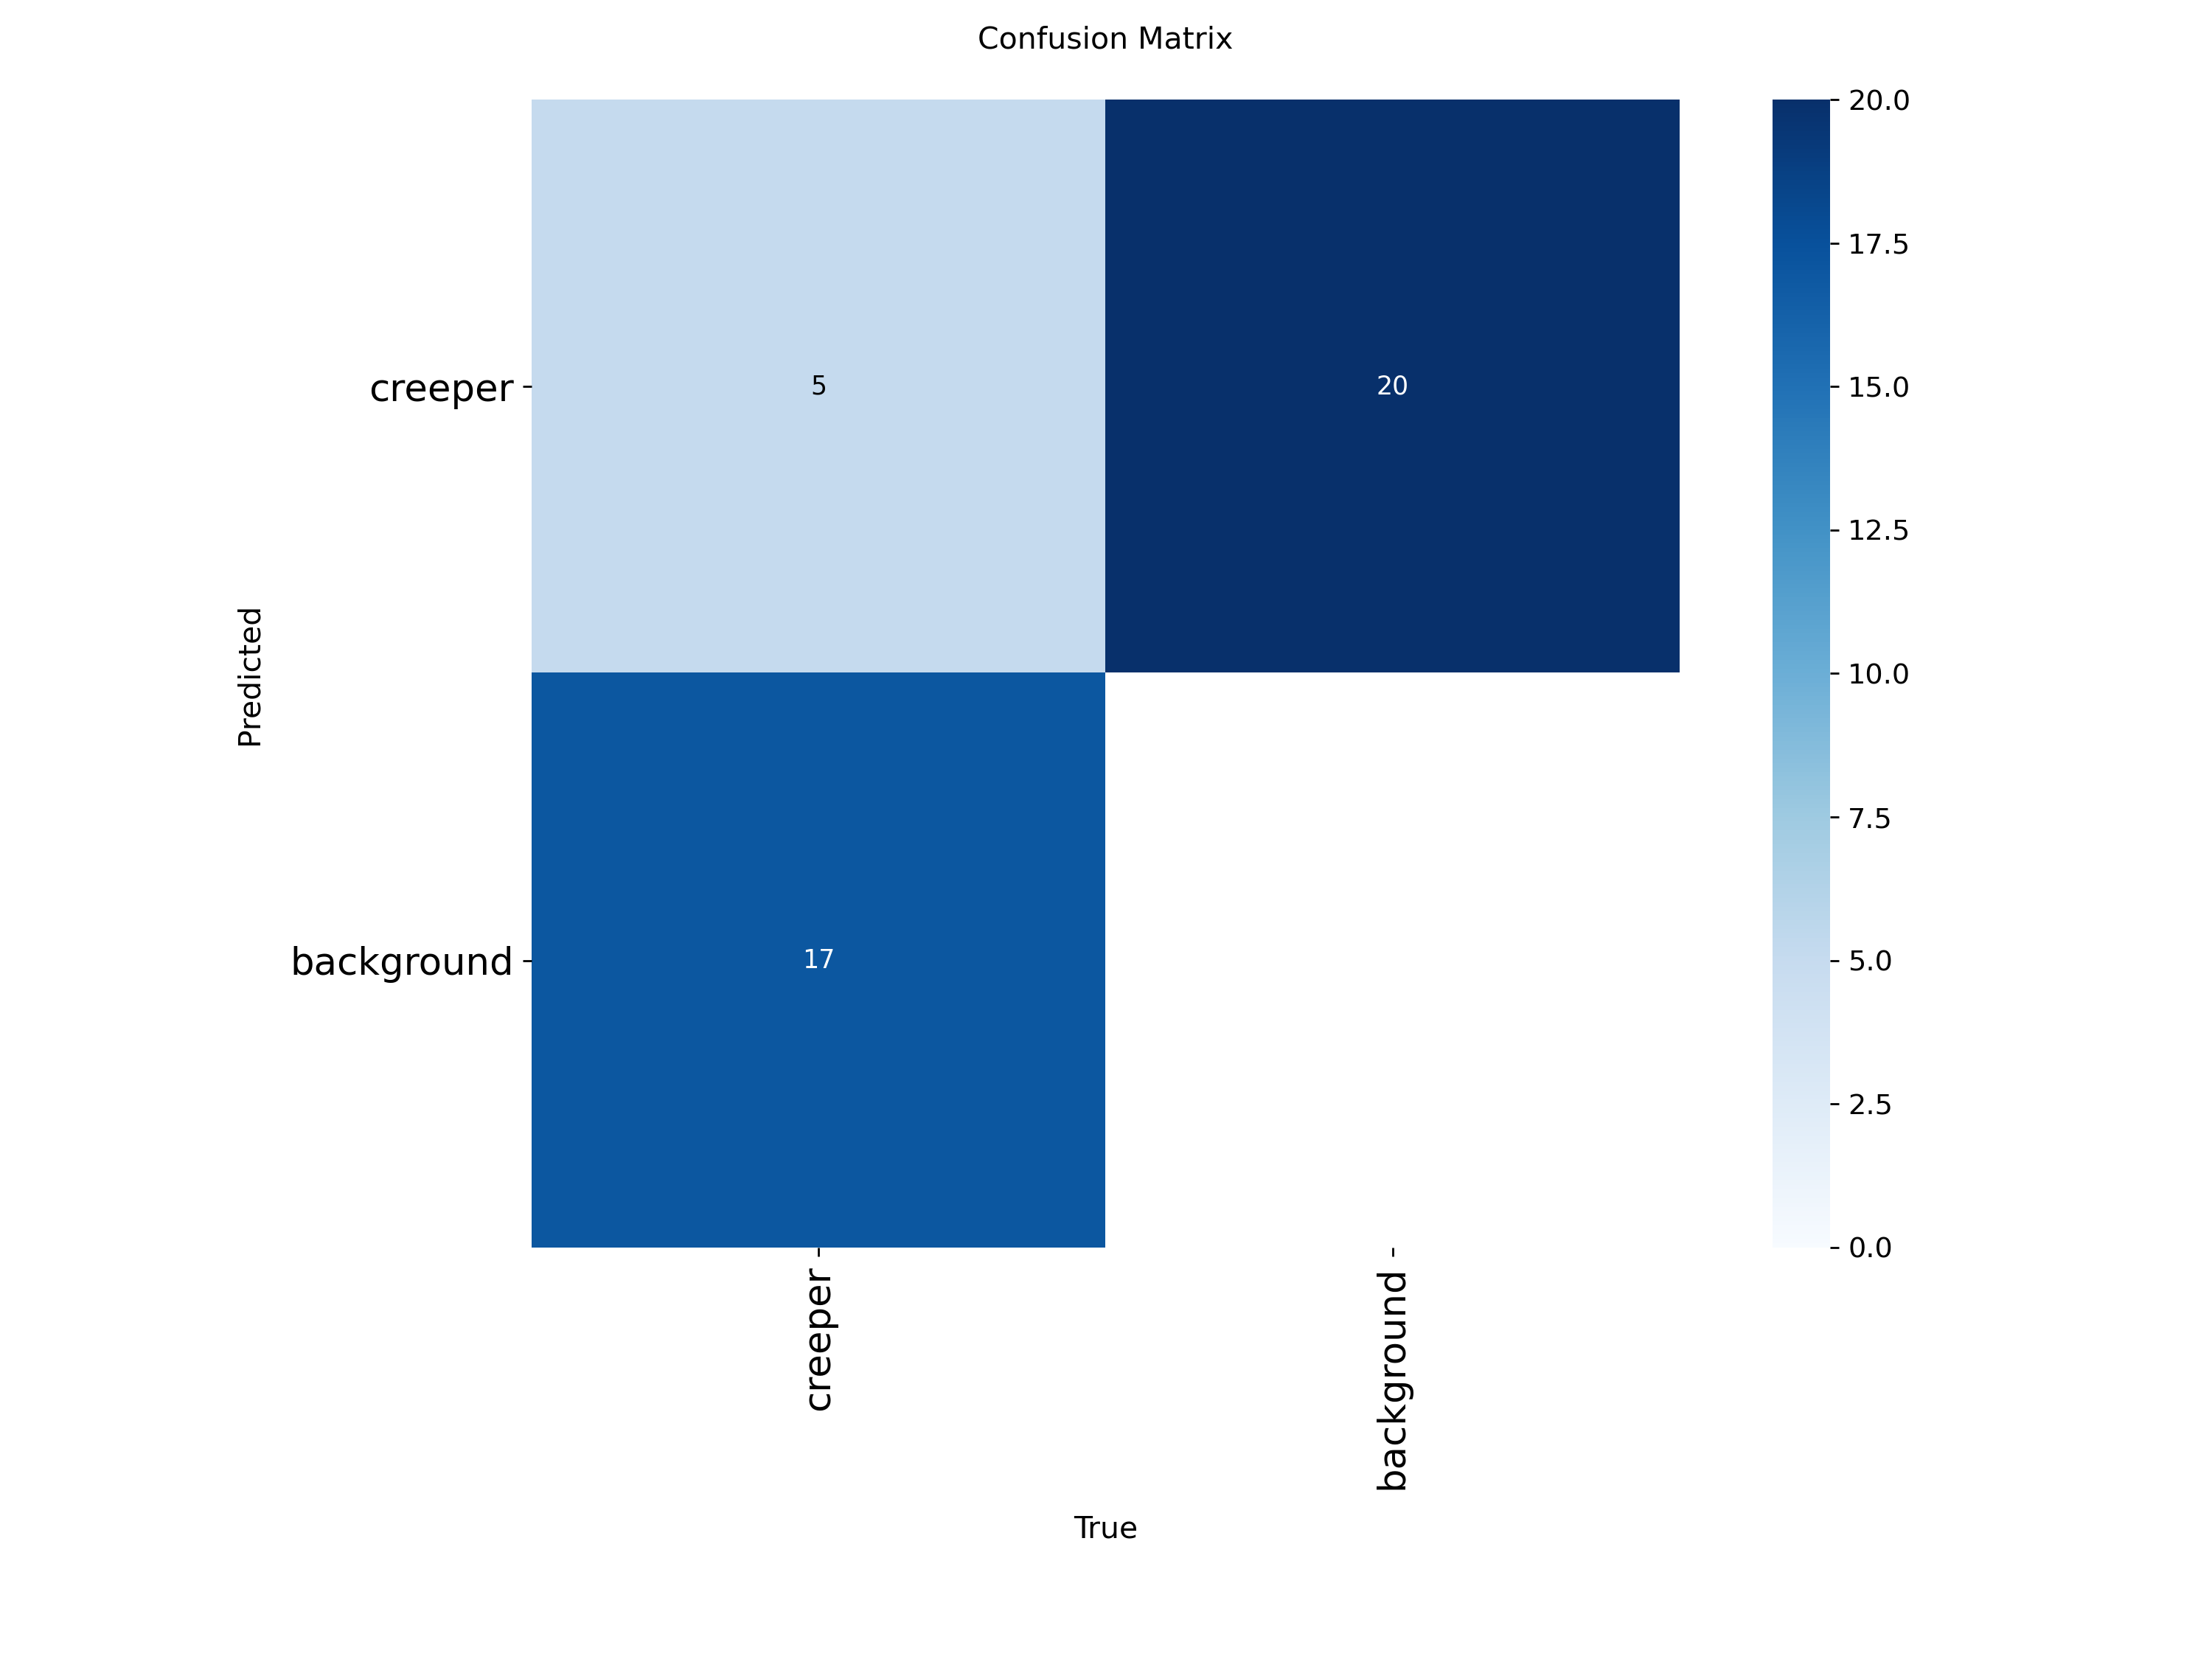

val_batch0_labels.jpg


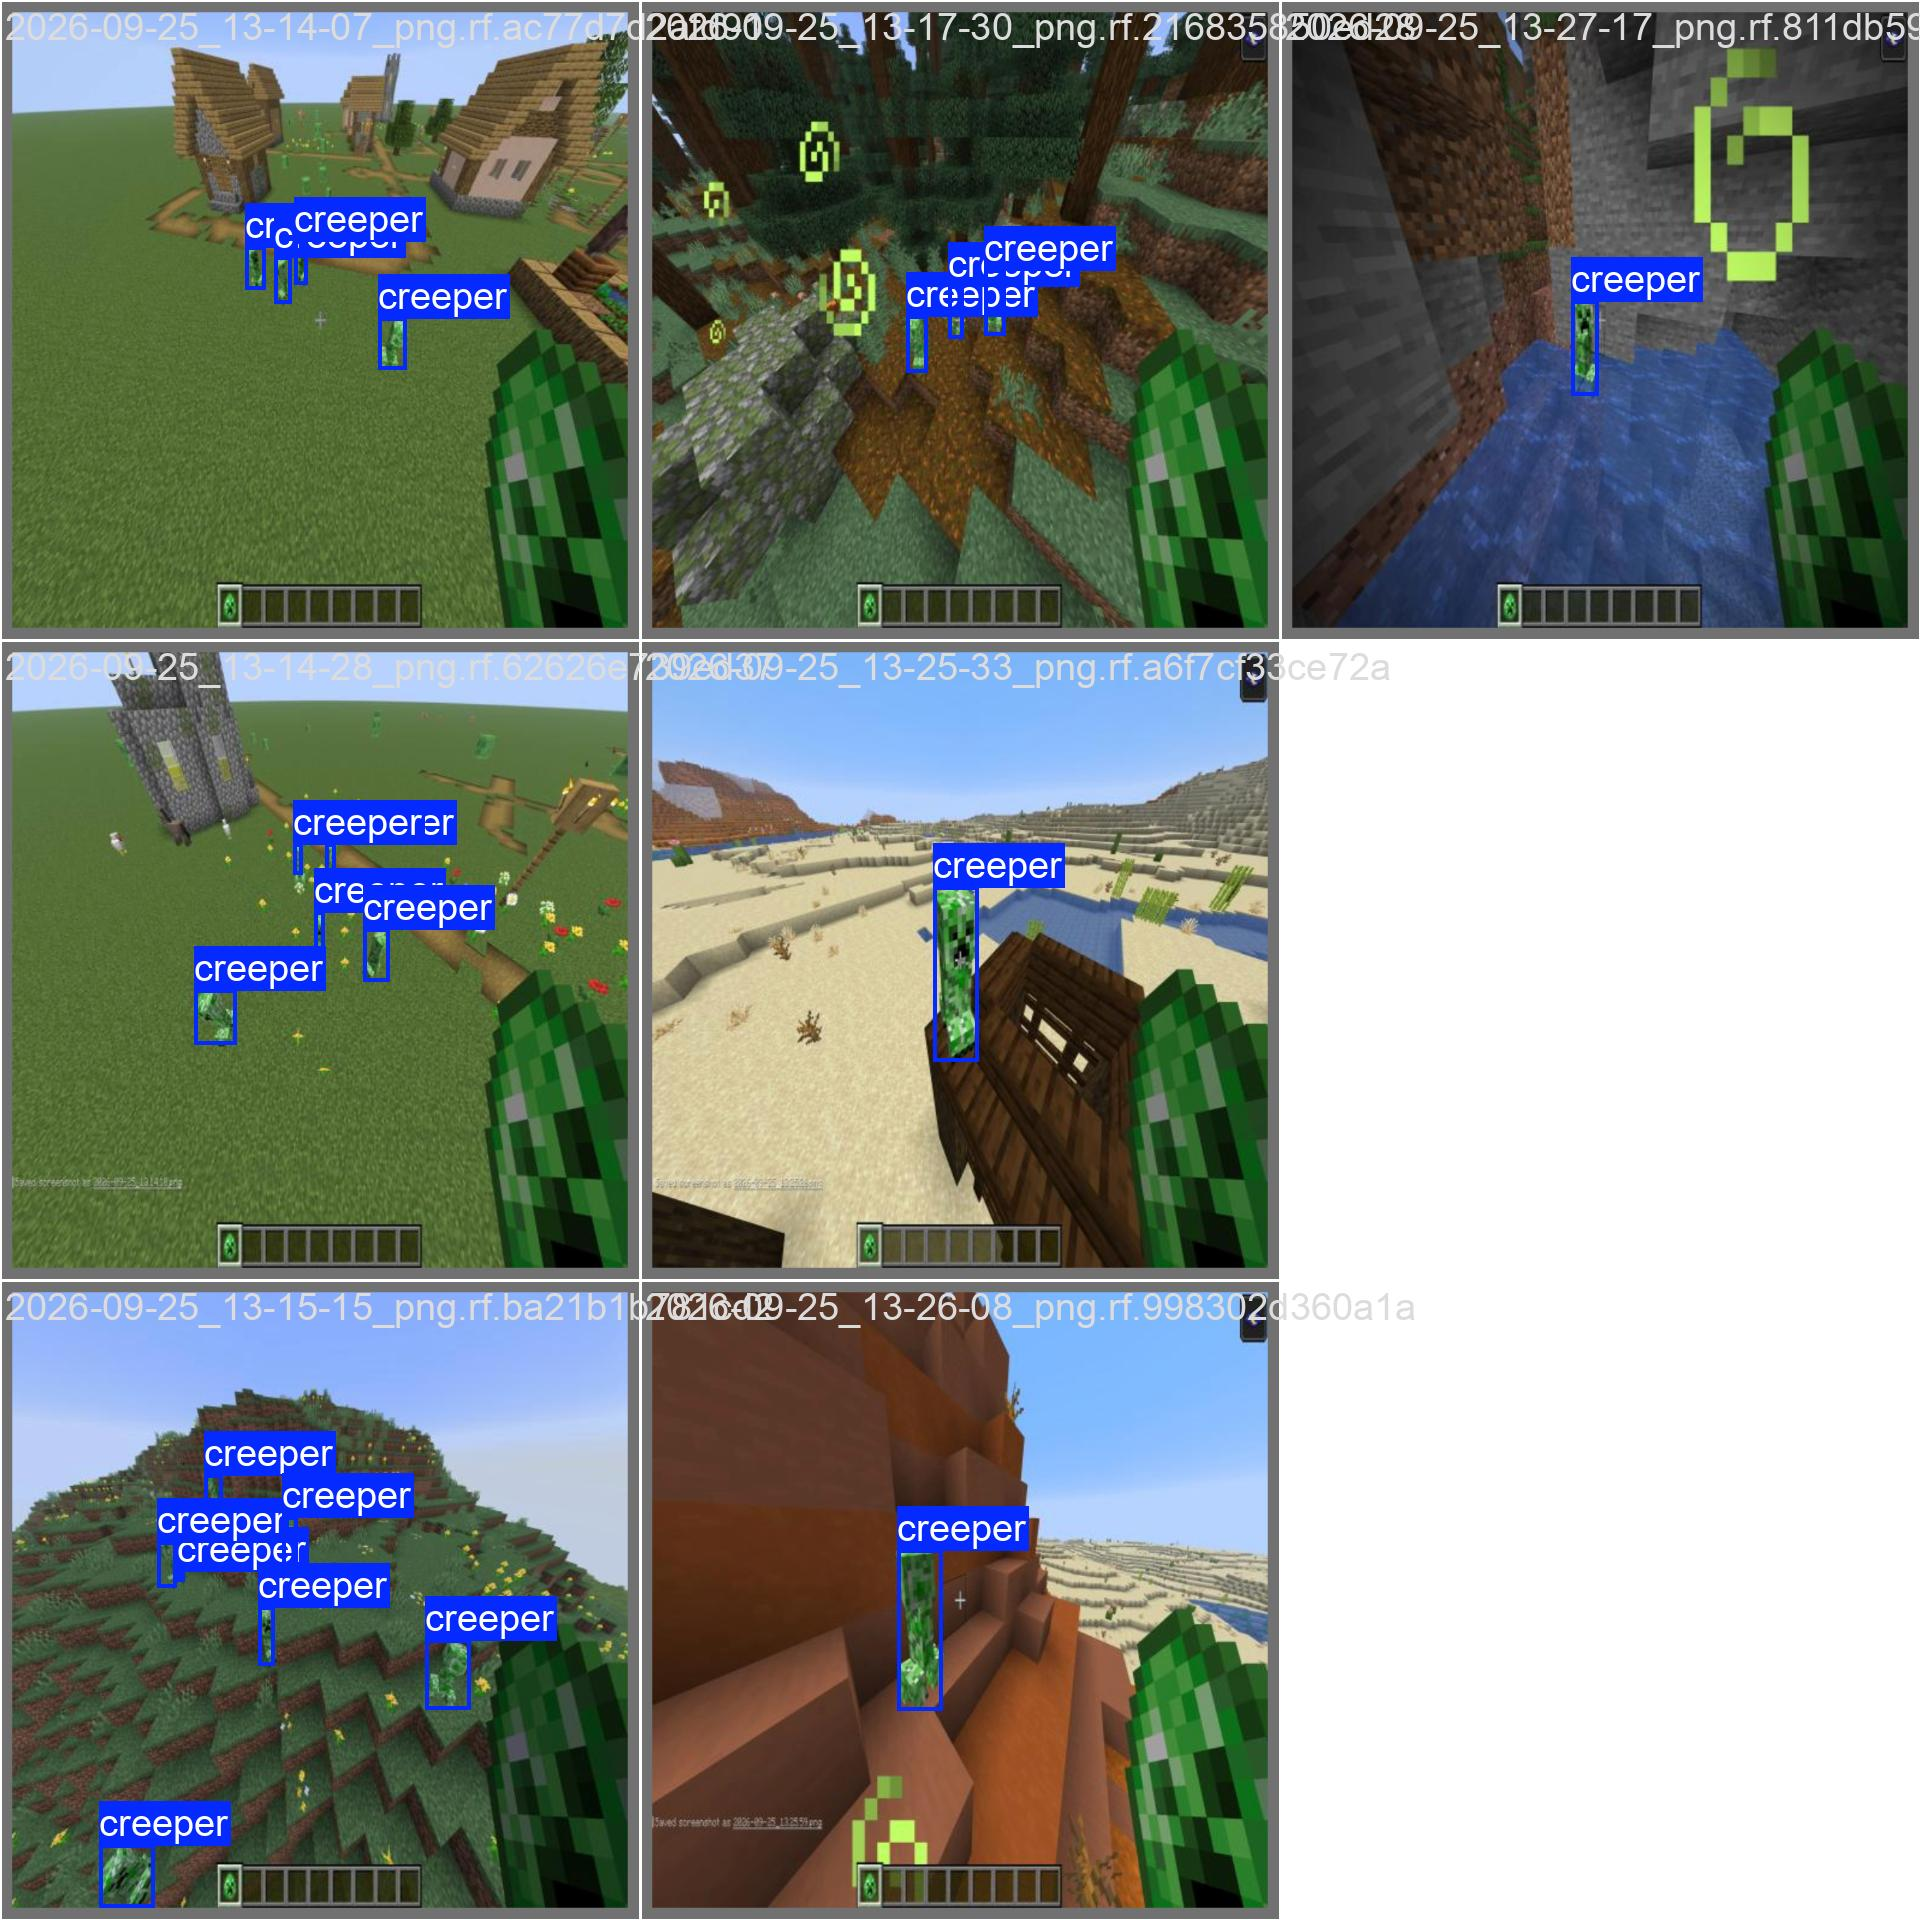

val_batch0_pred.jpg


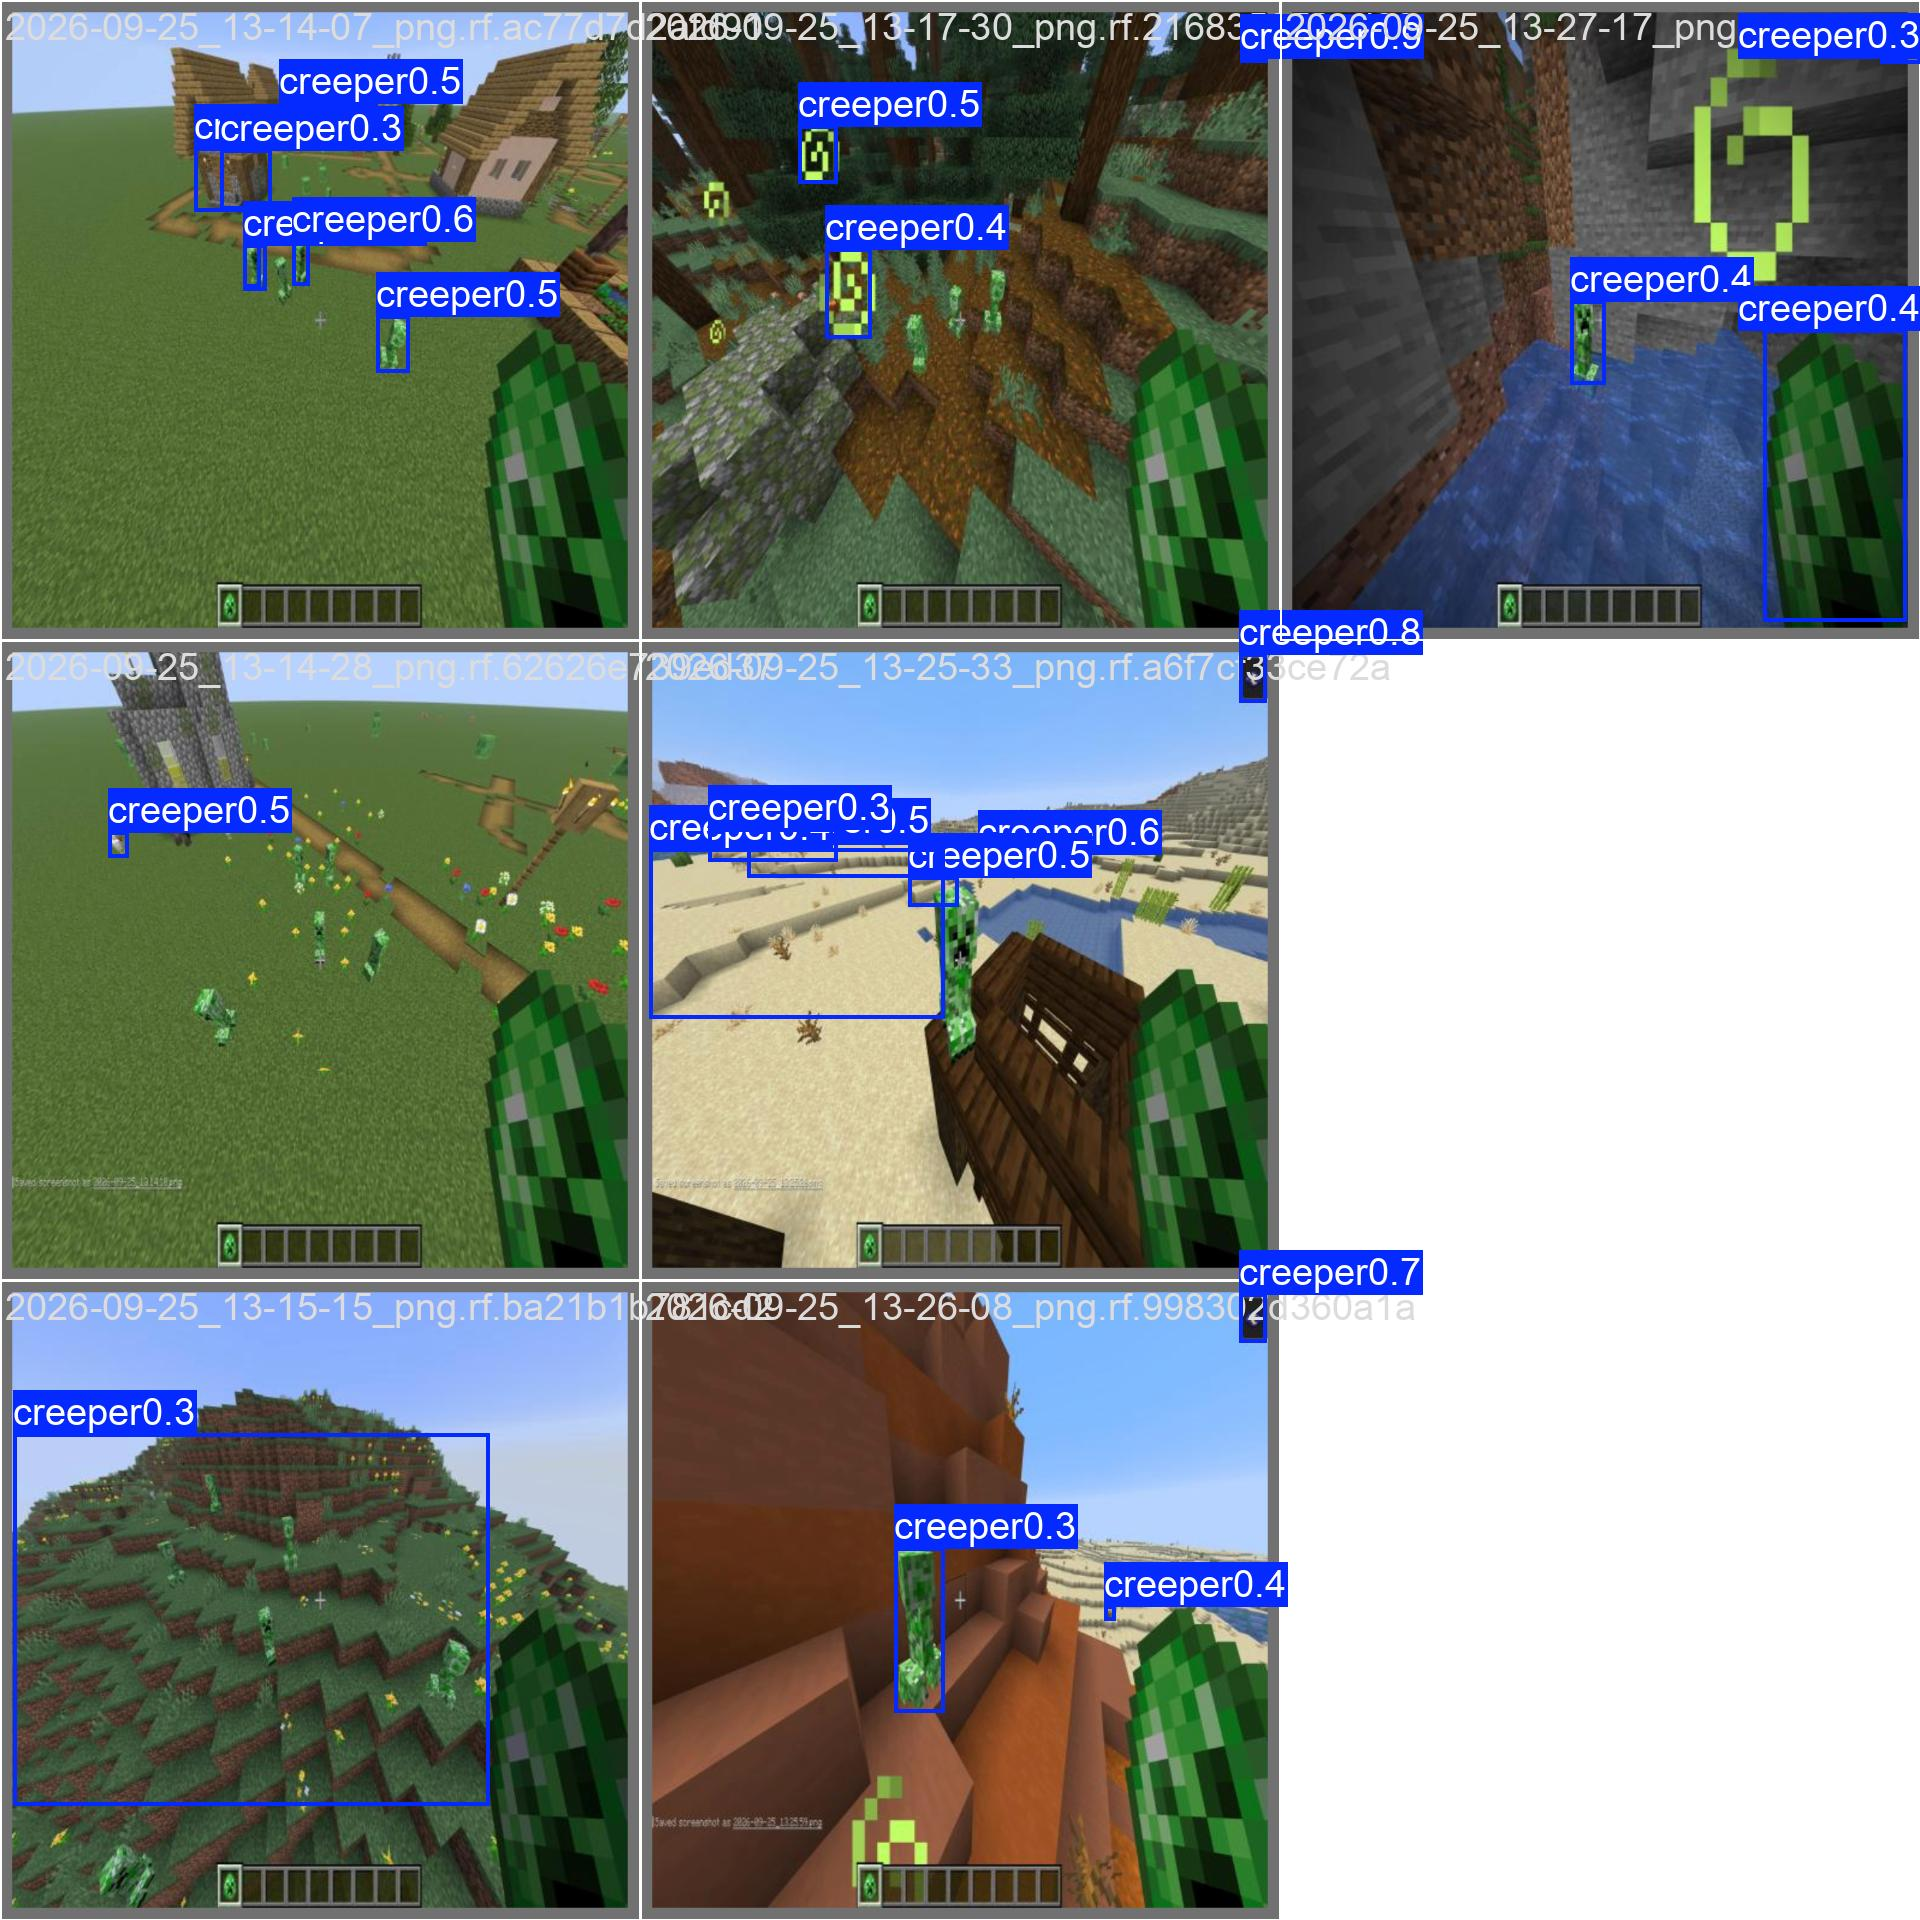

In [14]:
for filename in [
    "results.png",
    "confusion_matrix.png",
    "val_batch0_labels.jpg",
    "val_batch0_pred.jpg"
]:
    path = train_dir / filename

    if path.exists():
        print(filename)
        display(Image(filename=str(path), width=900))

In [15]:
!yolo detect predict \
    model="{best_model}" \
    source="{dataset.location}/test/images" \
    conf=0.25 \
    save=True \
    project="{HOME}/runs/detect" \
    name="creeper_test_baseline" \
    exist_ok=True

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/3 /content/Software-HW-2,-ML-training-2/test/images/2026-09-25_13-14-18_png.rf.a10c939b5cd731c8fc3f10d53ea26802.jpg: 800x800 13 creepers, 22.2ms
image 2/3 /content/Software-HW-2,-ML-training-2/test/images/2026-09-25_13-15-45_png.rf.79abb50387a422be18c9c79ae8b7ee39.jpg: 800x800 3 creepers, 22.2ms
image 3/3 /content/Software-HW-2,-ML-training-2/test/images/2026-09-25_13-16-23_png.rf.a0c5c4642eca1e90f1914a3d1f9be228.jpg: 800x800 3 creepers, 22.1ms
Speed: 14.3ms preprocess, 22.2ms inference, 7.1ms postprocess per image at shape (1, 3, 800, 800)
Results saved to /content/runs/detect/creeper_test_baseline
💡 Learn more at https://docs.ultralytics.com/modes/predict


2026-09-25_13-16-23_png.rf.a0c5c4642eca1e90f1914a3d1f9be228.jpg


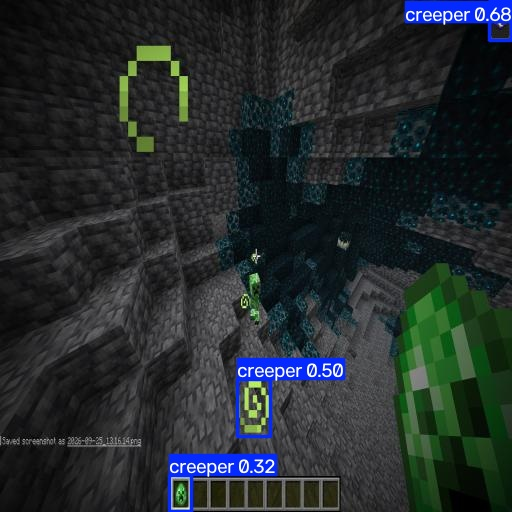

2026-09-25_13-15-45_png.rf.79abb50387a422be18c9c79ae8b7ee39.jpg


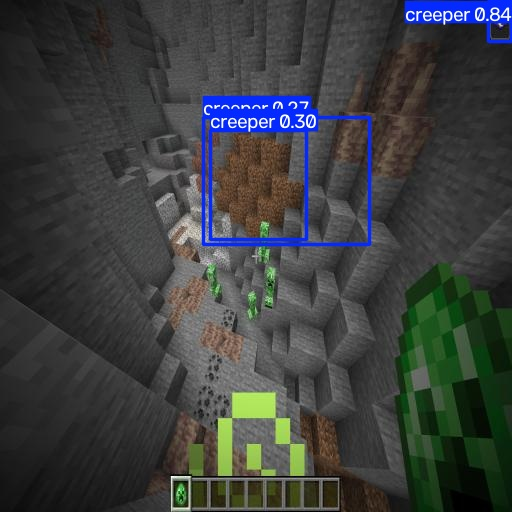

2026-09-25_13-14-18_png.rf.a10c939b5cd731c8fc3f10d53ea26802.jpg


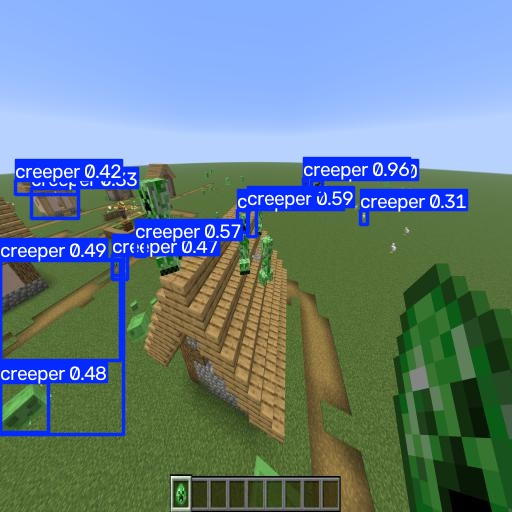

In [16]:
test_pred_dir = Path(HOME) / "runs" / "detect" / "creeper_test_baseline"

prediction_images = list(test_pred_dir.glob("*.jpg")) + list(test_pred_dir.glob("*.png"))

for img_path in prediction_images:
    print(img_path.name)
    display(Image(filename=str(img_path), width=800))

In [17]:
#Yo my first model is absolutely ASS
#after epoch 10 the model just freakin collapsed
# mosaic behavior closed at 10, what if I just dont close it?
%cd {HOME}

!yolo task=detect mode=train \
    model=yolov8s.pt \
    data={dataset.location}/data.yaml \
    epochs=25 \
    imgsz=800 \
    plots=True \
    close_mosaic=0 \
    name=creeper_no_mosaic_close

/content
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Software-HW-2,-ML-training-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=creeper_no_mosaic_clo

results.png


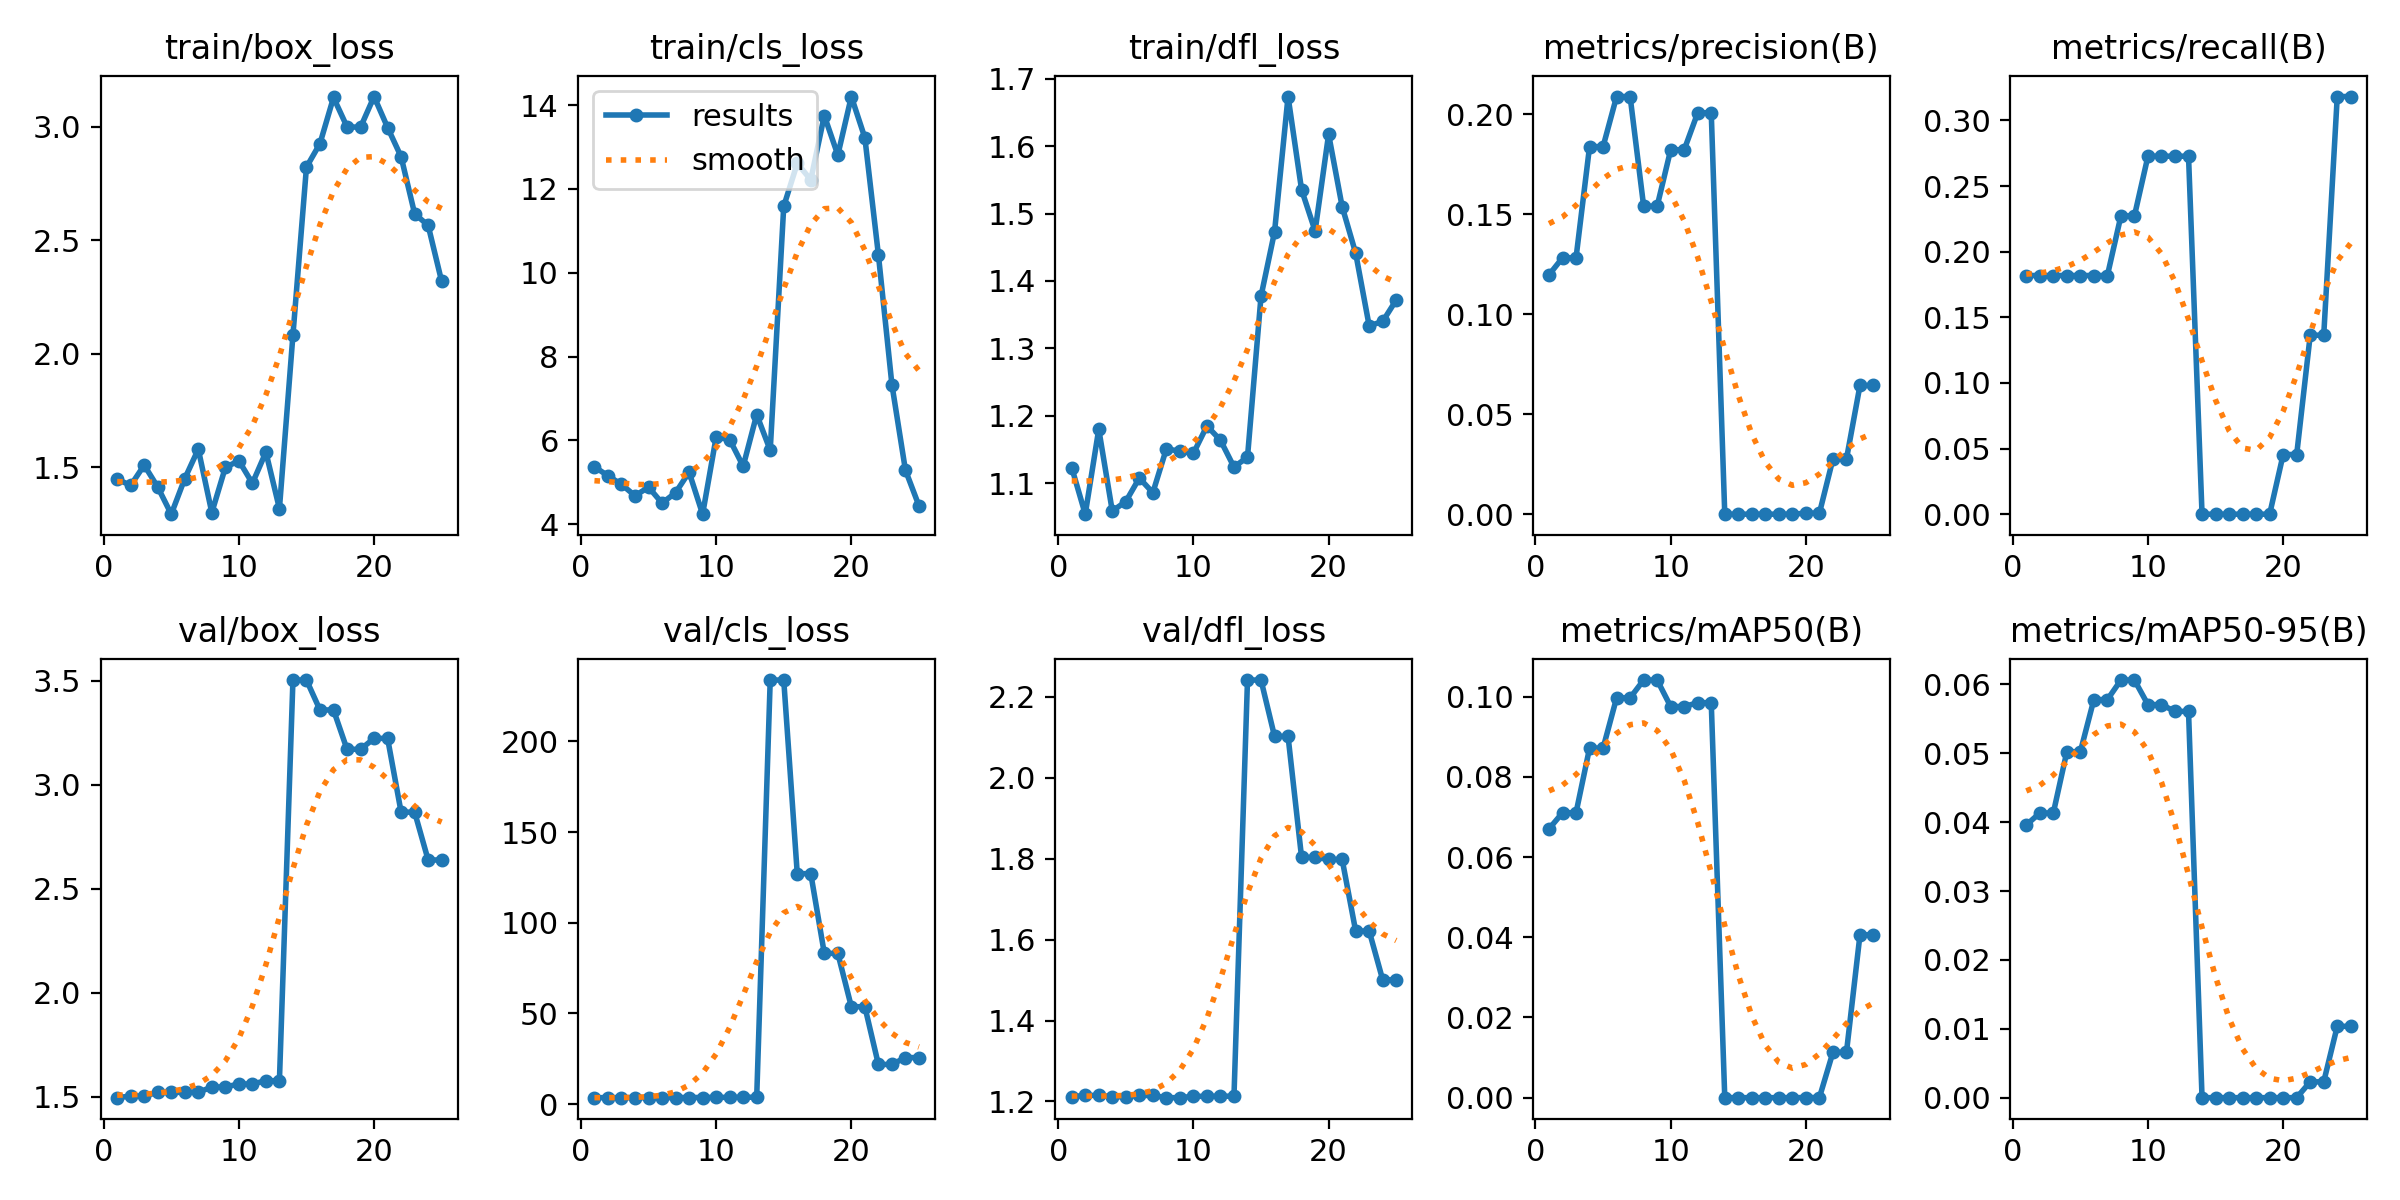

confusion_matrix.png


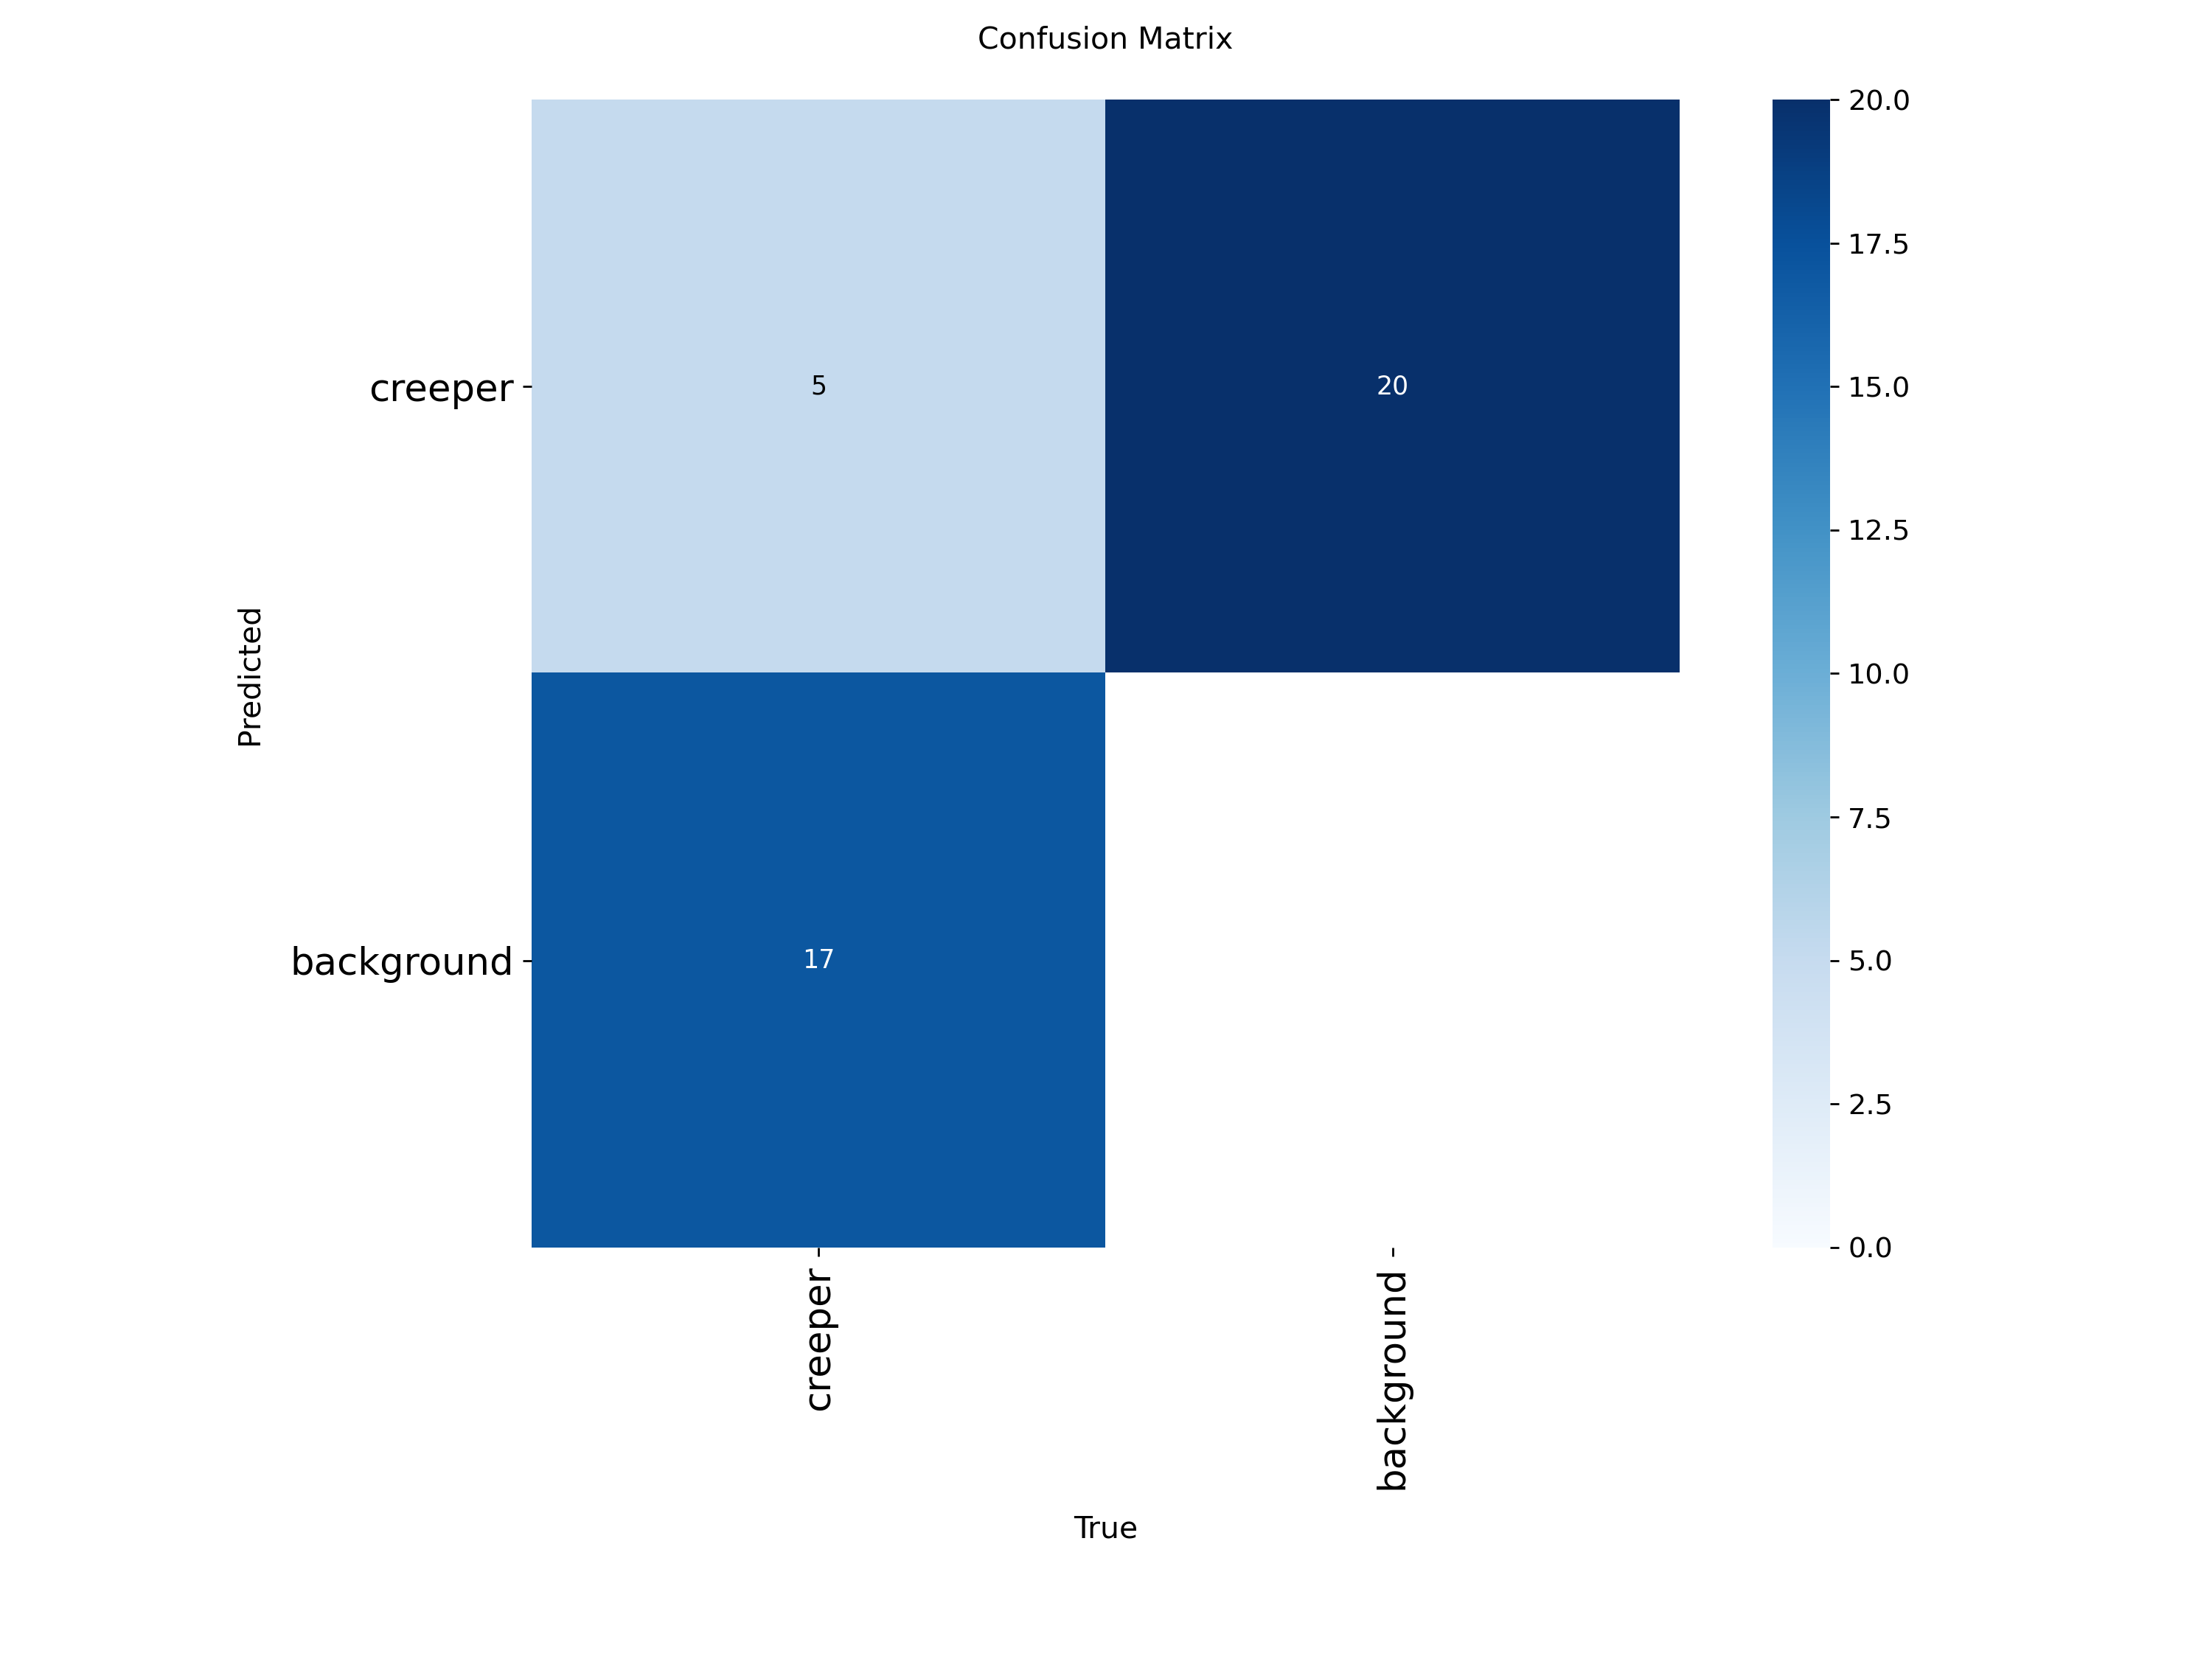

val_batch0_labels.jpg


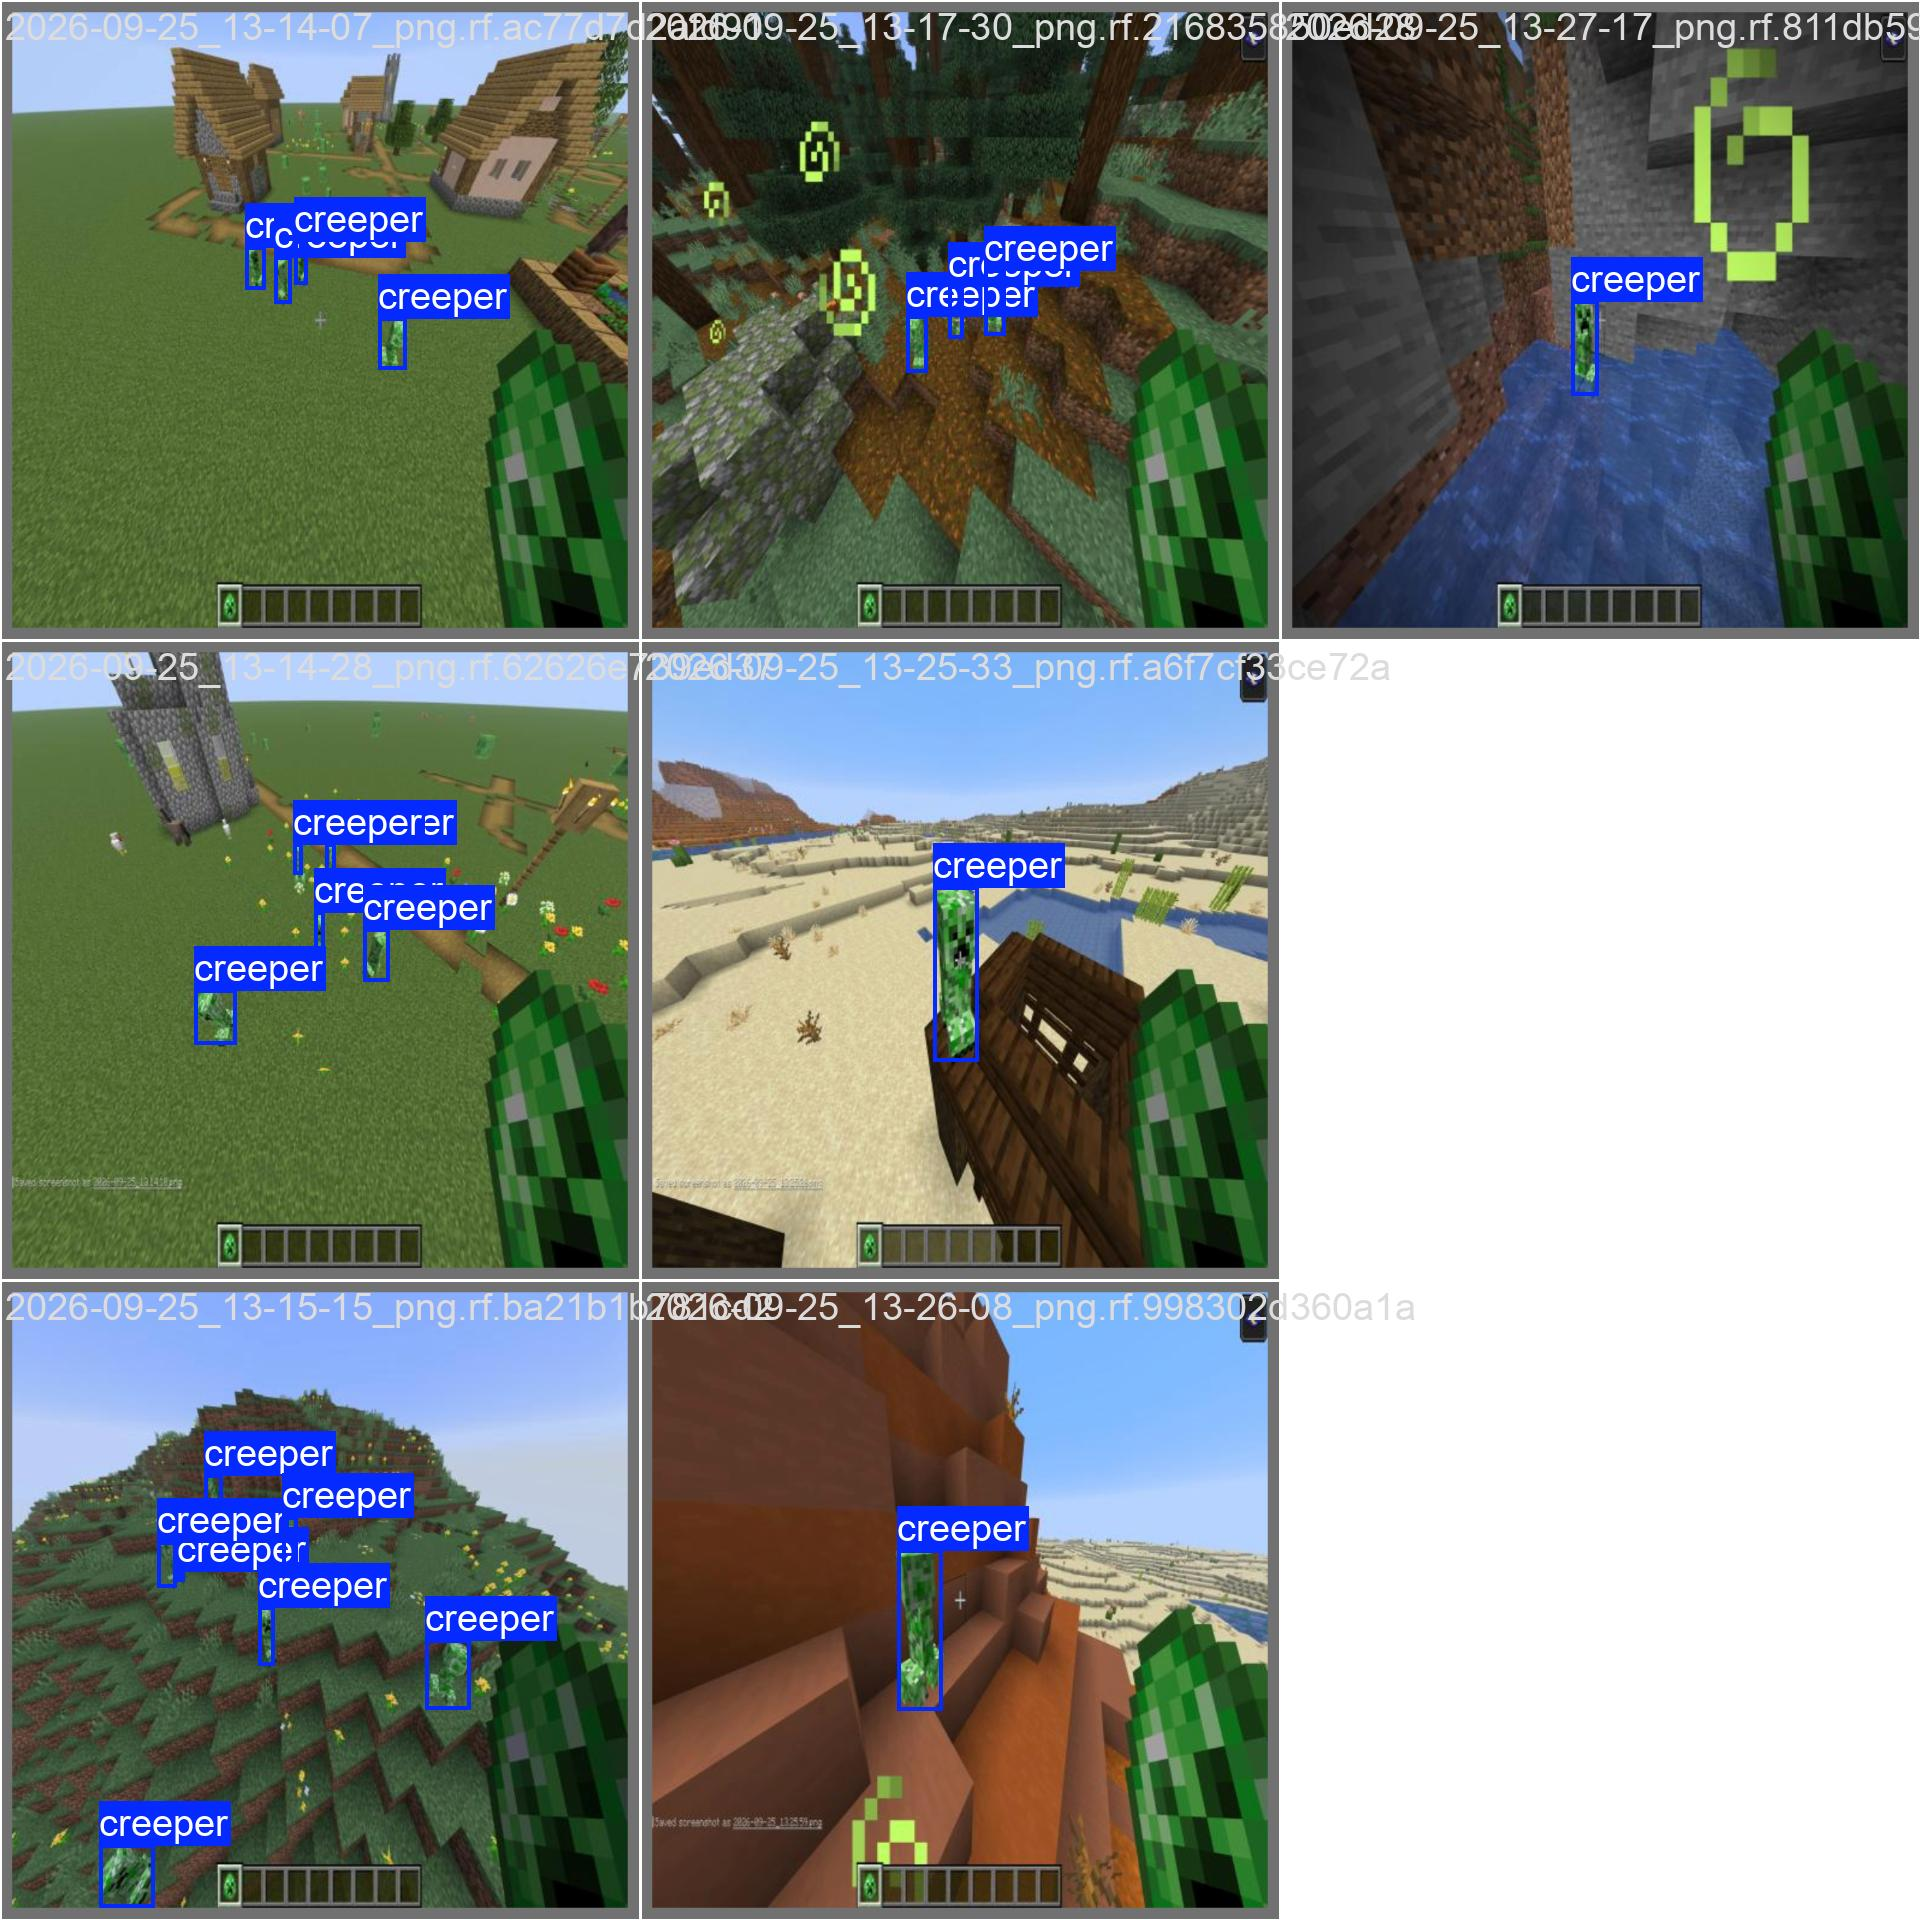

val_batch0_pred.jpg


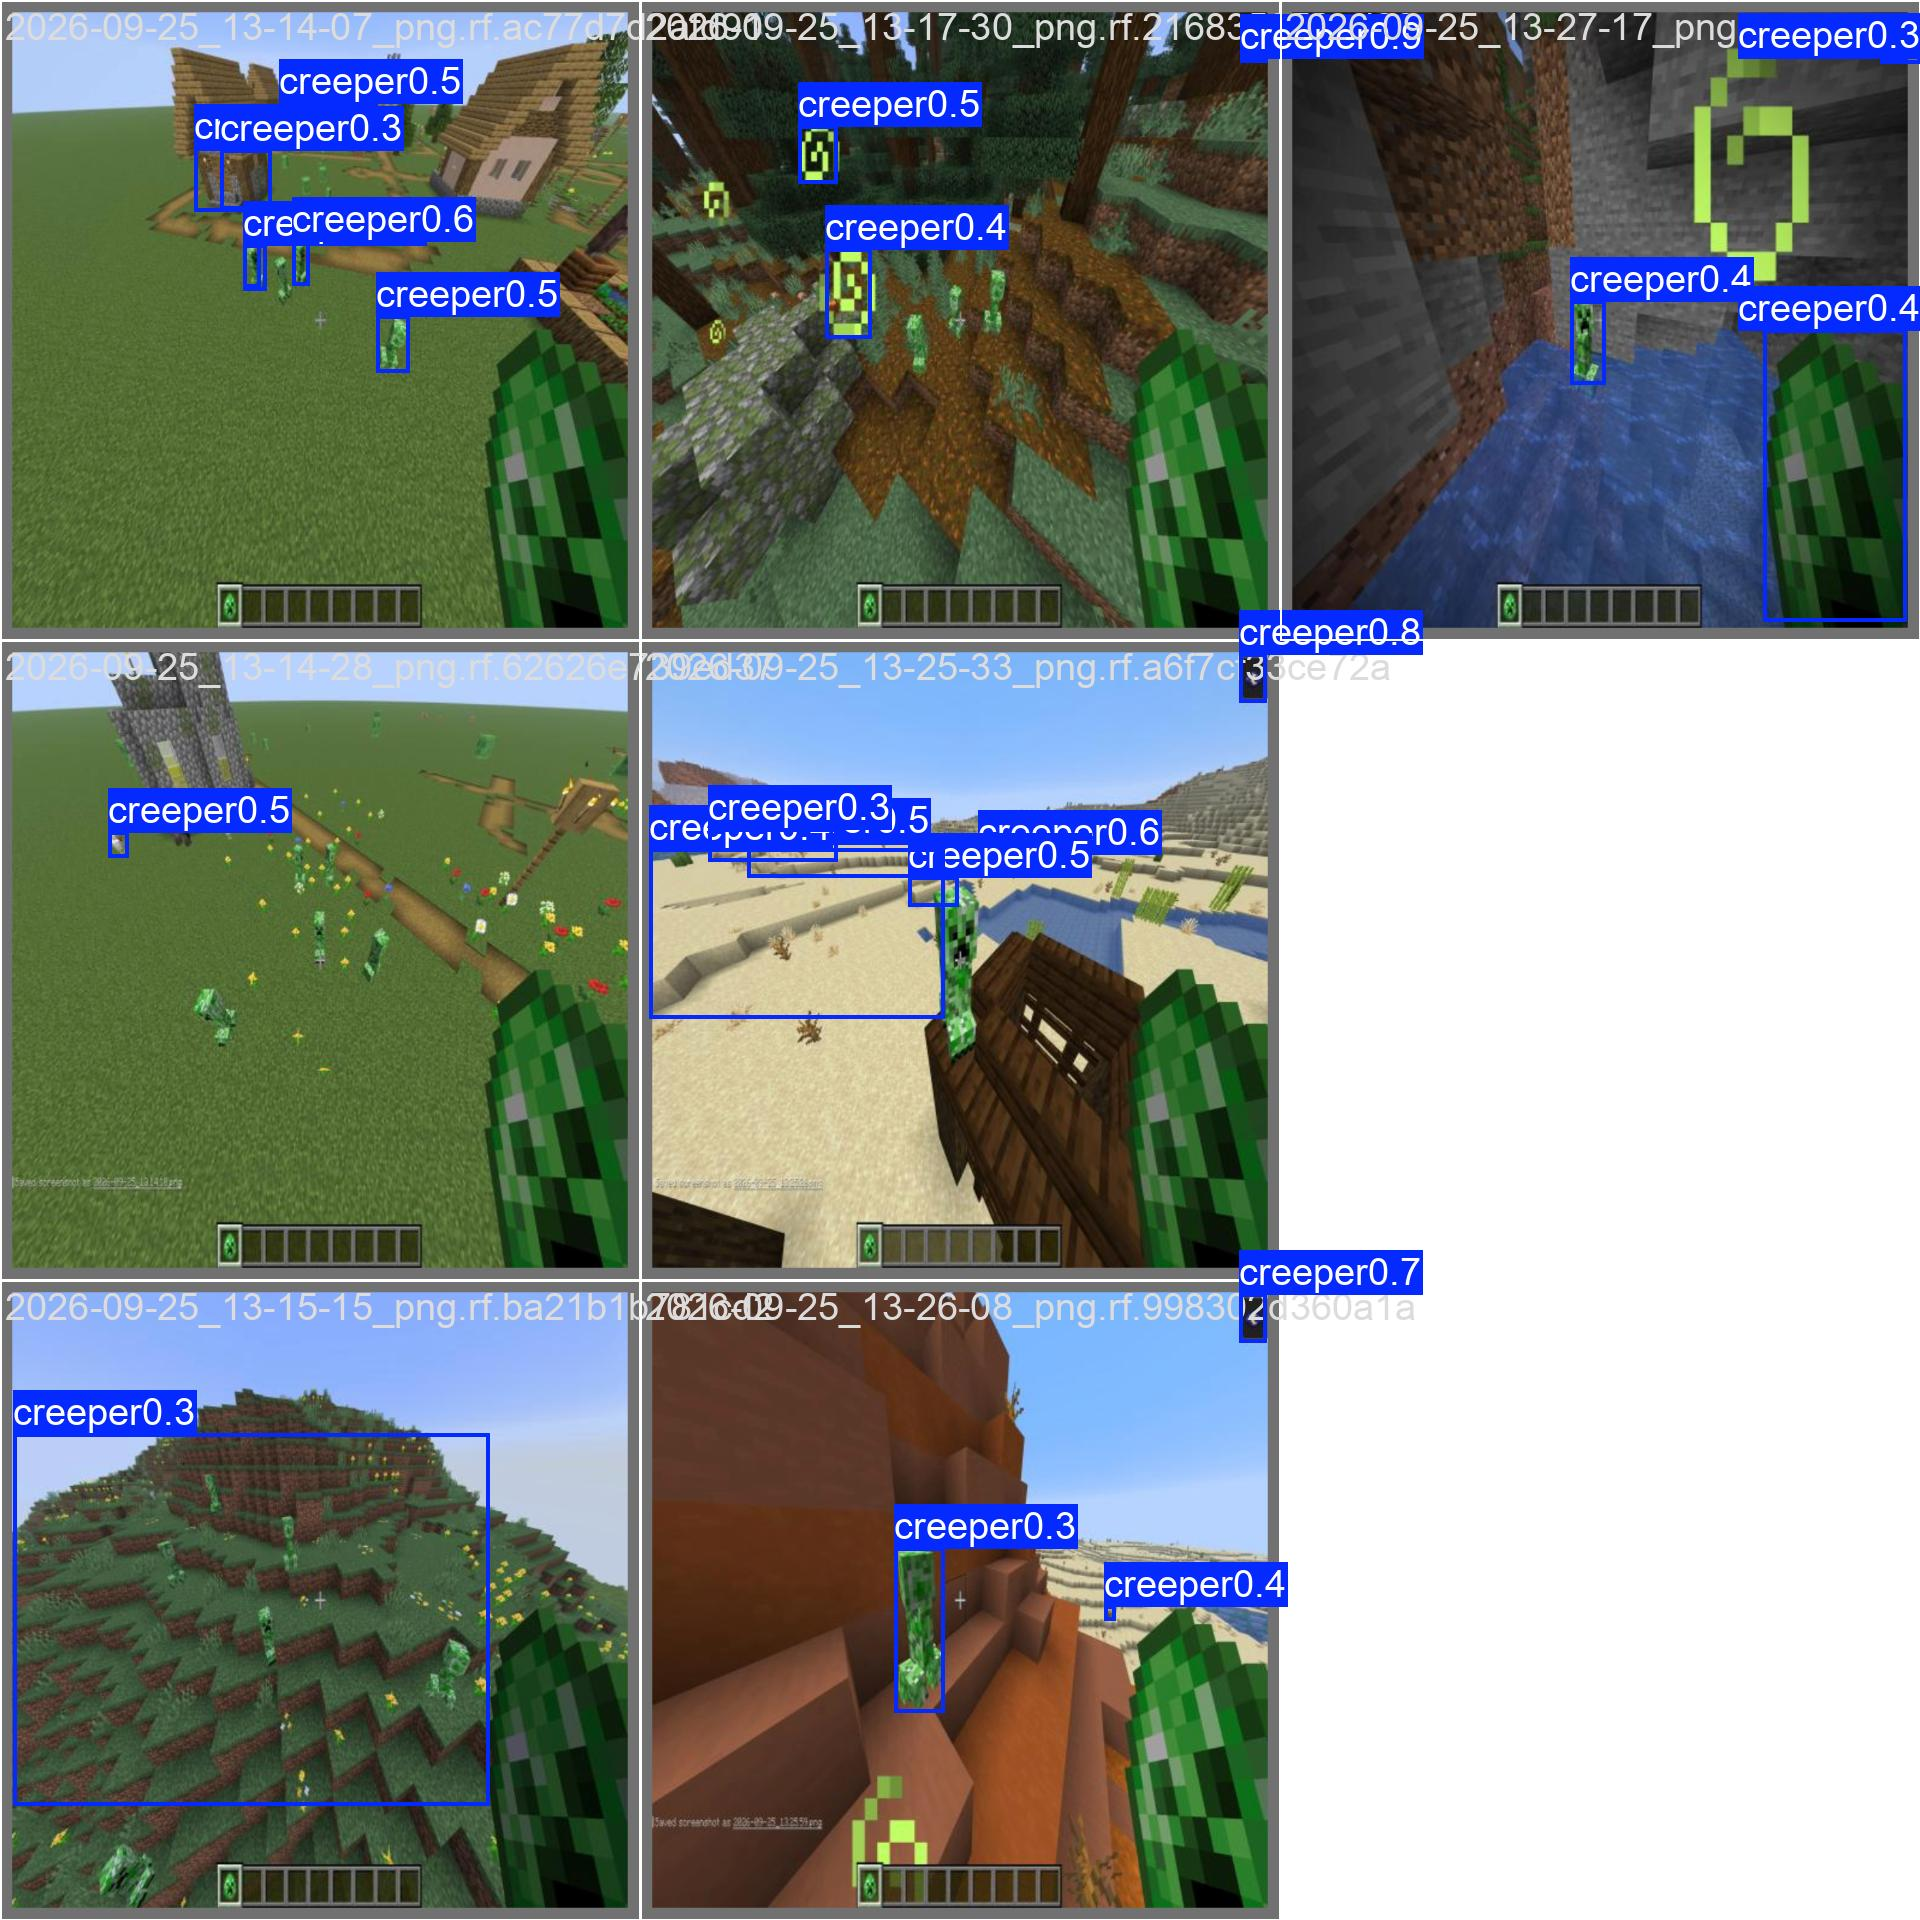

In [20]:
for filename in [
    "results.png",
    "confusion_matrix.png",
    "val_batch0_labels.jpg",
    "val_batch0_pred.jpg"
]:
    path = train_dir / filename

    if path.exists():
        print(filename)
        display(Image(filename=str(path), width=900))


In [21]:
#This is still soo ass bro
#more epochs until I confirm that this is a dataset issue
!yolo task=detect mode=train \
    model=yolov8s.pt \
    data={dataset.location}/data.yaml \
    epochs=100 \
    imgsz=800 \
    plots=True \
    close_mosaic=0 \
    name=creeper_no_mosaic_close

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Software-HW-2,-ML-training-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=creeper_no_mosaic_close-2, nb

In [23]:
!yolo detect predict \
    model="{best_model}" \
    source="{dataset.location}/test/images" \
    conf=0.25 \
    save=True \
    project="{HOME}/runs/detect" \
    name="creeper_no_mosaic_close-2" \
    exist_ok=True

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/3 /content/Software-HW-2,-ML-training-2/test/images/2026-09-25_13-14-18_png.rf.a10c939b5cd731c8fc3f10d53ea26802.jpg: 800x800 13 creepers, 22.3ms
image 2/3 /content/Software-HW-2,-ML-training-2/test/images/2026-09-25_13-15-45_png.rf.79abb50387a422be18c9c79ae8b7ee39.jpg: 800x800 3 creepers, 22.2ms
image 3/3 /content/Software-HW-2,-ML-training-2/test/images/2026-09-25_13-16-23_png.rf.a0c5c4642eca1e90f1914a3d1f9be228.jpg: 800x800 3 creepers, 22.2ms
Speed: 18.5ms preprocess, 22.2ms inference, 9.4ms postprocess per image at shape (1, 3, 800, 800)
Results saved to /content/runs/detect/creeper_no_mosaic_close-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


2026-09-25_13-14-18_png.rf.a10c939b5cd731c8fc3f10d53ea26802.jpg


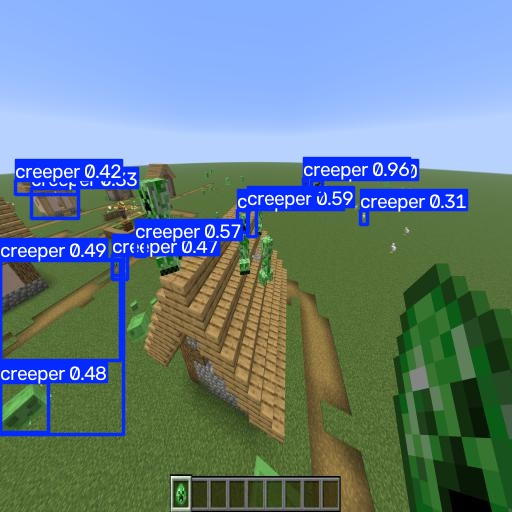

2026-09-25_13-15-45_png.rf.79abb50387a422be18c9c79ae8b7ee39.jpg


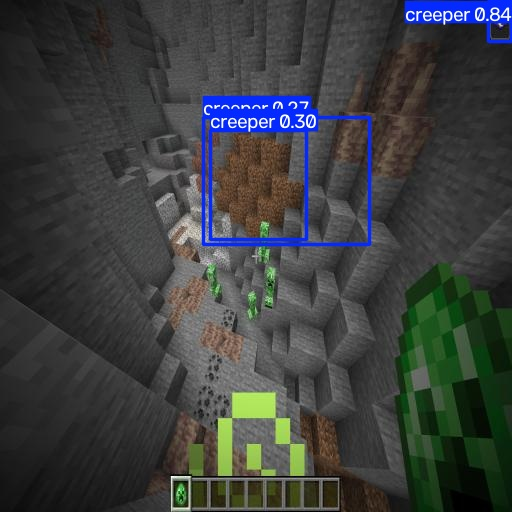

2026-09-25_13-16-23_png.rf.a0c5c4642eca1e90f1914a3d1f9be228.jpg


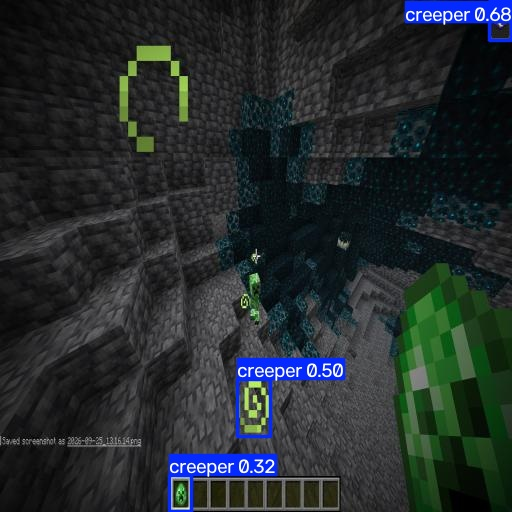

BoxF1_curve.png


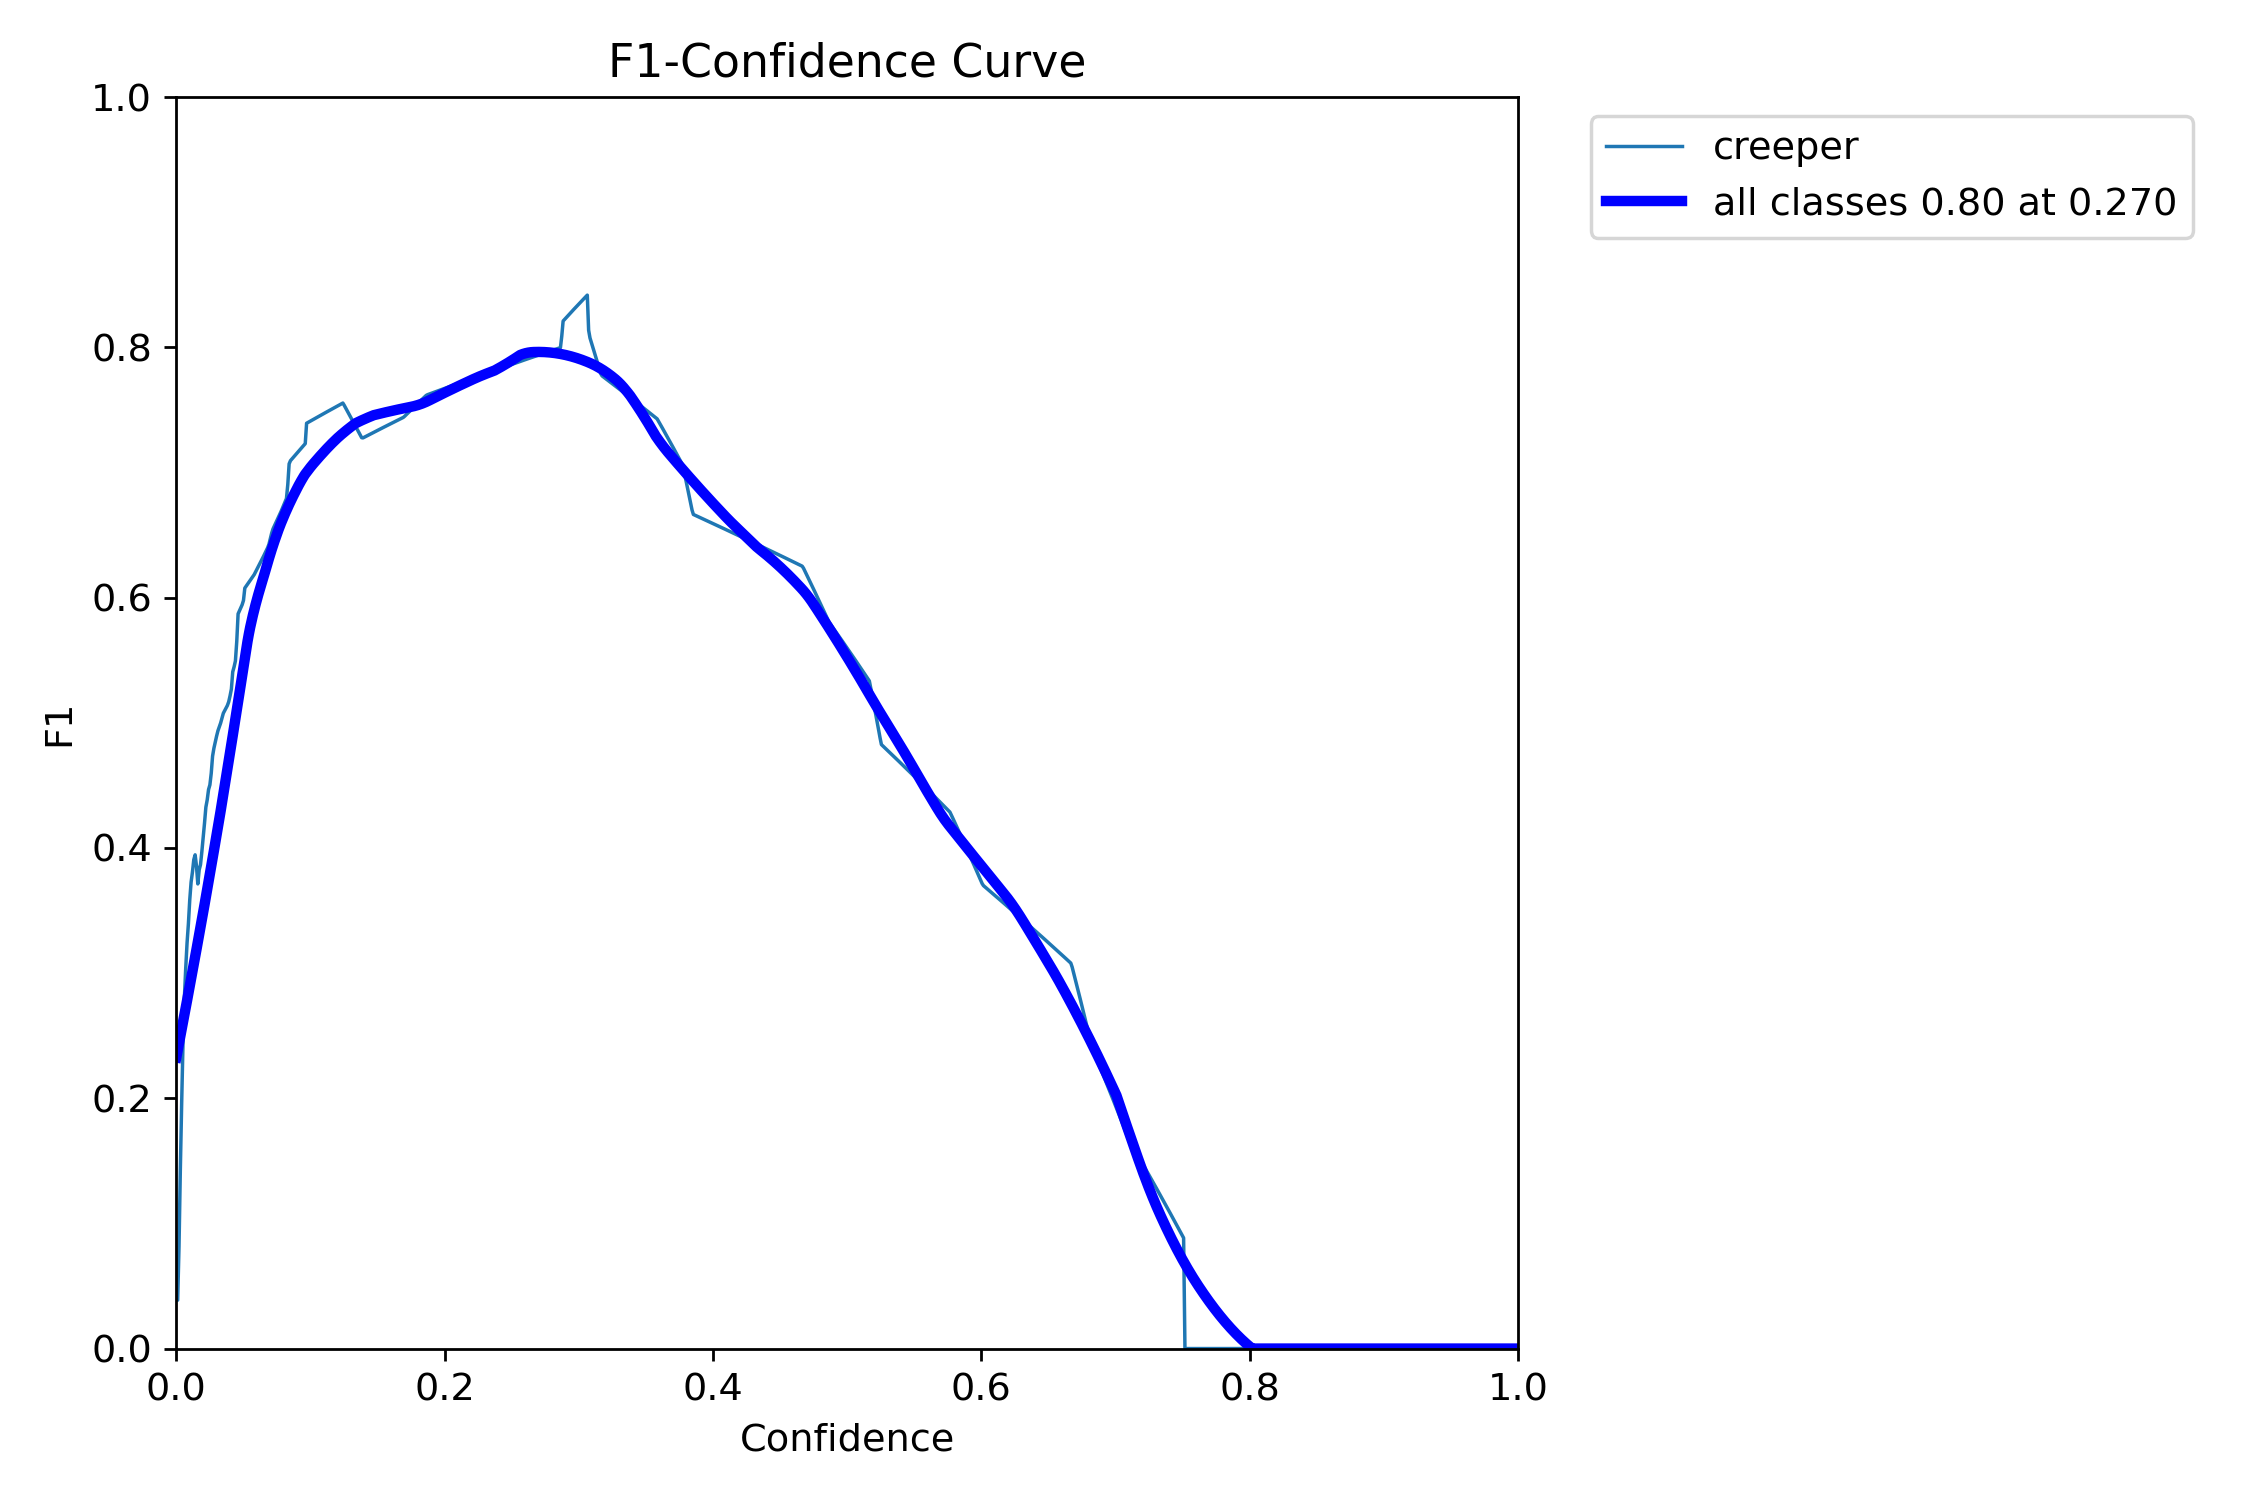

BoxPR_curve.png


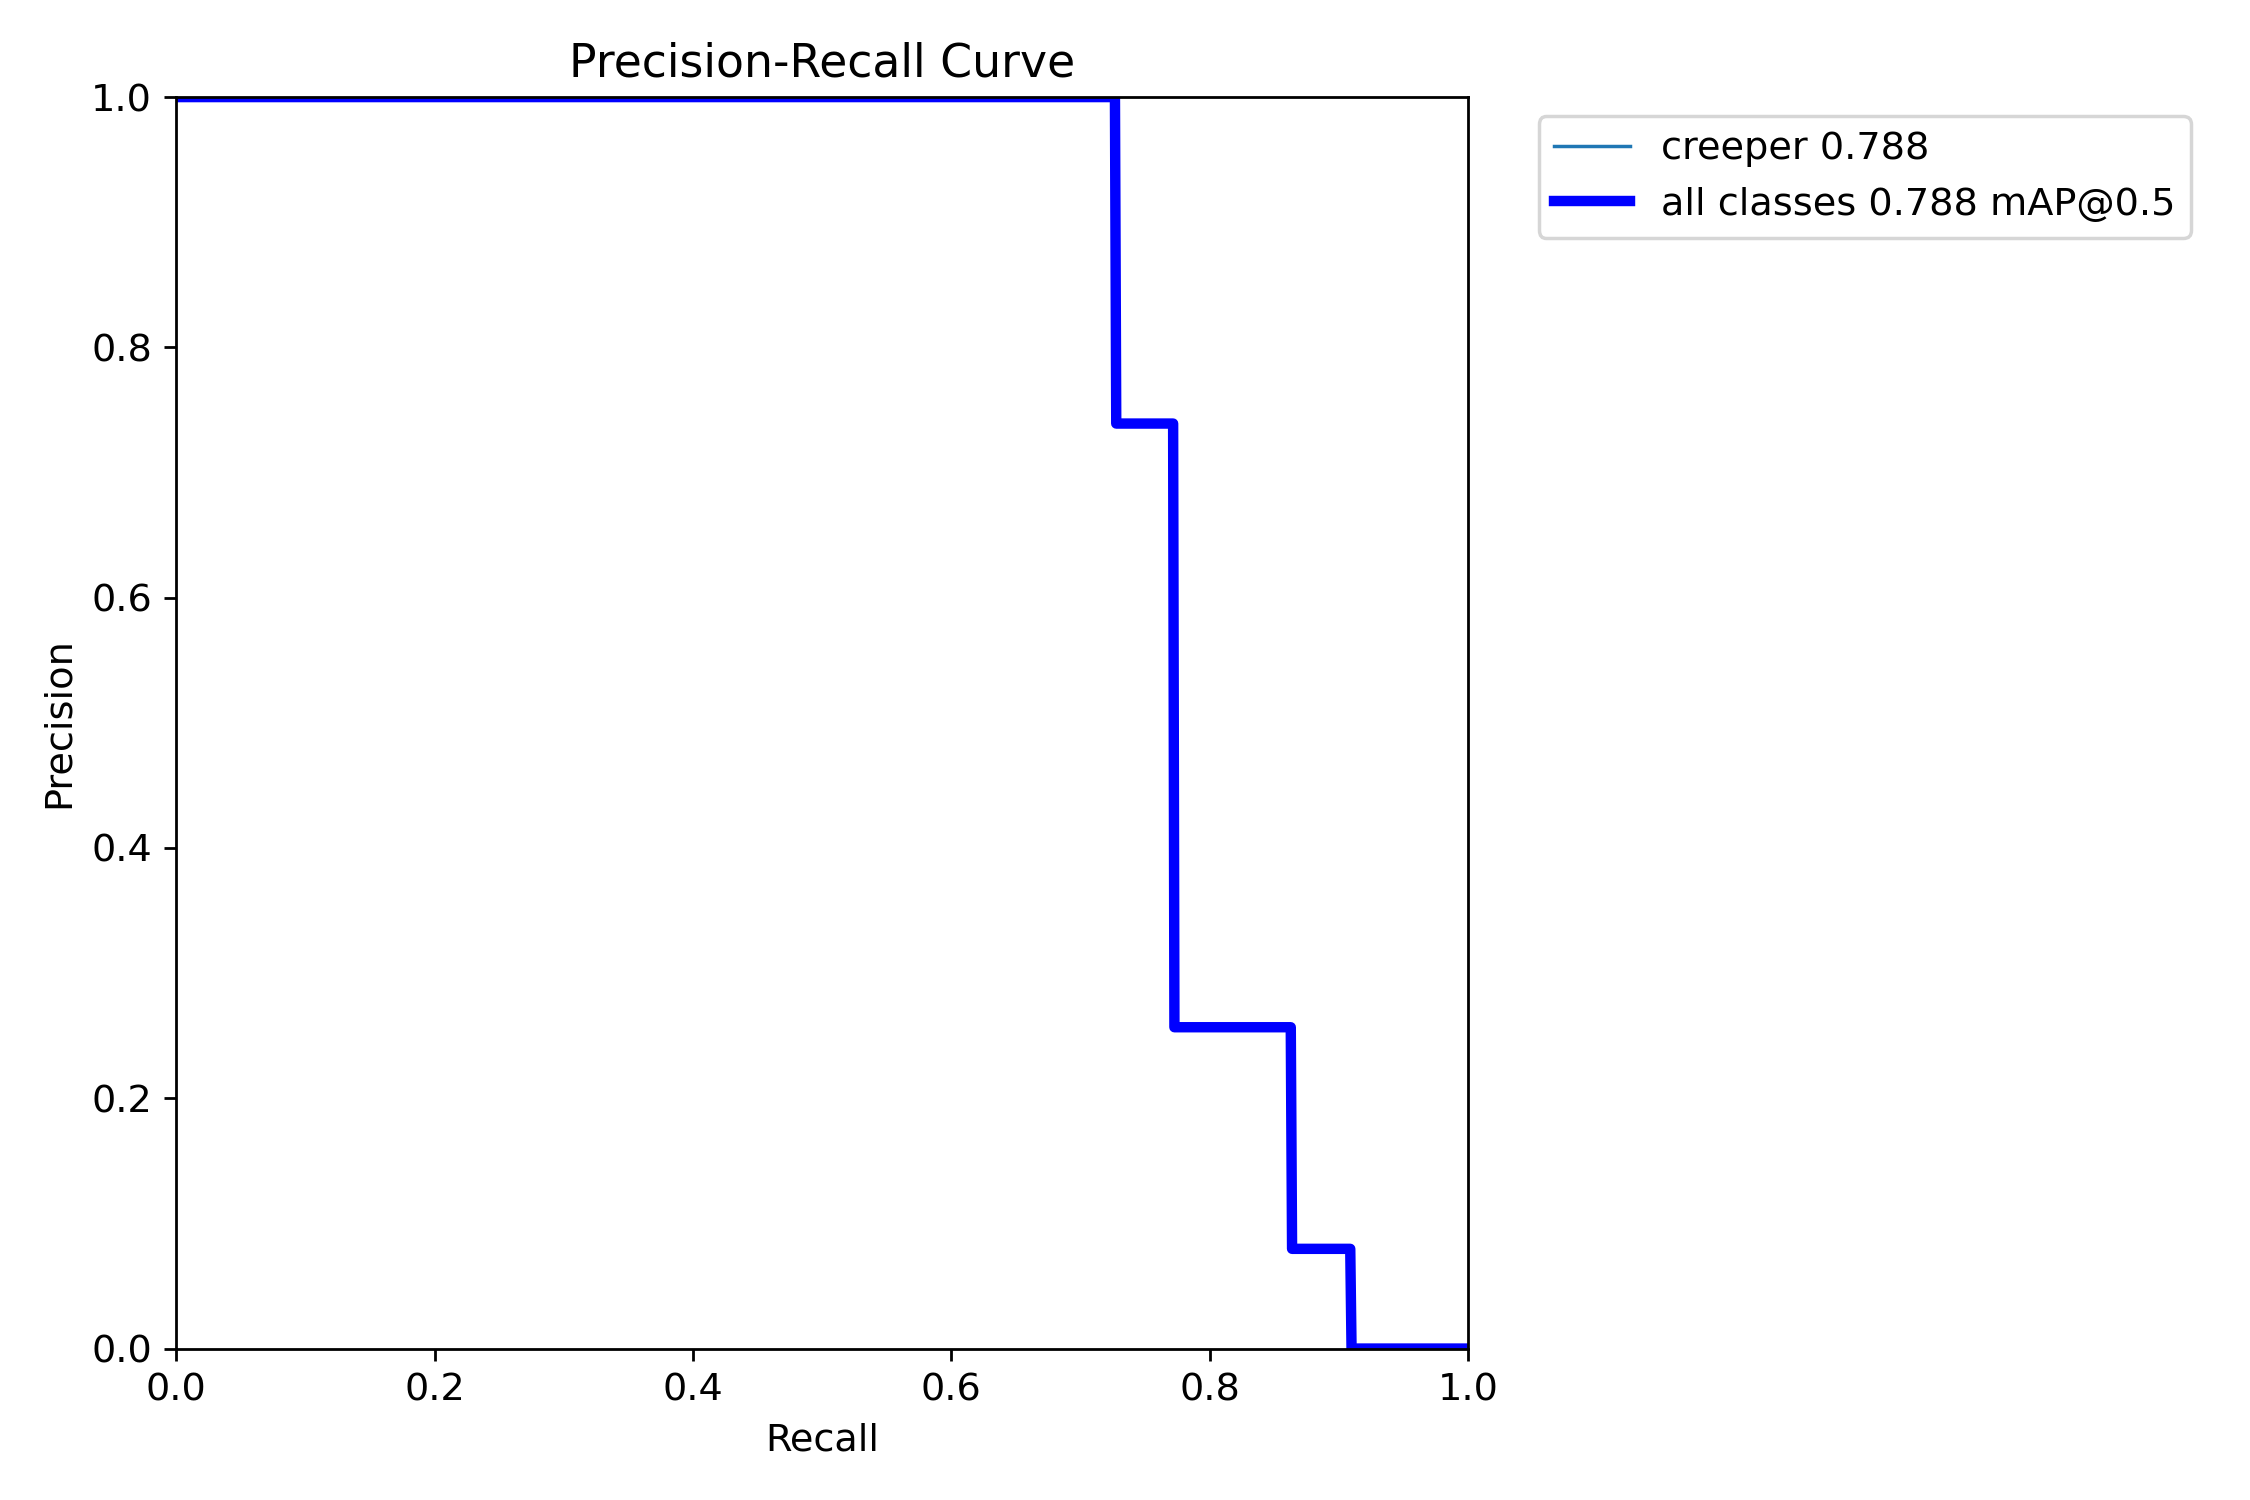

BoxP_curve.png


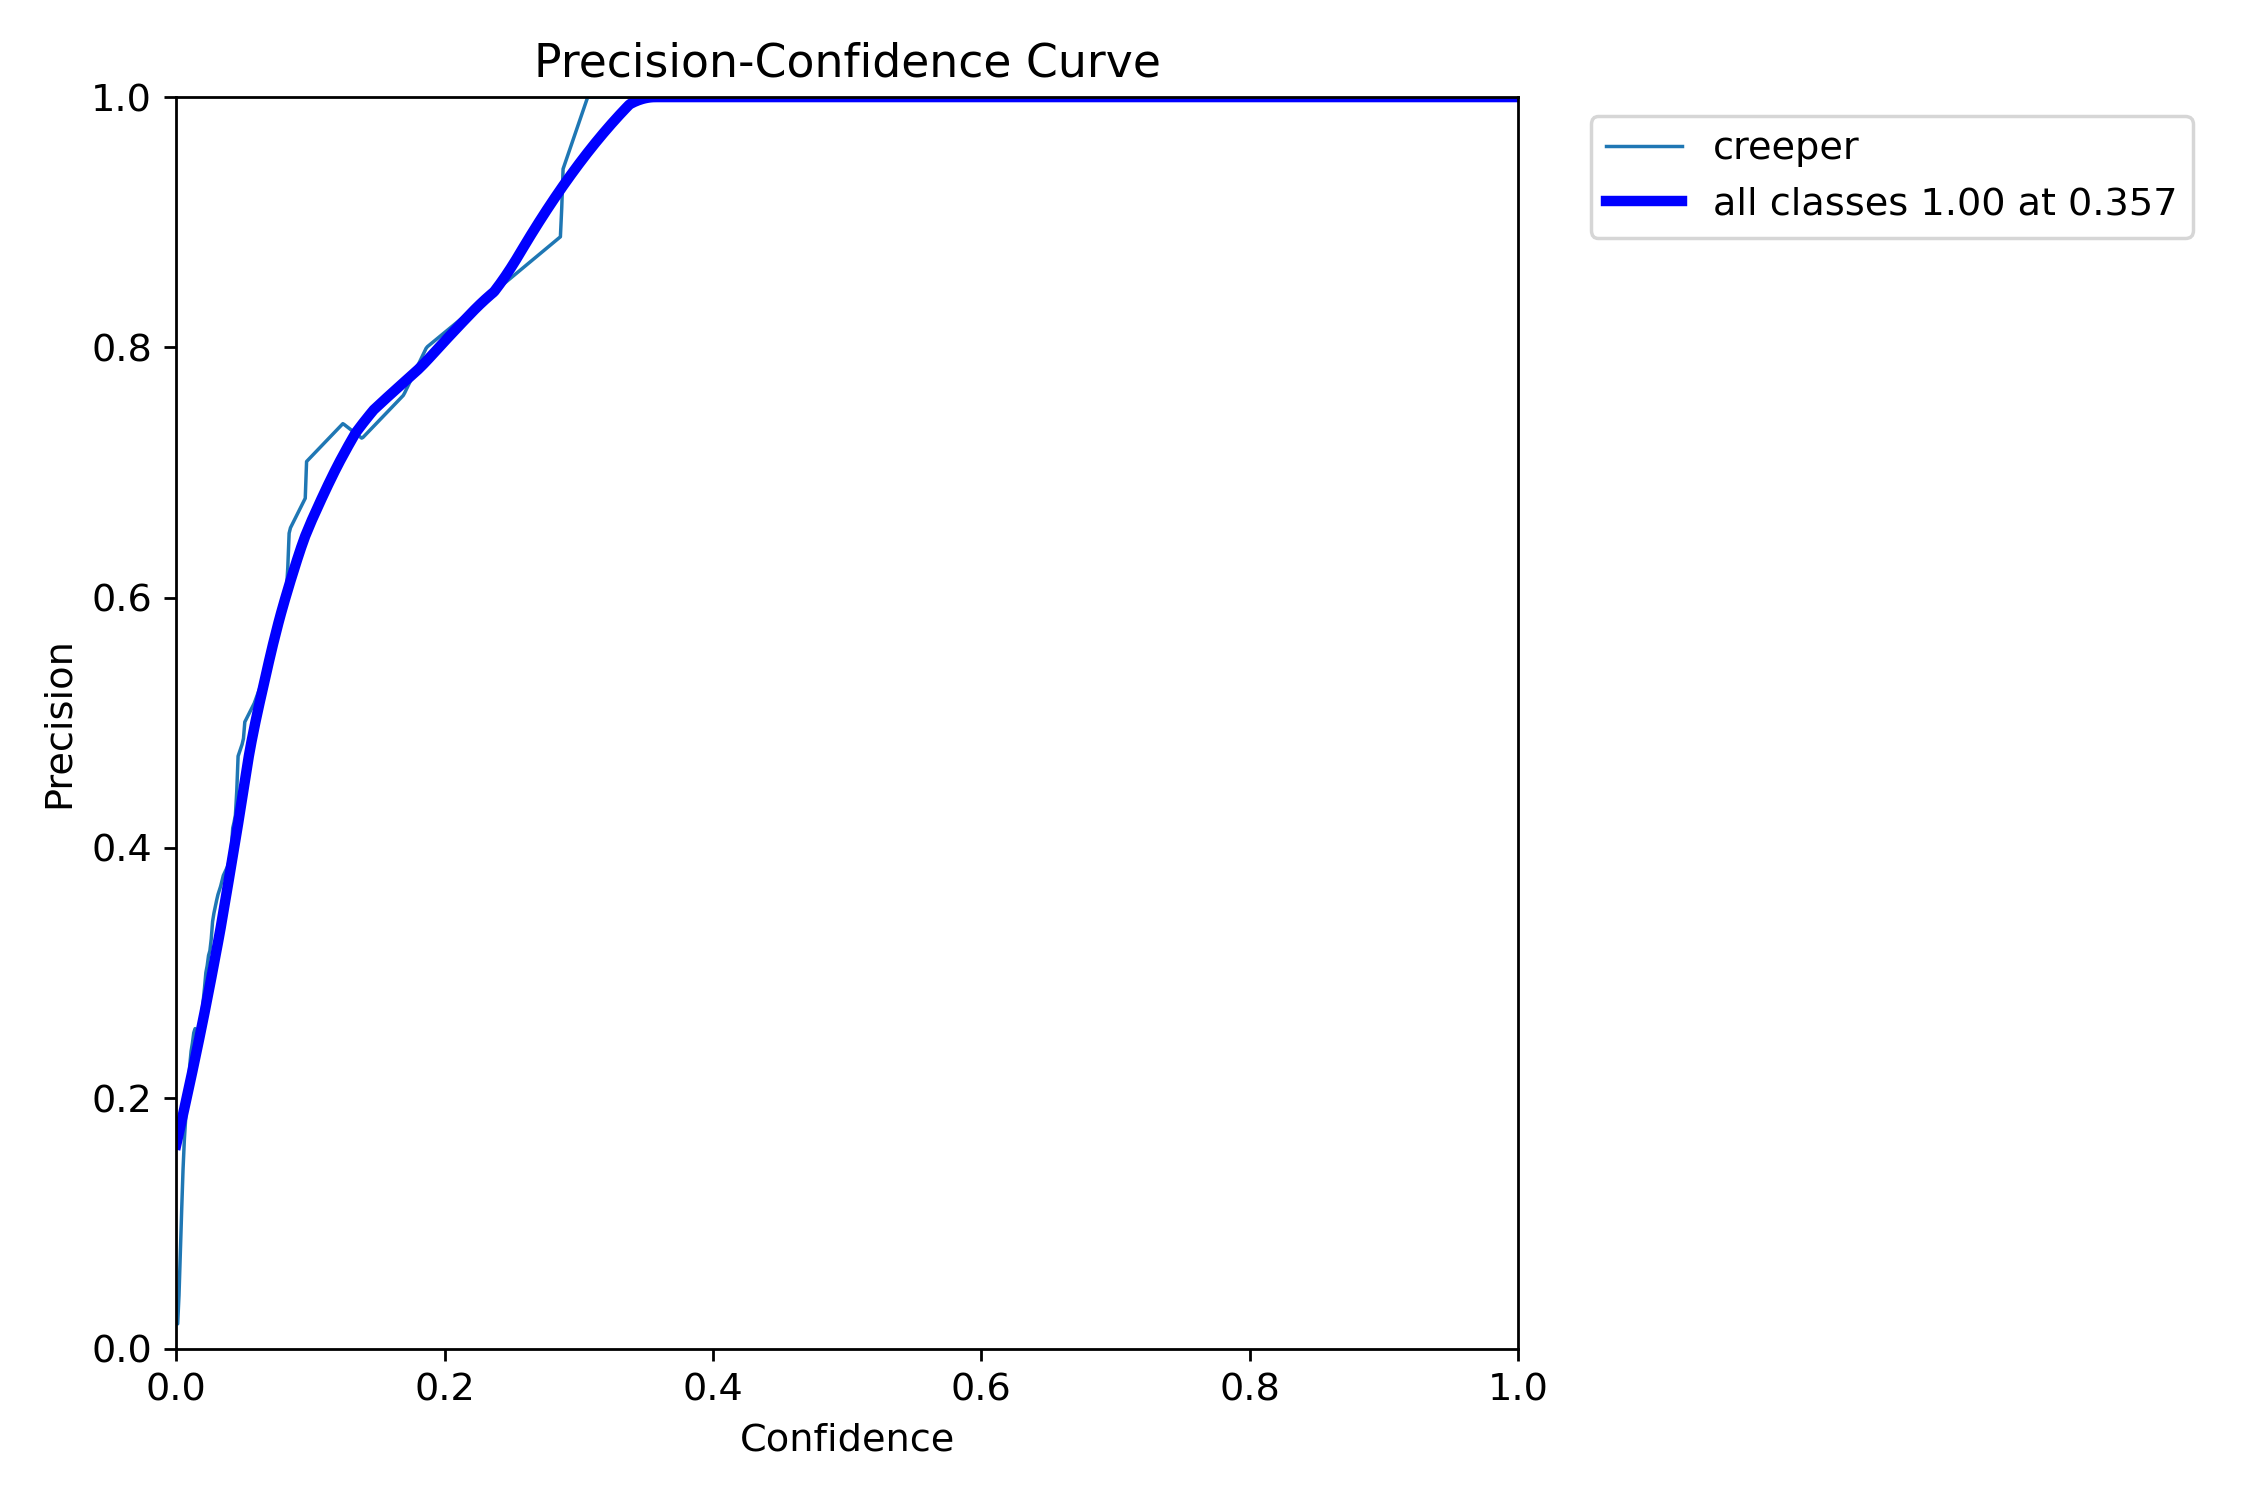

BoxR_curve.png


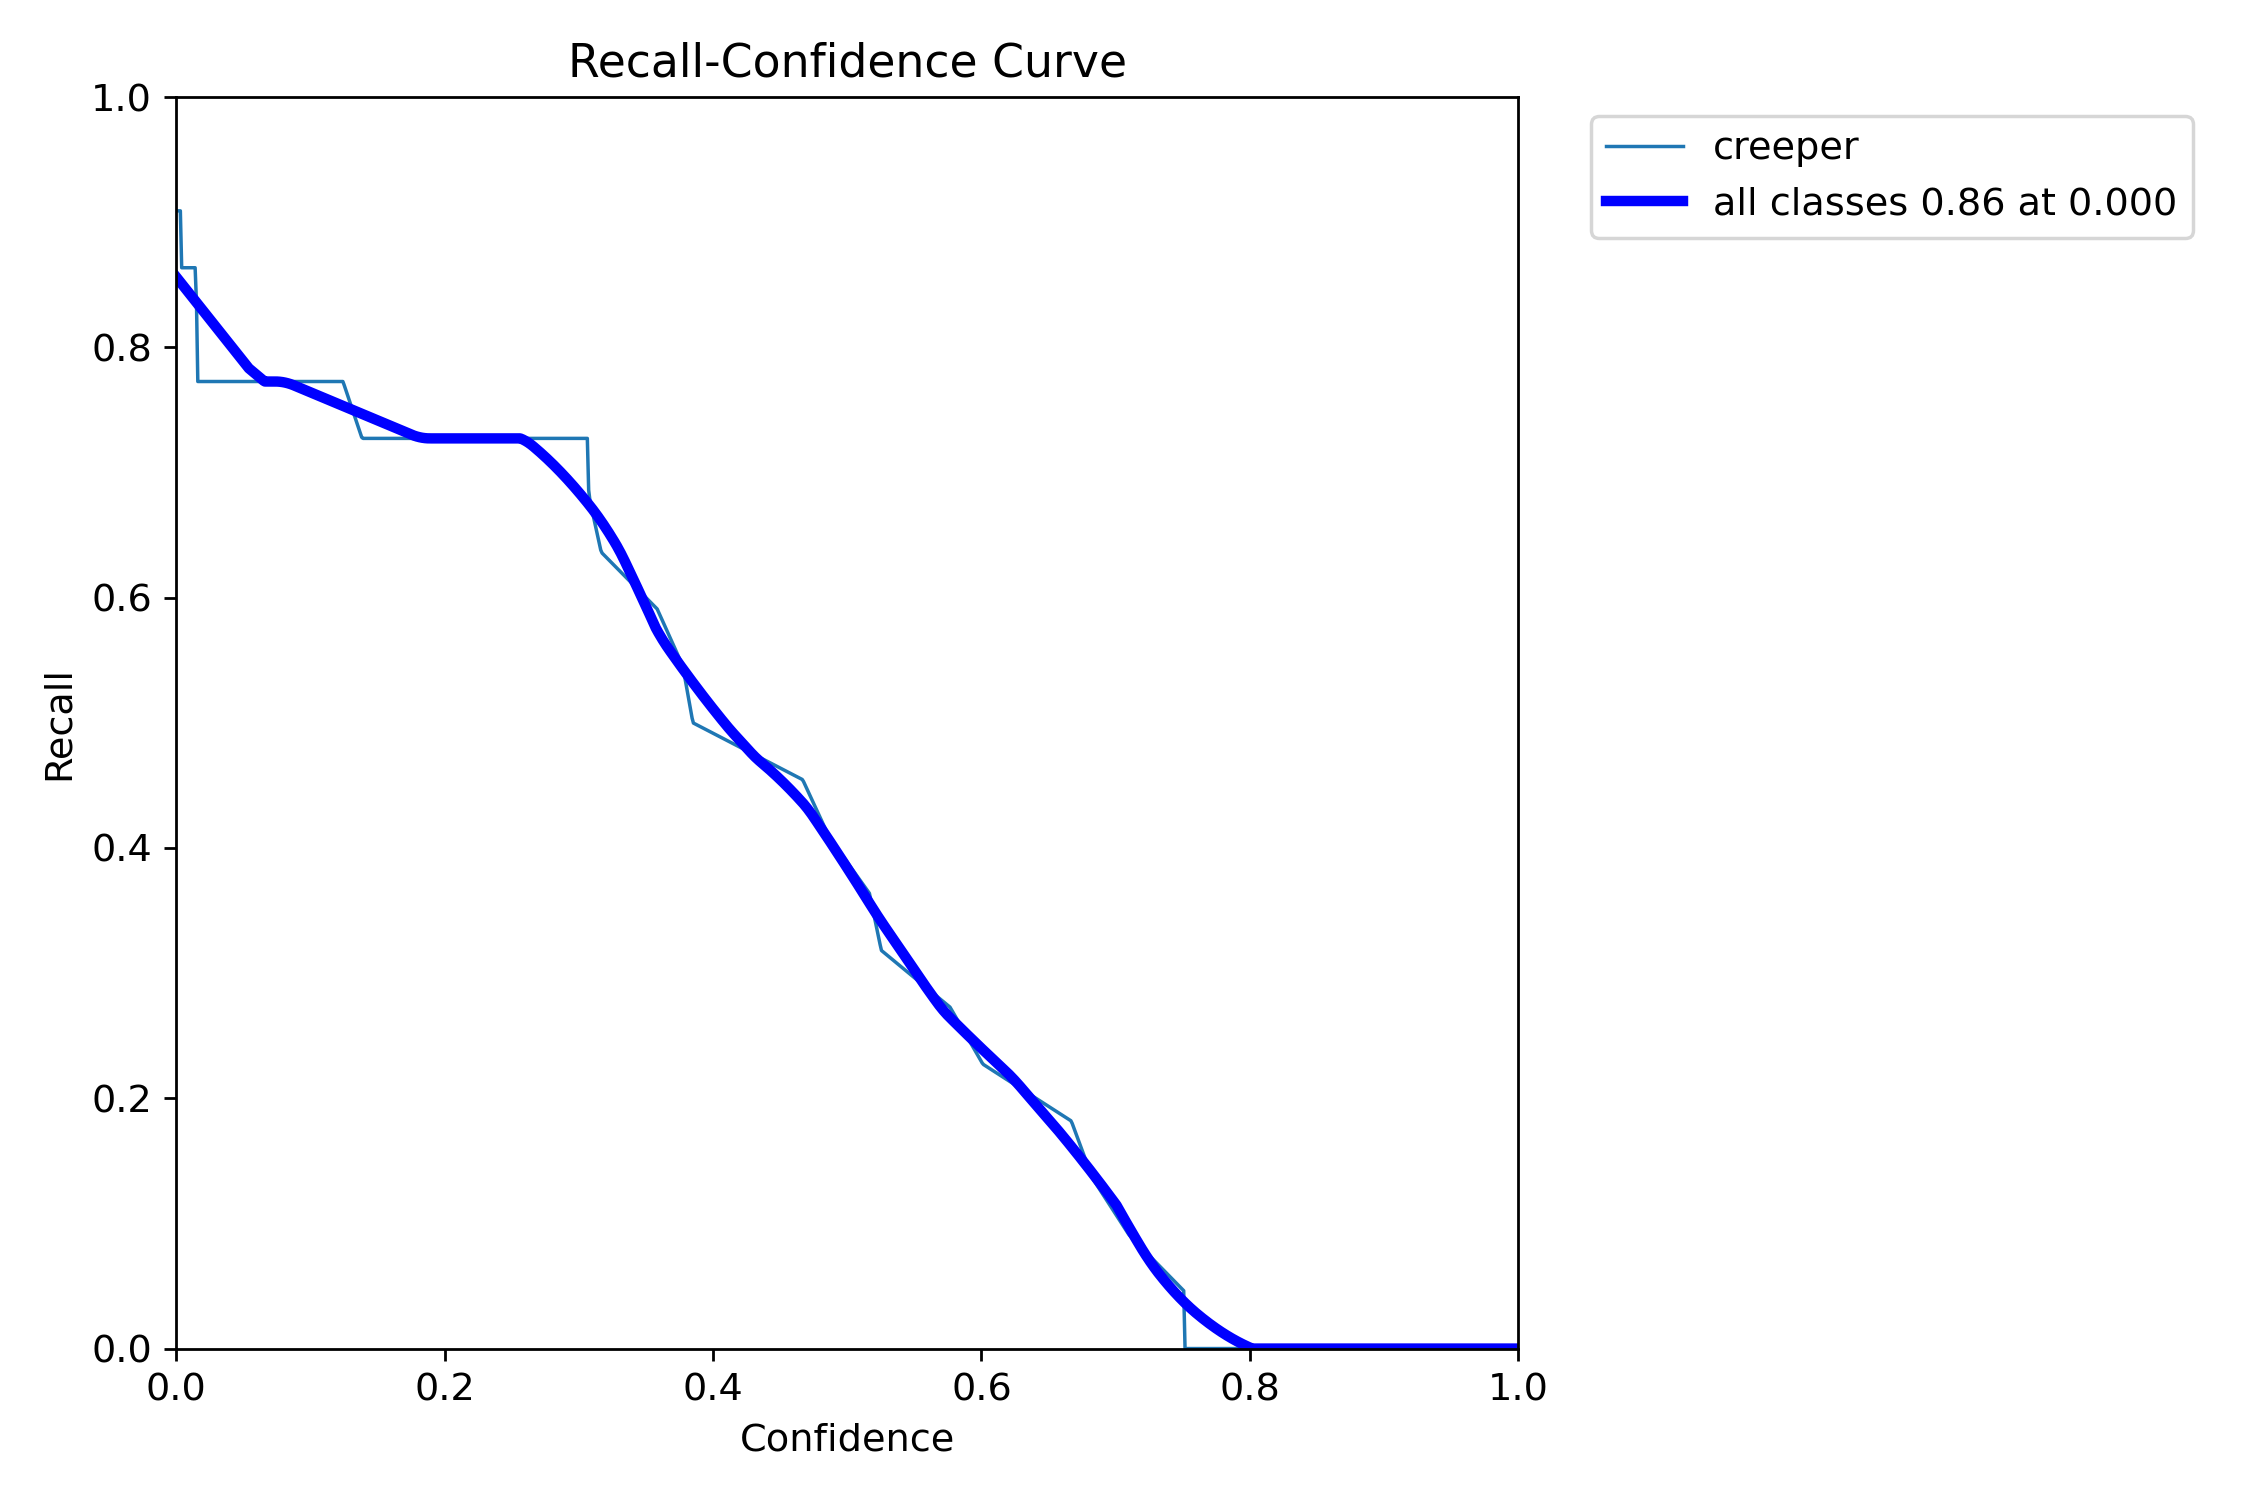

confusion_matrix.png


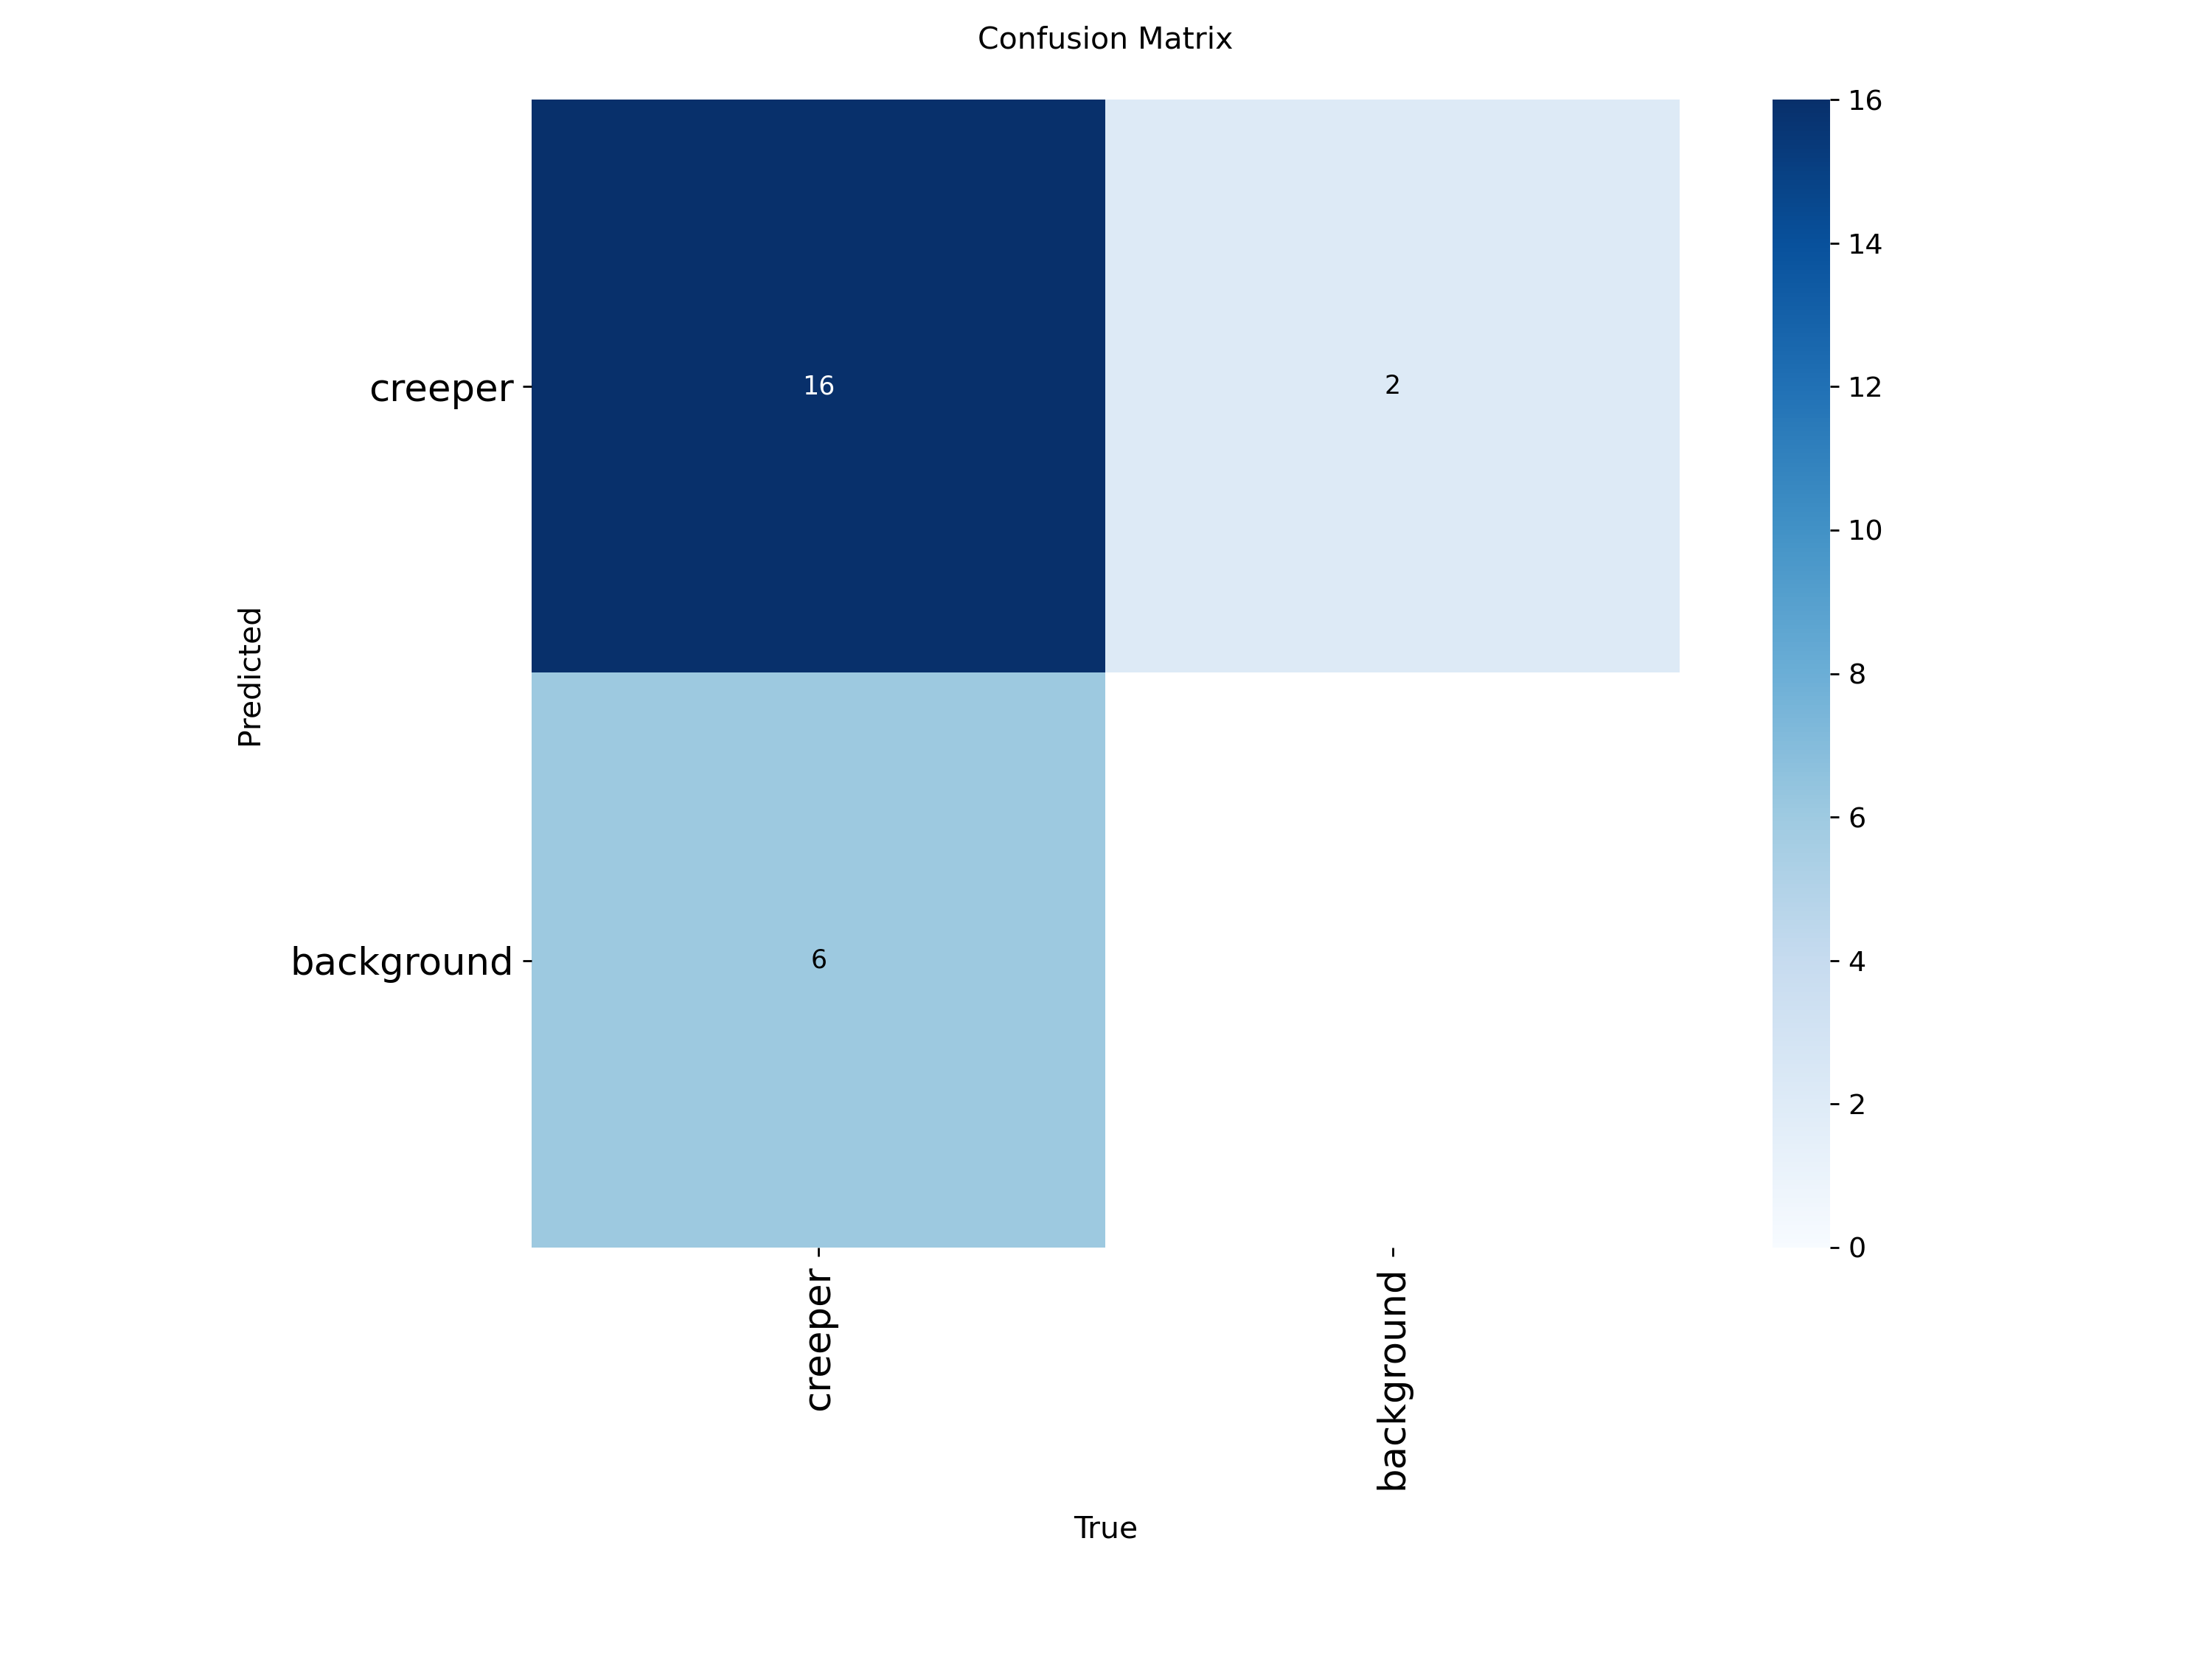

confusion_matrix_normalized.png


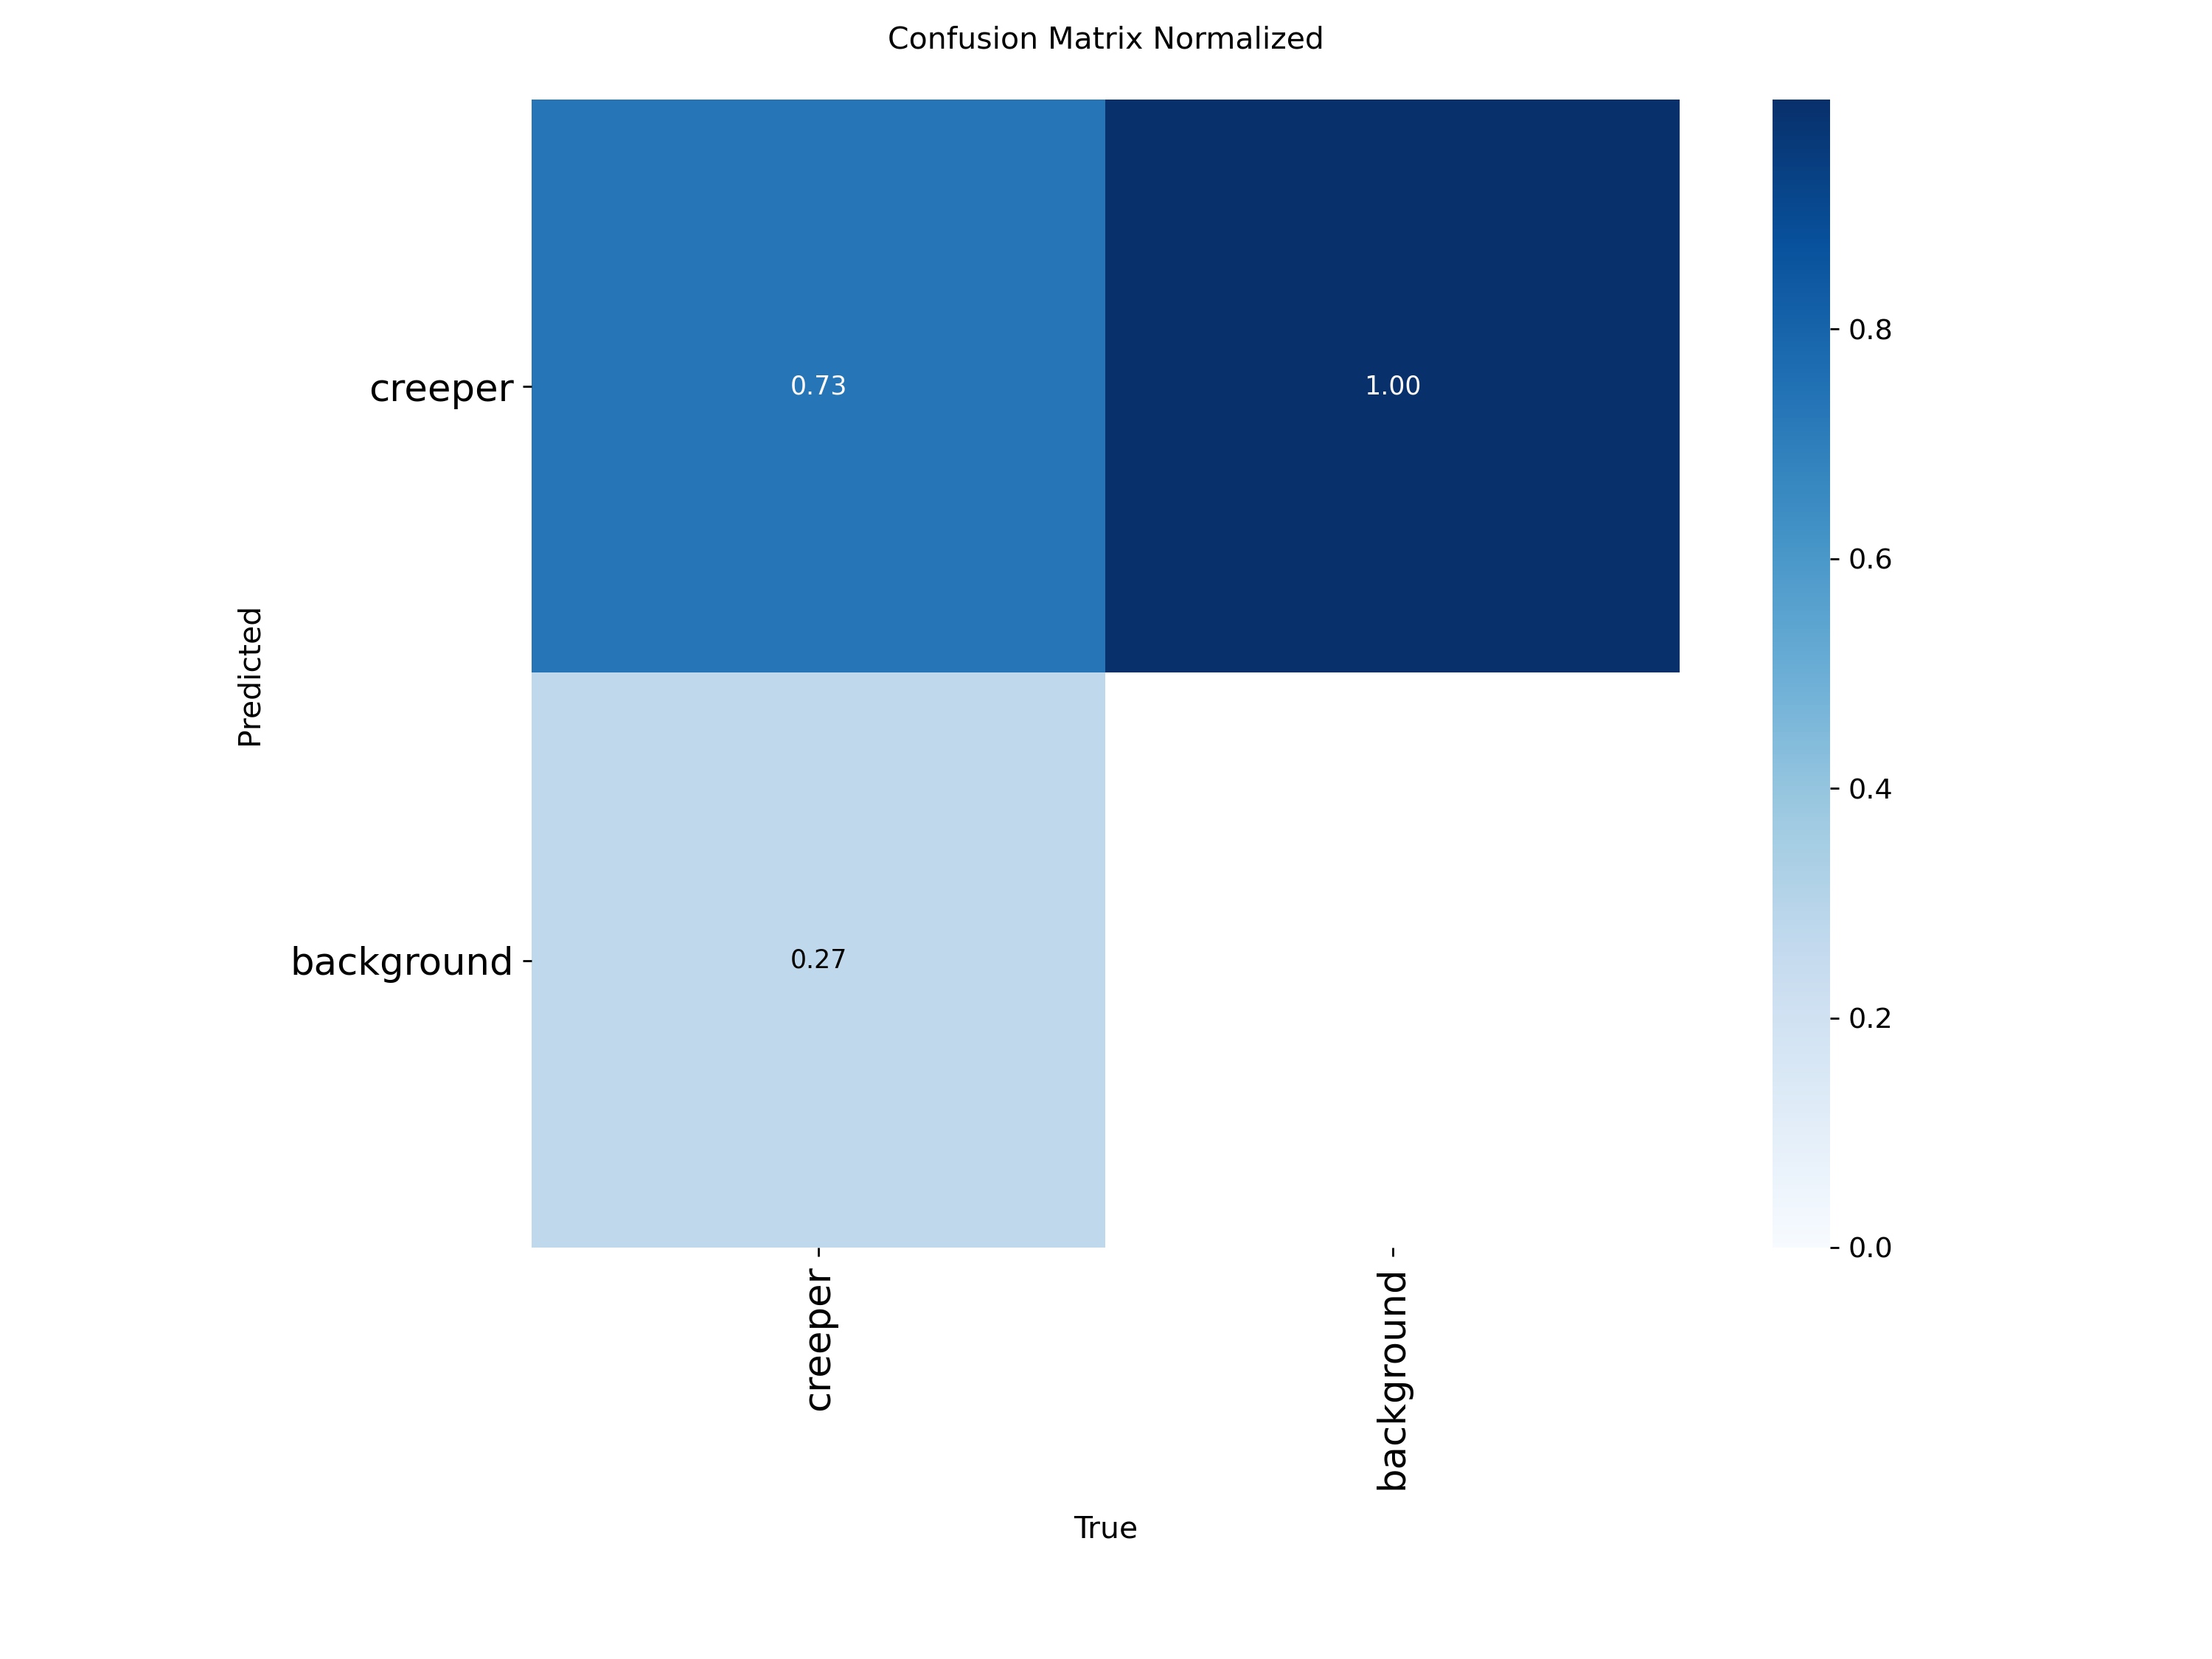

labels.jpg


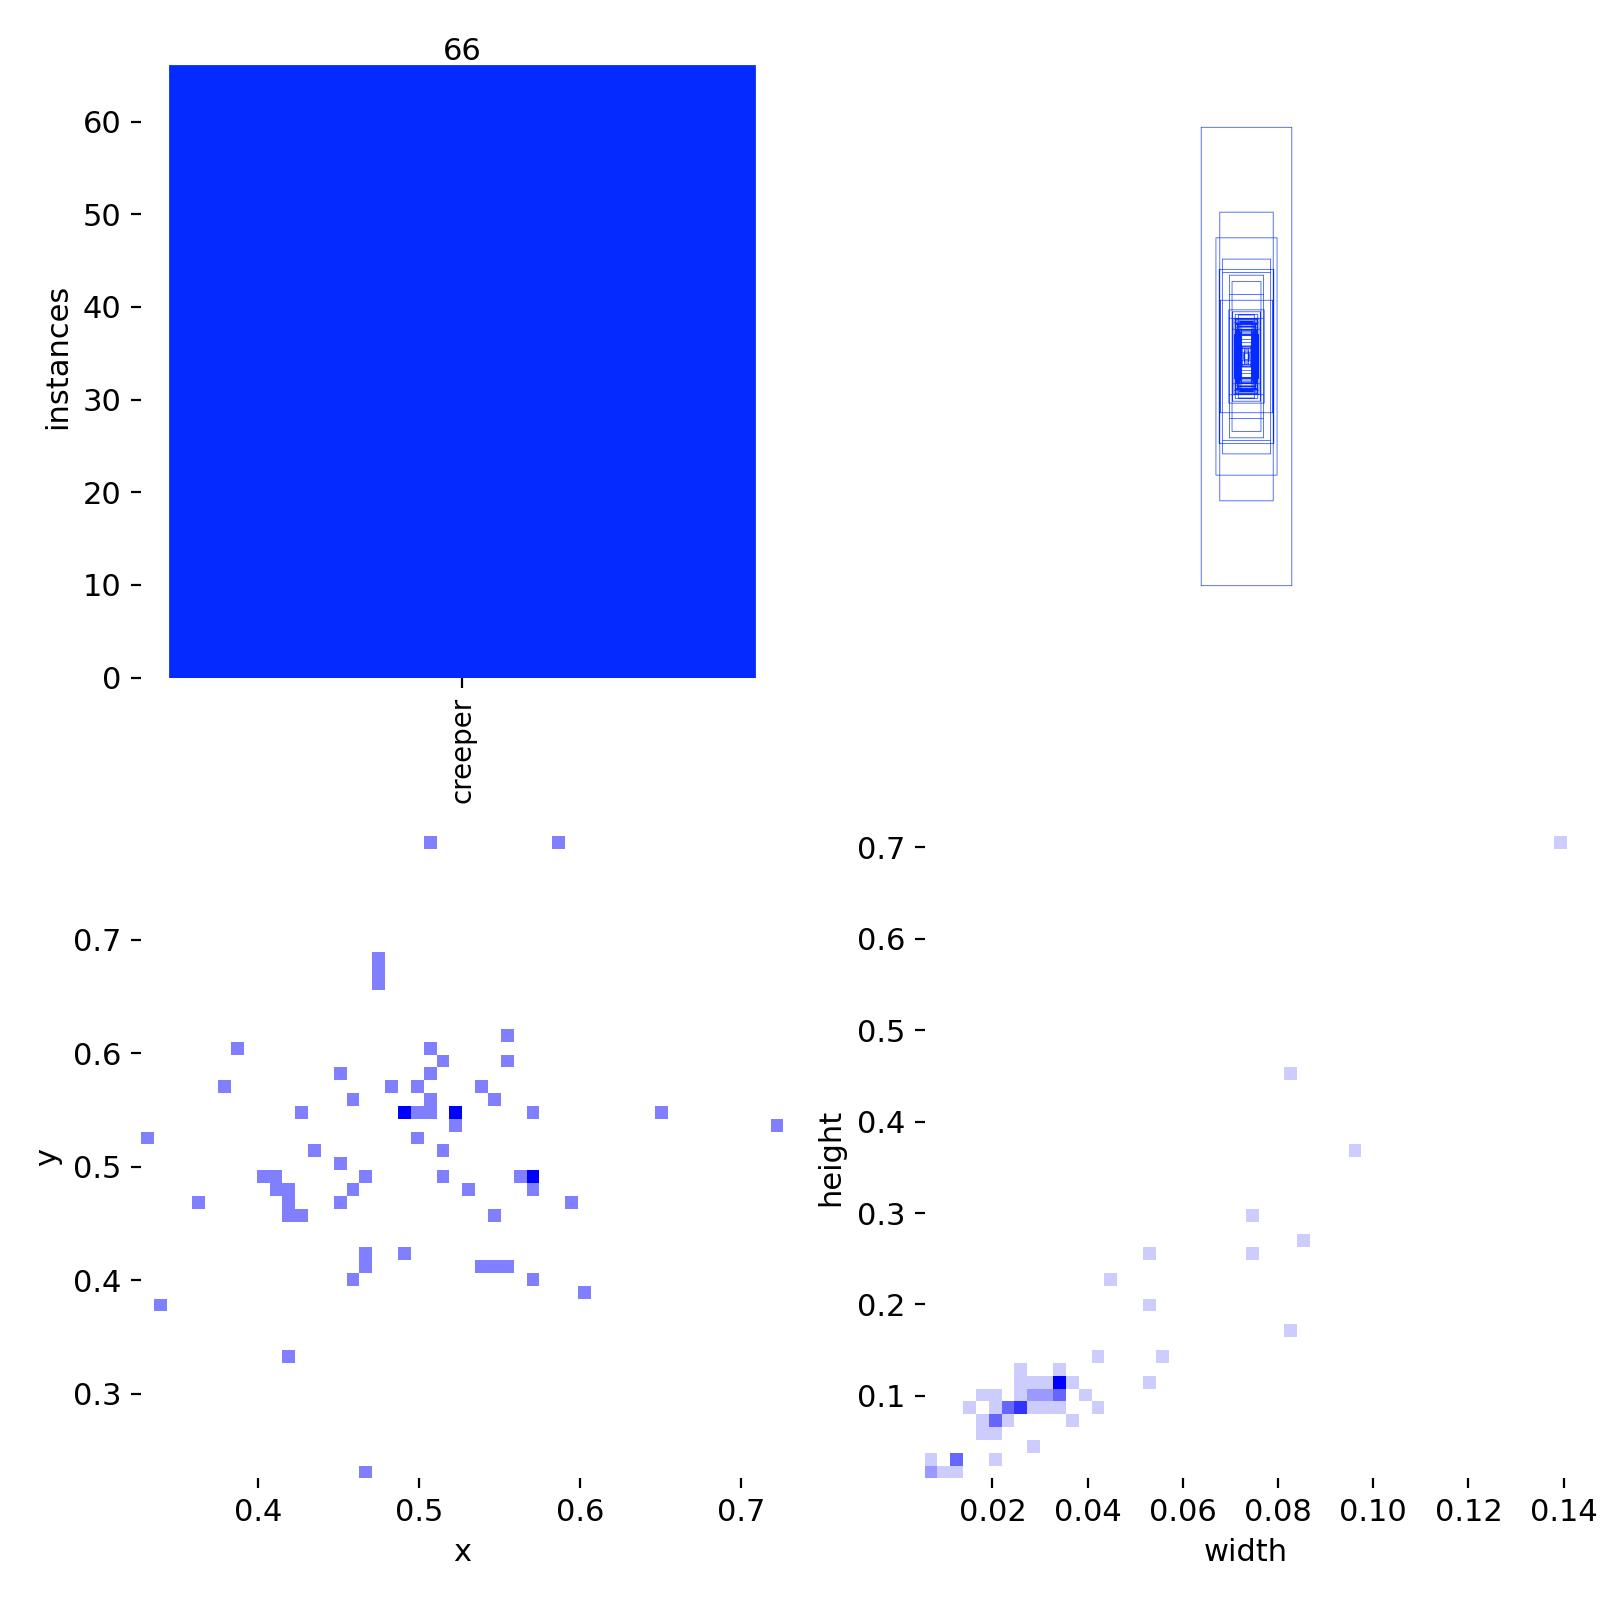

results.png


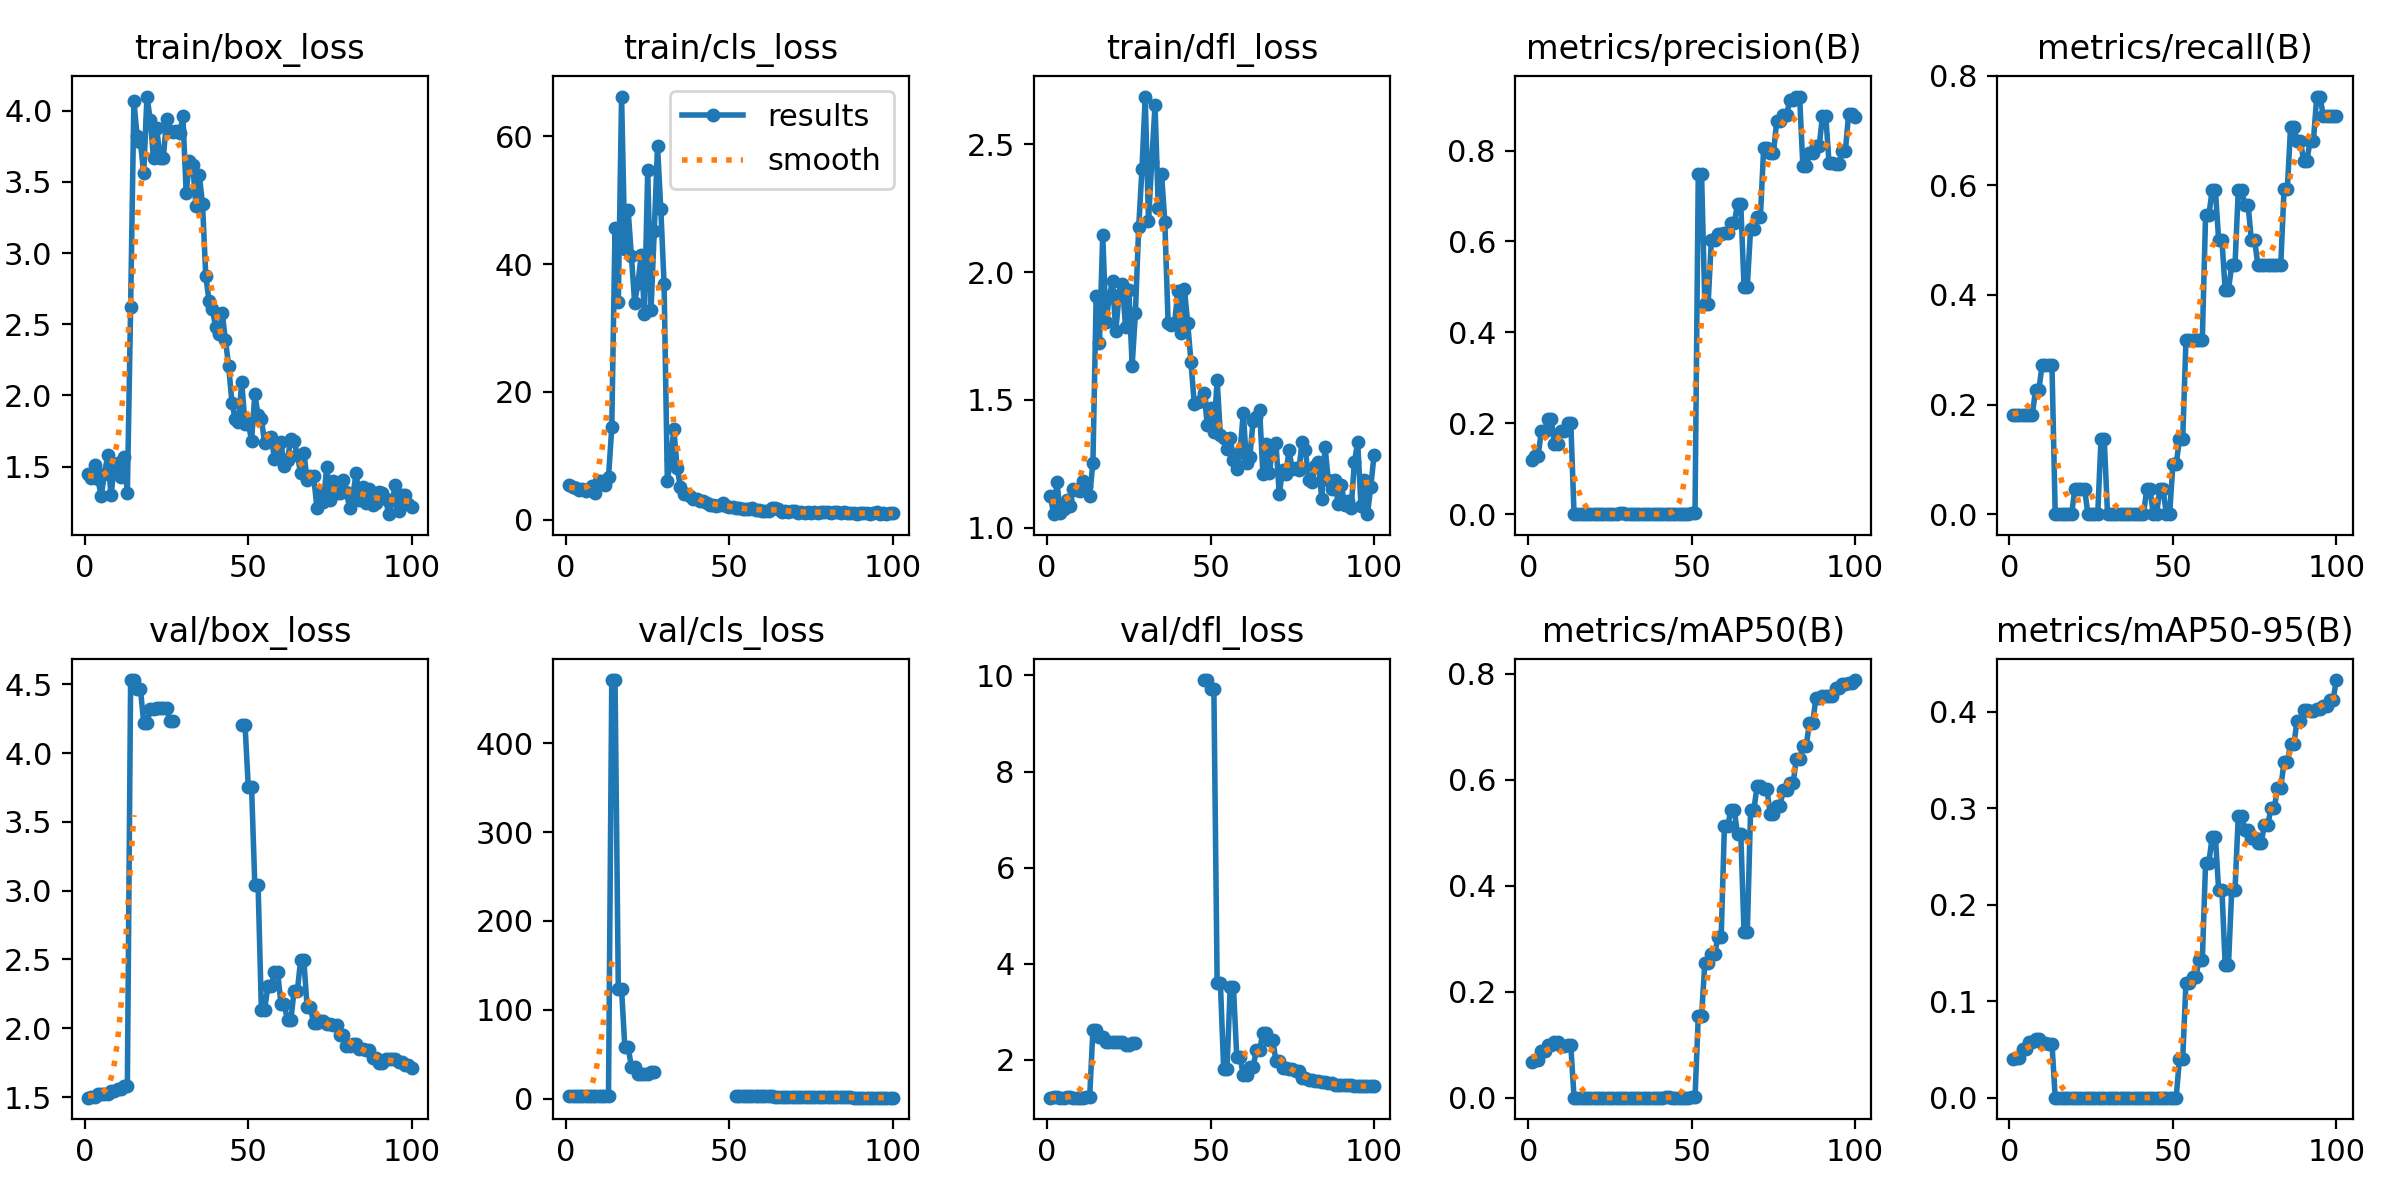

train_batch0.jpg


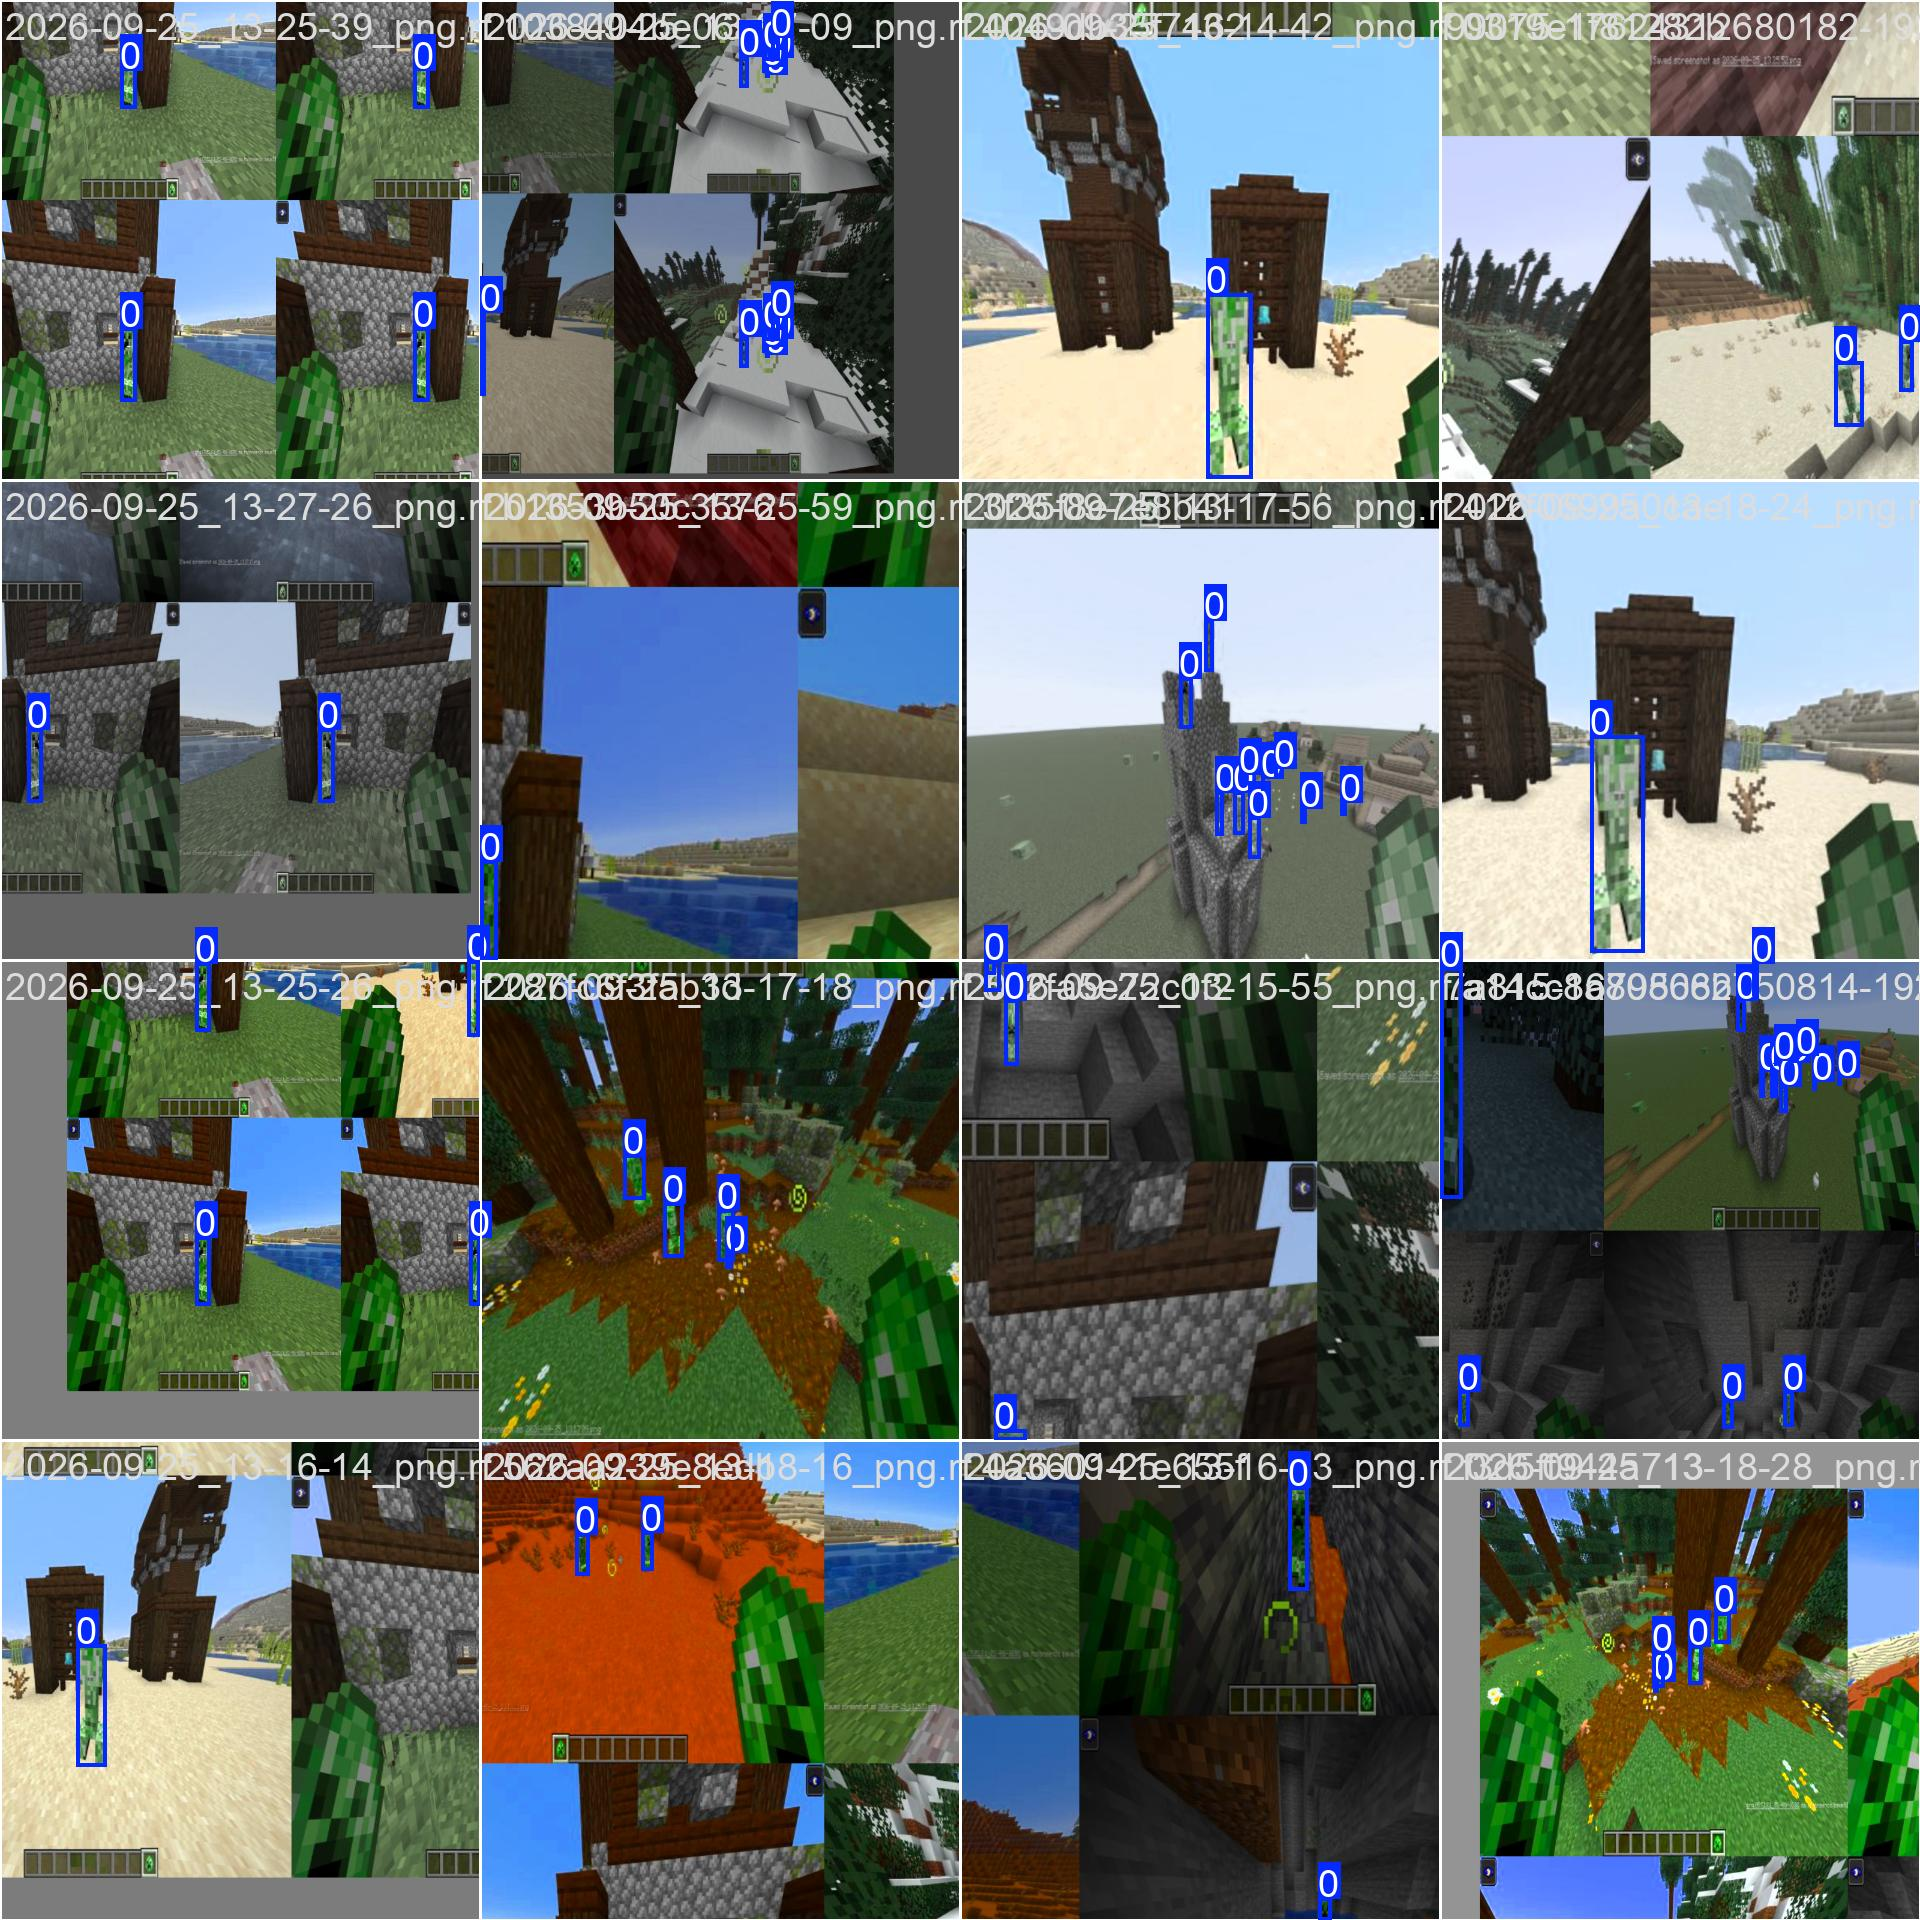

train_batch1.jpg


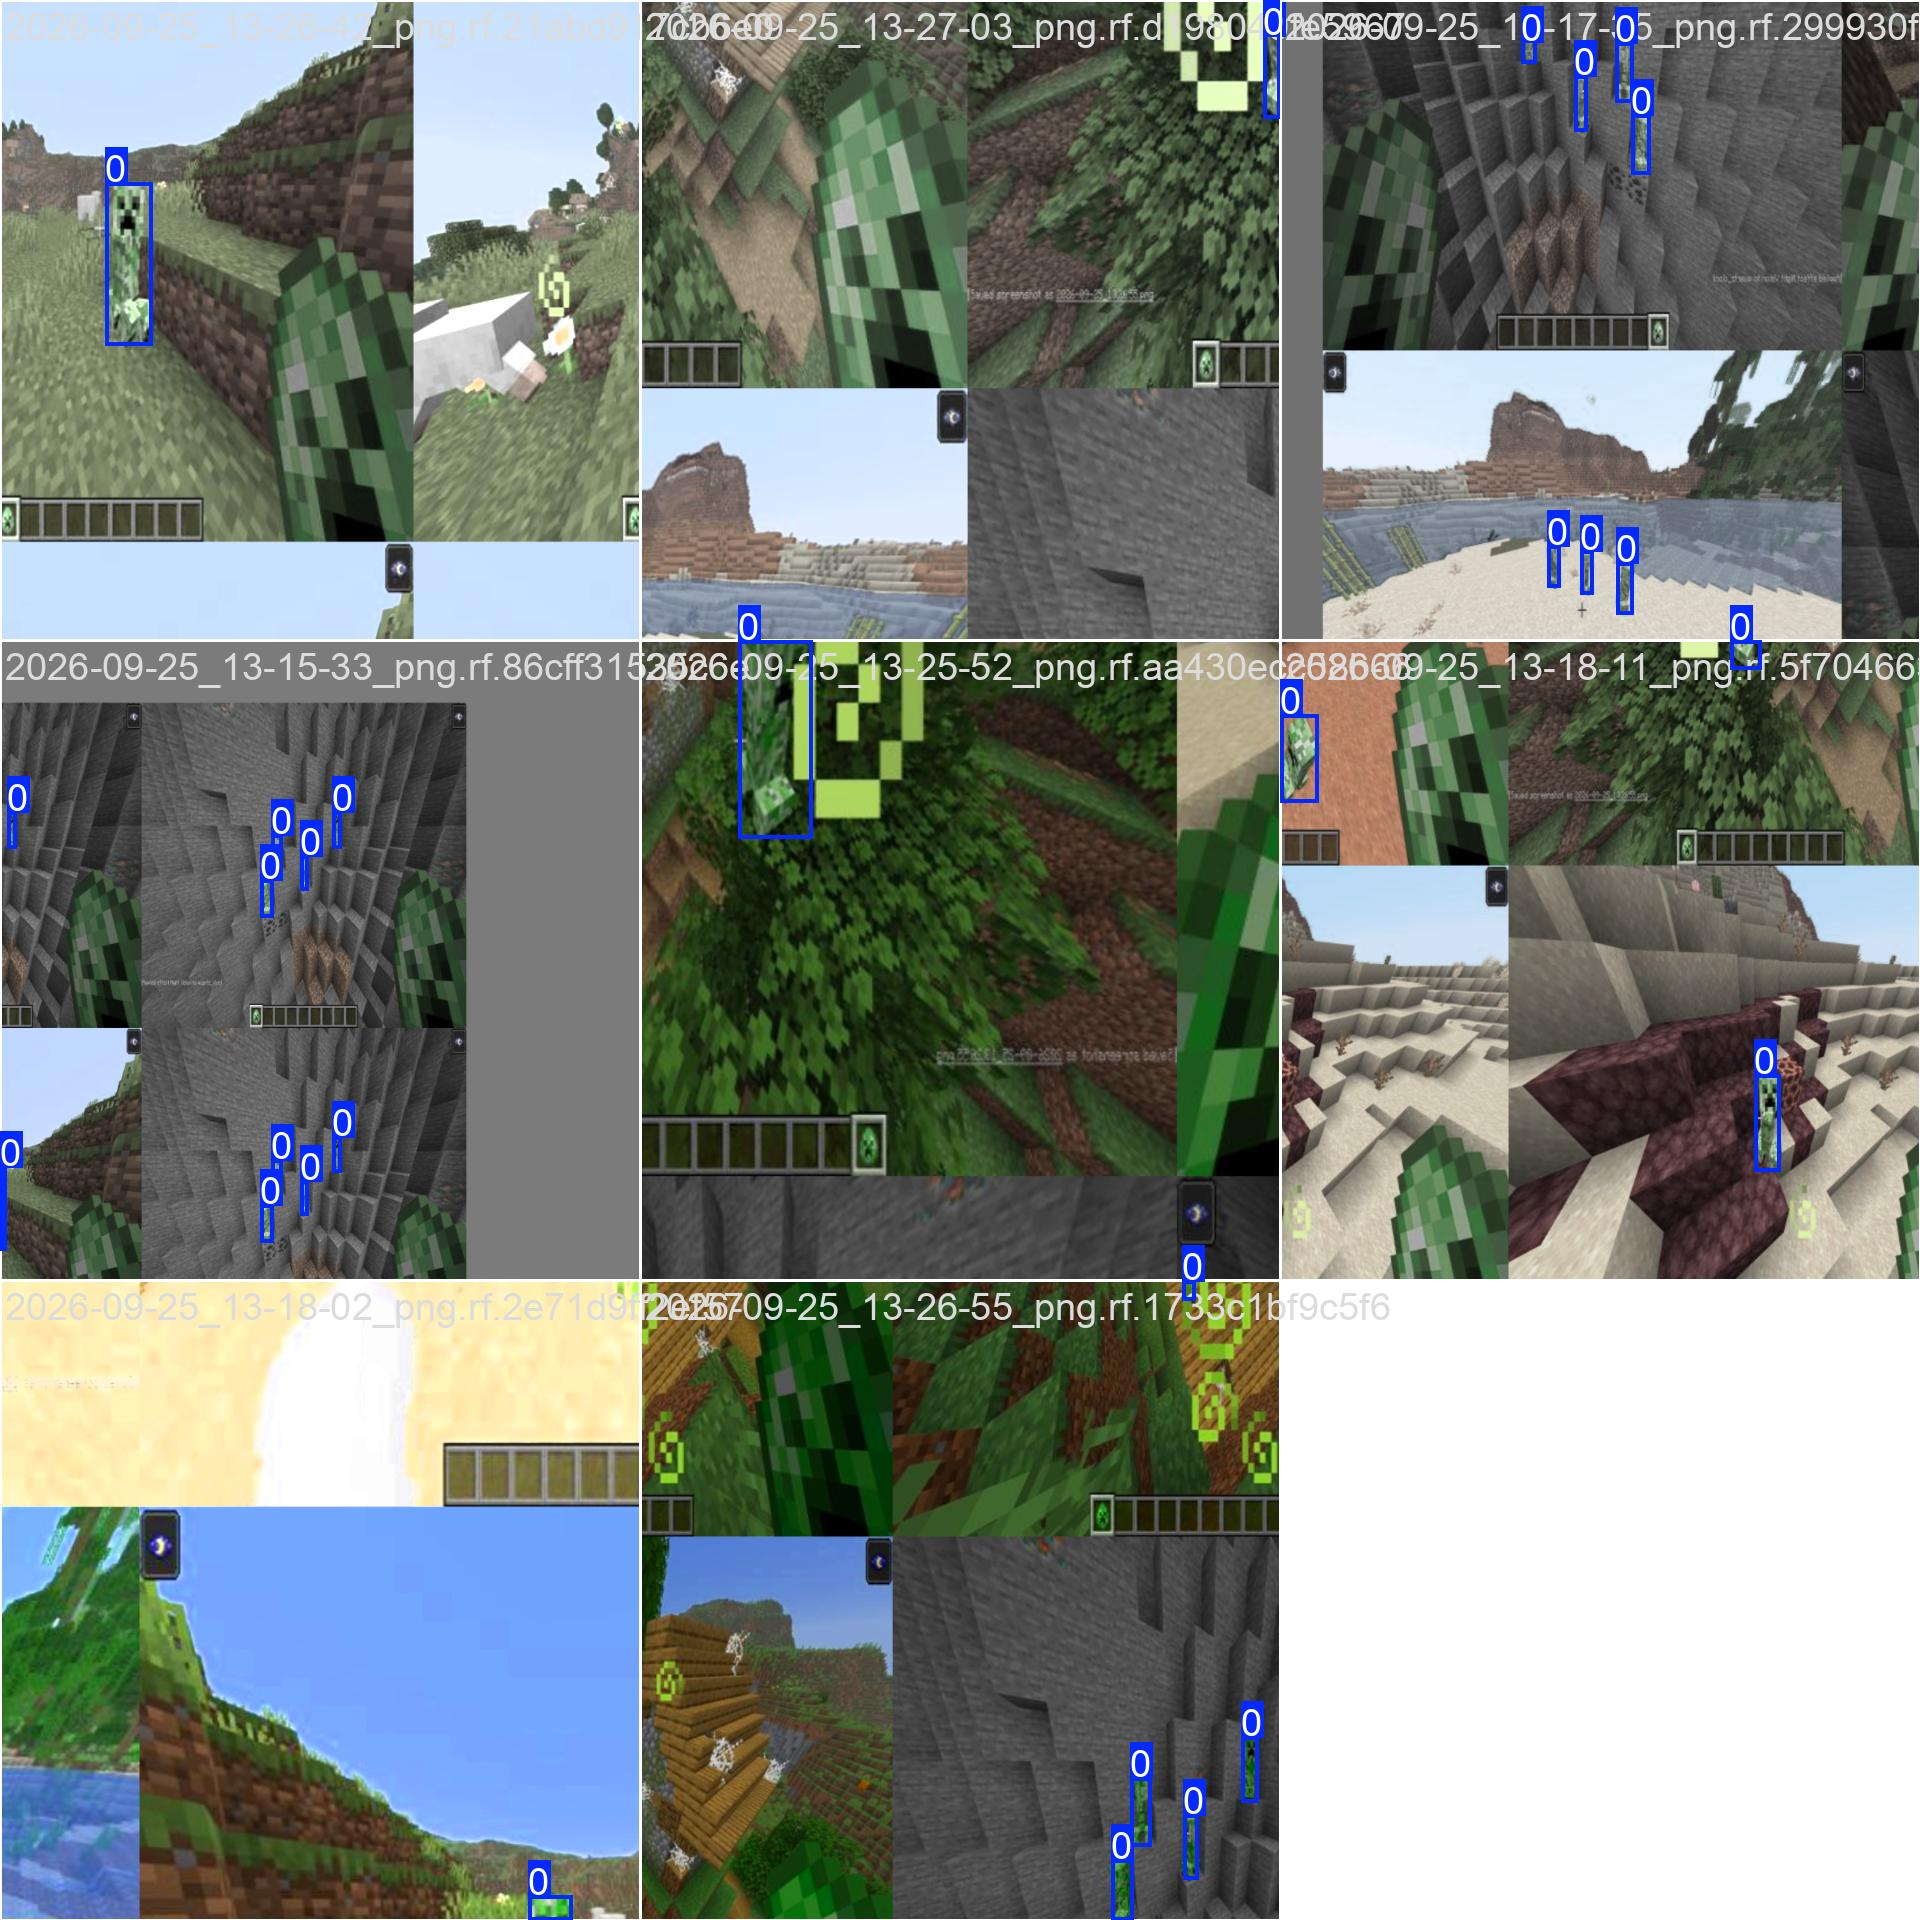

train_batch2.jpg


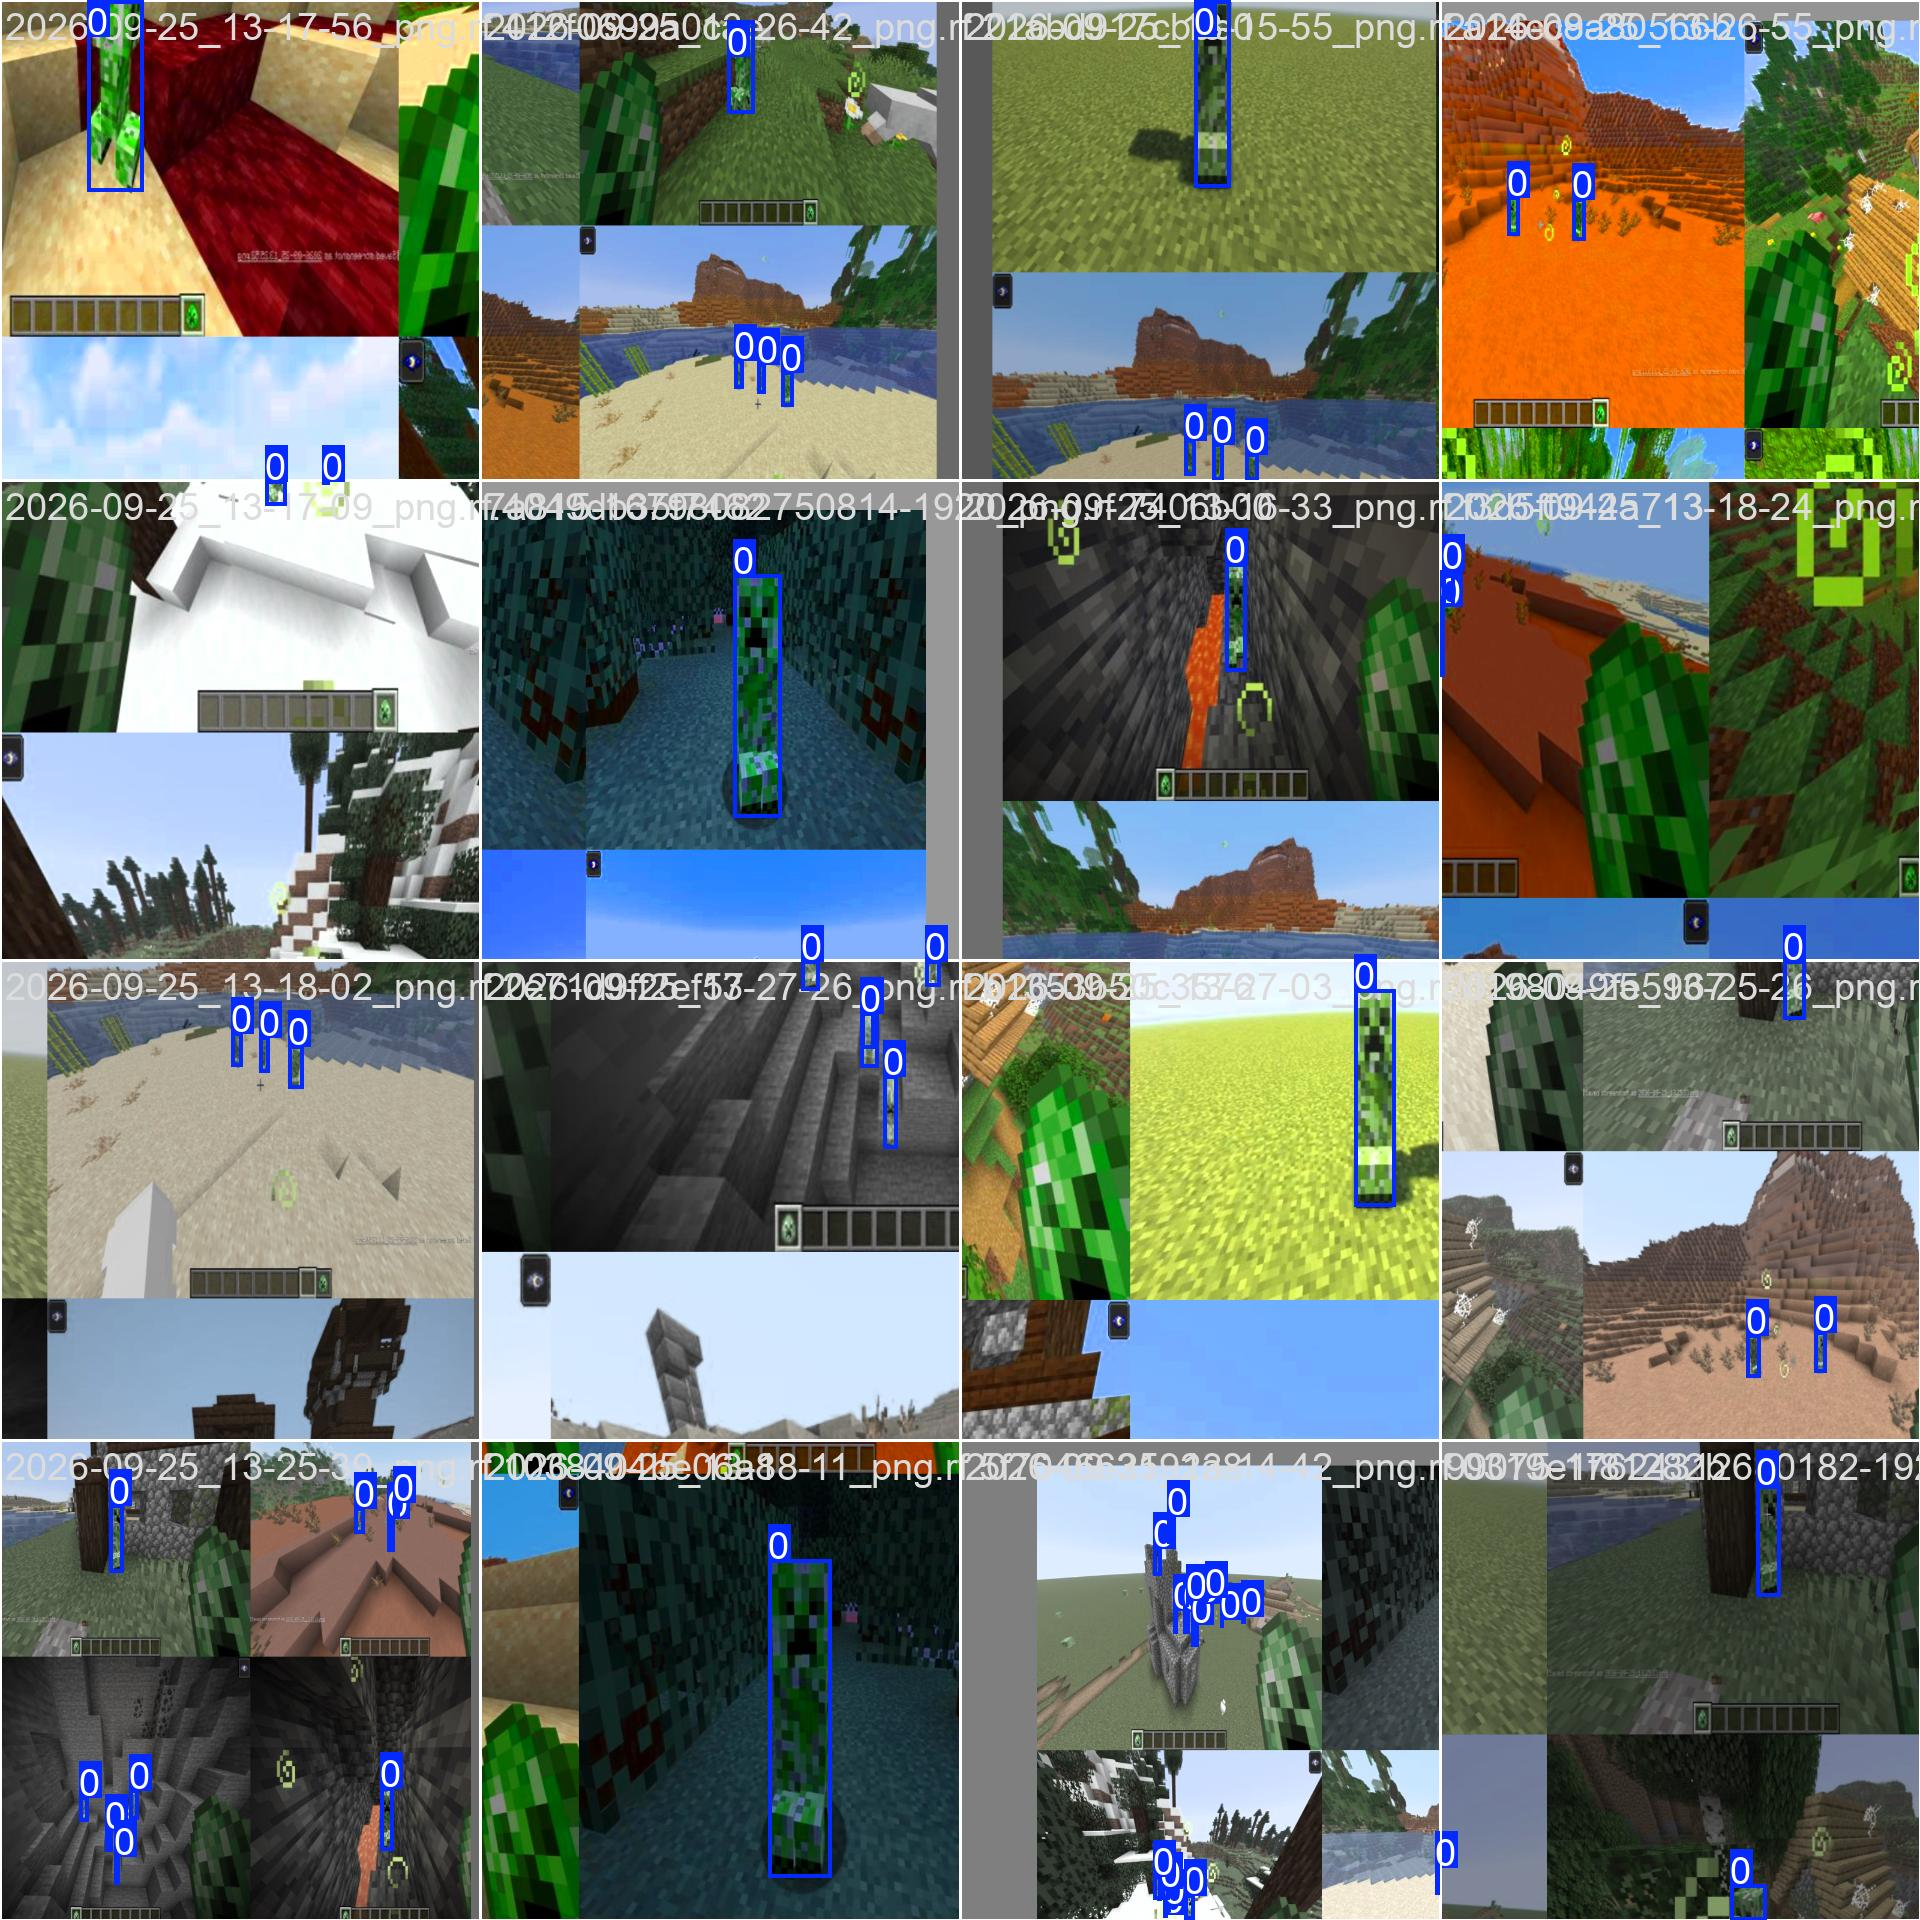

val_batch0_labels.jpg


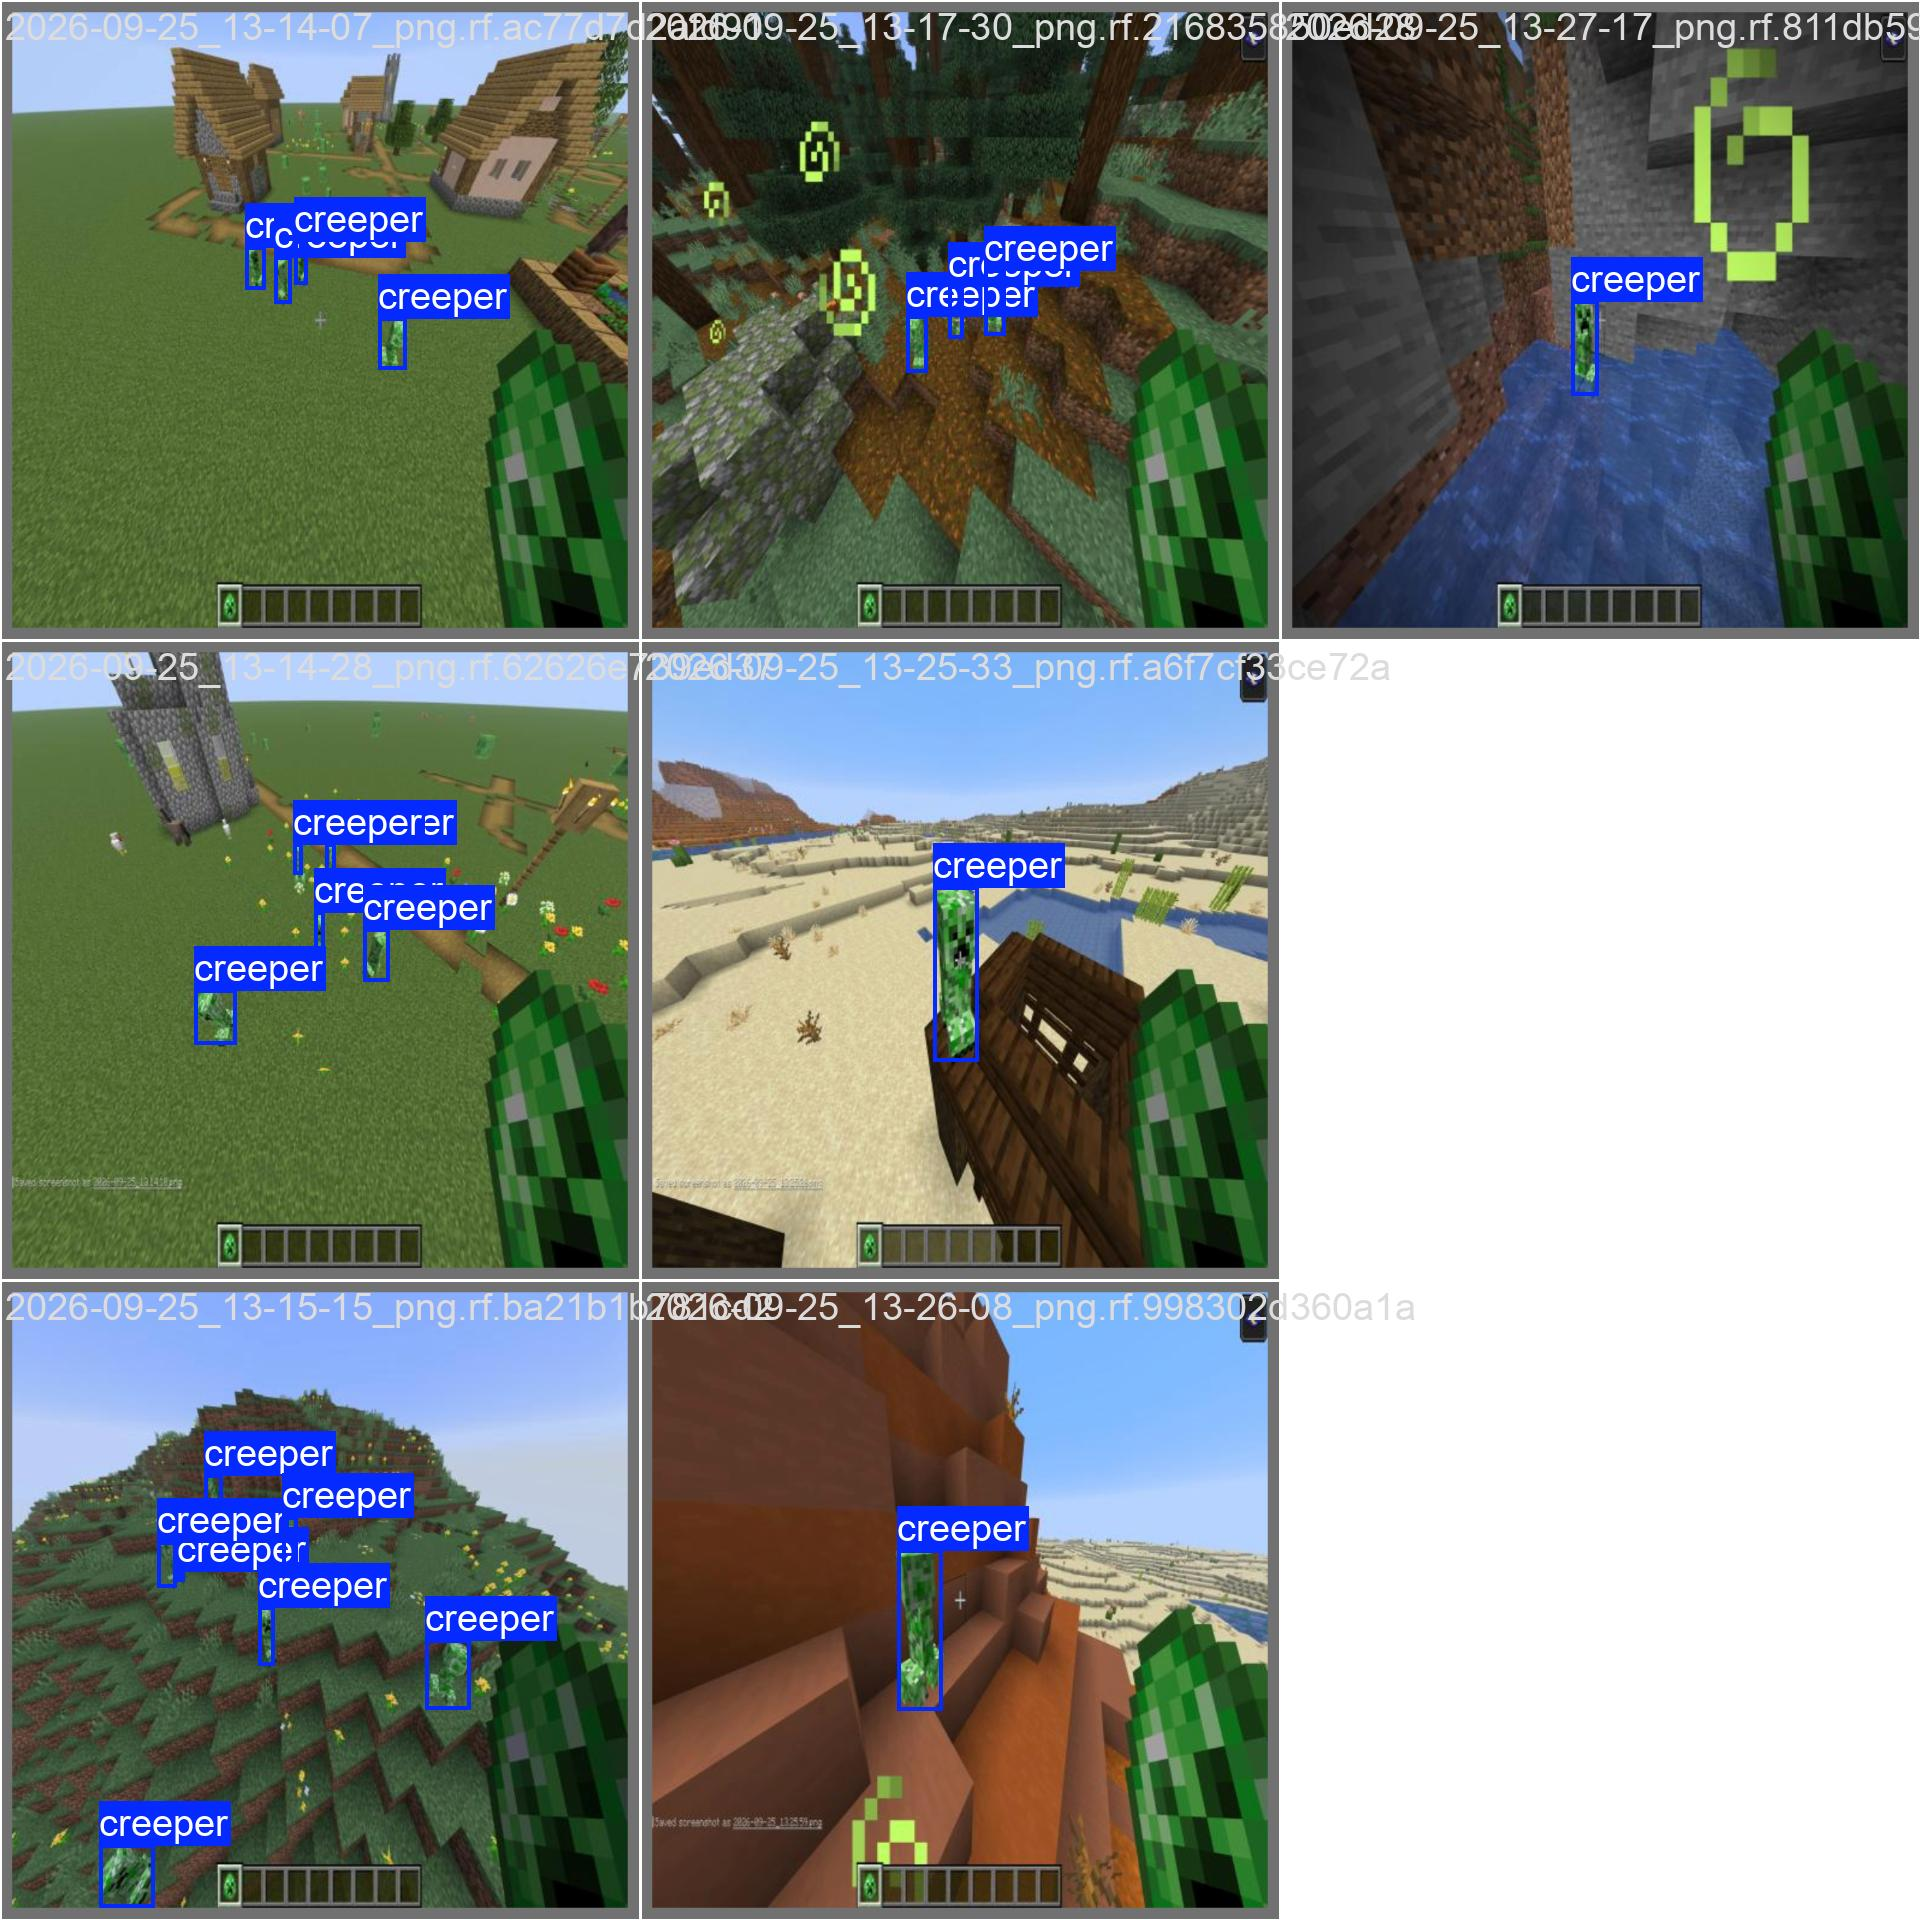

val_batch0_pred.jpg


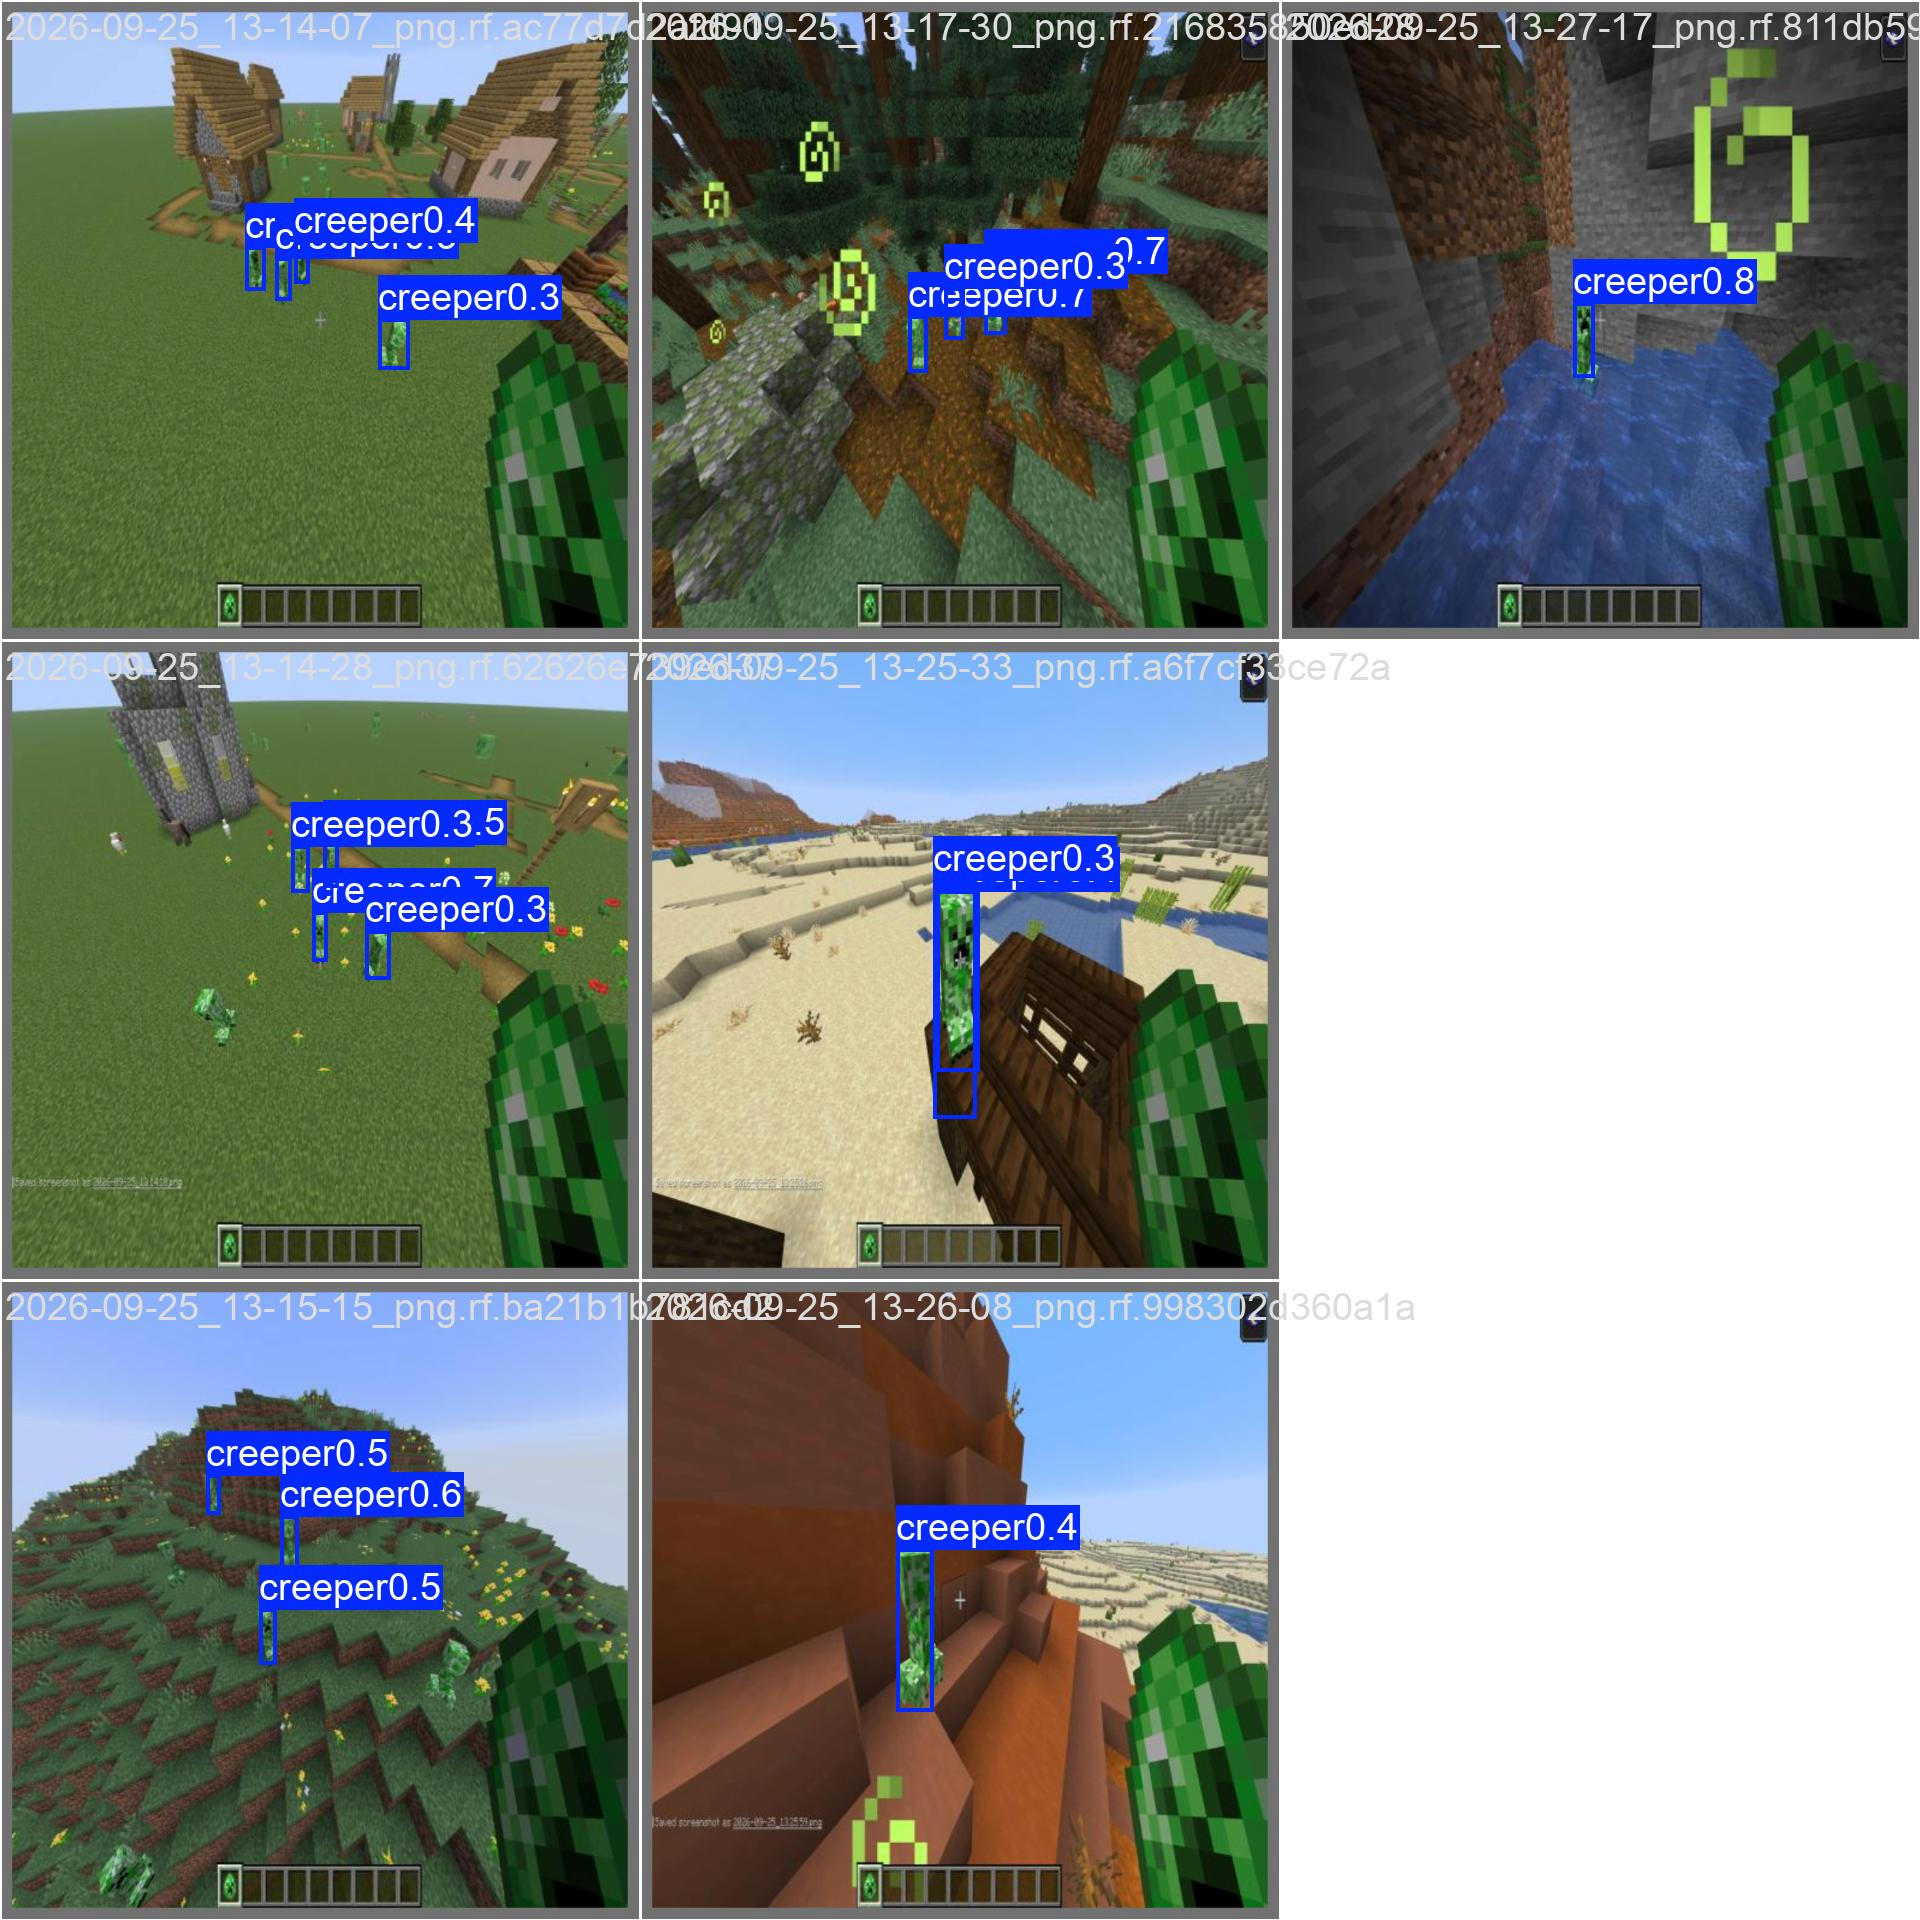

In [27]:
from pathlib import Path
from IPython.display import Image, display

pred_dir = Path("/content/runs/detect/creeper_no_mosaic_close-2")

for img_path in sorted(list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))):
    print(img_path.name)
    display(Image(filename=str(img_path), width=800))

In [ ]:
#WHAT THE ACTUAL FUCK???????? ARE WE BEING SERIOUS 100 EPOCH DOES IT???????

In [28]:
!du -sh /content

225M	/content


In [29]:
import shutil
from google.colab import files

shutil.make_archive(
    "/tmp/creeper_yolo_full_archive",
    "zip",
    "/content"
)

files.download("/tmp/creeper_yolo_full_archive.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>